### Aplicação operacional em 2025

Os dados disponíveis permitem avaliar o modelo utilizando desfechos observados até
2024.

Após a escolha e validação da solução preditiva, o modelo final será treinado com
todo o histórico rotulado disponível e aplicado aos indicadores de **2024** para
estimar:

`P(RISCO_DE_DEFASAGEM_EM_2025)`

Assim, 2025 representa o período de **inferência operacional** do projeto.

Como a base fornecida pelo Datathon não contém o desfecho real de 2025, essas
previsões não poderão ser utilizadas para calcular métricas de desempenho neste
momento.

As métricas de validação serão obtidas exclusivamente em períodos com resultado
futuro conhecido, principalmente na transição **2023 → 2024**.

A saída de 2025 será interpretada como uma lista prospectiva de estudantes que
merecem acompanhamento prioritário, e não como um resultado já confirmado.

# Modelo preditivo de risco futuro de defasagem

## Datathon — Associação Passos Mágicos

Este notebook corresponde à etapa preditiva do Datathon e utiliza os dados
tratados e auditados anteriormente no notebook de EDA.

O objetivo é construir um modelo capaz de estimar a **probabilidade de um estudante
estar em situação de defasagem no ano seguinte**, utilizando somente informações
que estariam disponíveis no momento da previsão.

A modelagem será estruturada de forma temporal:

- indicadores de **2022 → risco observado em 2023**;
- indicadores de **2023 → risco observado em 2024**.

Essa abordagem evita construir apenas um classificador do estado atual do aluno e
aproxima o modelo de um sistema real de alerta antecipado.

## Definição inicial do alvo

O alvo principal será:

`RISCO_FUTURO = 1` quando `DEFASAGEM_ANALISE` do ano seguinte for menor que zero.

Ou seja:

- `1` → aluno estará defasado no período seguinte;
- `0` → aluno estará sem defasagem no período seguinte.

O alvo será construído exclusivamente com informações do ano futuro.

Nenhuma variável pertencente ao ano do desfecho poderá ser utilizada como feature.

Também serão excluídos indicadores que possam produzir vazamento direto de
informação, como IAN e INDE do período utilizado como previsão.

O desempenho do modelo será avaliado principalmente por:

- recall da classe de risco;
- precision;
- ROC-AUC;
- PR-AUC;
- matriz de confusão;
- calibração das probabilidades.

Como o objetivo operacional é identificar estudantes que precisam de atenção antes
da deterioração de sua trajetória, o recall da classe de risco terá papel
especialmente importante na escolha do threshold final.

In [1]:
# ============================================================
# 2. CARGA E AUDITORIA DOS DADOS PROCESSADOS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount("/content/drive")


# ------------------------------------------------------------
# Caminhos do projeto
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos"
)

DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"


# ------------------------------------------------------------
# Arquivos tratados no Notebook 01
# ------------------------------------------------------------

arquivo_2022 = DATA_PROCESSED / "pede_2022_clean.csv"
arquivo_2023 = DATA_PROCESSED / "pede_2023_clean.csv"
arquivo_2024 = DATA_PROCESSED / "pede_2024_clean.csv"


df_2022 = pd.read_csv(
    arquivo_2022
)

df_2023 = pd.read_csv(
    arquivo_2023
)

df_2024 = pd.read_csv(
    arquivo_2024
)


print("✅ Bases carregadas.")

print(
    "2022:",
    df_2022.shape
)

print(
    "2023:",
    df_2023.shape
)

print(
    "2024:",
    df_2024.shape
)

Mounted at /content/drive
✅ Bases carregadas.
2022: (860, 49)
2023: (1014, 55)
2024: (1156, 62)


In [2]:
# ============================================================
# VARIÁVEIS NECESSÁRIAS PARA A MODELAGEM
# ============================================================

variaveis_auditoria = [
    "RA",
    "FASE_NUM",
    "DEFASAGEM_ANALISE",
    "IAN_ANALISE",
    "IDA",
    "IEG",
    "IAA",
    "IAA_ANALISE",
    "IPS",
    "IPP",
    "IPV"
]


auditoria_colunas = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    for coluna in variaveis_auditoria:

        auditoria_colunas.append({
            "Ano": ano,
            "Variavel": coluna,
            "Existe": coluna in df.columns,
            "Preenchidos": (
                int(df[coluna].notna().sum())
                if coluna in df.columns
                else 0
            )
        })


auditoria_colunas = pd.DataFrame(
    auditoria_colunas
)

display(
    auditoria_colunas.pivot(
        index="Variavel",
        columns="Ano",
        values=["Existe", "Preenchidos"]
    )
)

Existe               Preenchidos            
Ano                 2022   2023   2024        2022  2023  2024
Variavel                                                      
DEFASAGEM_ANALISE   True   True   True         860  1014  1156
FASE_NUM            True   True   True         860  1014  1156
IAA                 True   True   True         860   951  1054
IAA_ANALISE        False  False  False           0     0     0
IAN_ANALISE         True   True   True         860  1014  1156
IDA                 True   True   True         860   937  1055
IEG                 True   True   True         860   938  1156
IPP                False   True   True           0   938  1054
IPS                 True   True   True         860   945  1054
IPV                 True   True   True         860   938  1054
RA                  True   True   True         860  1014  1156

In [3]:
# ============================================================
# SOBREPOSIÇÃO LONGITUDINAL DE ALUNOS
# ============================================================

ra_2022 = set(
    df_2022["RA"].dropna()
)

ra_2023 = set(
    df_2023["RA"].dropna()
)

ra_2024 = set(
    df_2024["RA"].dropna()
)


print(
    "2022 ∩ 2023:",
    len(ra_2022 & ra_2023)
)

print(
    "2023 ∩ 2024:",
    len(ra_2023 & ra_2024)
)

print(
    "2022 ∩ 2023 ∩ 2024:",
    len(
        ra_2022
        & ra_2023
        & ra_2024
    )
)


# Teste temporal realmente independente por aluno
ras_treino_candidatos = (
    ra_2022
    & ra_2023
)

ras_teste_candidatos = (
    ra_2023
    & ra_2024
)

ras_teste_novos = (
    ras_teste_candidatos
    - ras_treino_candidatos
)


print(
    "\nTreino candidato 2022→2023:",
    len(ras_treino_candidatos)
)

print(
    "Teste candidato 2023→2024:",
    len(ras_teste_candidatos)
)

print(
    "Teste 2023→2024 sem alunos presentes no treino:",
    len(ras_teste_novos)
)

2022 ∩ 2023: 600
2023 ∩ 2024: 765
2022 ∩ 2023 ∩ 2024: 468

Treino candidato 2022→2023: 600
Teste candidato 2023→2024: 765
Teste 2023→2024 sem alunos presentes no treino: 297


## 2.1 Resultado da auditoria e estratégia temporal

As bases tratadas no Notebook 01 foram carregadas com sucesso:

- **2022:** 860 alunos;
- **2023:** 1.014 alunos;
- **2024:** 1.156 alunos.

As variáveis necessárias para construir o alvo futuro, incluindo `RA`,
`FASE_NUM` e `DEFASAGEM_ANALISE`, estão disponíveis integralmente nos três anos.

### Diferenças estruturais relevantes

Duas diferenças entre os arquivos processados precisam ser consideradas na
modelagem.

A variável `IAA_ANALISE`, criada durante a EDA para tratar a anomalia dos valores
iguais a zero no IAA de 2023, não foi persistida nos arquivos processados.

Por isso, ela será reconstruída neste notebook utilizando exatamente a mesma regra
metodológica definida anteriormente.

O IPP, por sua vez, não está disponível em 2022.

Como o modelo principal será treinado com dados de 2022 e avaliado com dados de
2023, o IPP não será utilizado entre as features principais. Isso garante que
treino e teste possuam o mesmo conjunto de informações disponíveis.

### Estrutura longitudinal

Foram encontrados:

- **600 alunos** presentes em 2022 e 2023;
- **765 alunos** presentes em 2023 e 2024;
- **468 alunos** presentes nos três anos.

Isso permite construir duas transições temporais:

- **2022 → 2023:** conjunto de desenvolvimento;
- **2023 → 2024:** conjunto de teste temporal.

### Estratégia de avaliação

O teste principal utilizará os alunos da transição 2023 → 2024.

Essa escolha representa o cenário operacional em que o modelo poderá ser aplicado
tanto a estudantes já acompanhados anteriormente quanto a estudantes mais recentes.

Como parte dos alunos aparece também na transição utilizada para treinamento, será
realizada adicionalmente uma análise de robustez utilizando apenas estudantes do
teste que nunca apareceram no conjunto de treinamento.

Assim, serão consideradas duas avaliações:

1. **teste temporal completo:** transição 2023 → 2024;
2. **teste temporal com alunos inéditos:** subconjunto do teste contendo apenas
   estudantes não observados na transição 2022 → 2023.

O identificador `RA` será utilizado exclusivamente para construção dos painéis
longitudinais e nunca será fornecido ao modelo como variável preditora.

# 3. Definição e construção do alvo futuro

O objetivo do modelo é identificar antecipadamente estudantes que estarão em
situação de defasagem no período seguinte.

O alvo foi definido como:

`RISCO_FUTURO = 1` quando `DEFASAGEM_ANALISE` do ano seguinte for menor que zero.

Caso contrário:

`RISCO_FUTURO = 0`.

Essa definição corresponde à mesma lógica utilizada anteriormente para
classificação de alunos em situação de risco de defasagem.

A construção será estritamente temporal:

- informações de 2022 serão associadas ao desfecho observado em 2023;
- informações de 2023 serão associadas ao desfecho observado em 2024.

Assim, o modelo nunca utiliza informações do futuro para explicar o próprio alvo.

In [4]:
# ============================================================
# 3. CONSTRUÇÃO DO ALVO FUTURO
# ============================================================

def construir_transicao_risco(
    df_origem,
    df_futuro,
    ano_origem,
    ano_futuro
):

    origem = df_origem.copy()

    futuro = df_futuro[
        [
            "RA",
            "DEFASAGEM_ANALISE"
        ]
    ].copy()

    futuro["DEFASAGEM_FUTURA"] = pd.to_numeric(
        futuro["DEFASAGEM_ANALISE"],
        errors="coerce"
    )

    futuro = futuro[
        [
            "RA",
            "DEFASAGEM_FUTURA"
        ]
    ]

    painel = origem.merge(
        futuro,
        on="RA",
        how="inner"
    )

    painel["RISCO_FUTURO"] = np.where(
        painel["DEFASAGEM_FUTURA"] < 0,
        1,
        0
    )

    painel["ANO_FEATURES"] = ano_origem
    painel["ANO_ALVO"] = ano_futuro

    return painel


painel_22_23 = construir_transicao_risco(
    df_2022,
    df_2023,
    2022,
    2023
)

painel_23_24 = construir_transicao_risco(
    df_2023,
    df_2024,
    2023,
    2024
)


print("=" * 70)
print("TRANSIÇÃO 2022 → 2023")
print("=" * 70)

print(
    "Alunos:",
    len(painel_22_23)
)

display(
    painel_22_23[
        "RISCO_FUTURO"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("RISCO_FUTURO")
    .reset_index(name="Quantidade")
)

print(
    "Taxa de risco futuro:",
    f"{painel_22_23['RISCO_FUTURO'].mean() * 100:.2f}%"
)


print("\n" + "=" * 70)
print("TRANSIÇÃO 2023 → 2024")
print("=" * 70)

print(
    "Alunos:",
    len(painel_23_24)
)

display(
    painel_23_24[
        "RISCO_FUTURO"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("RISCO_FUTURO")
    .reset_index(name="Quantidade")
)

print(
    "Taxa de risco futuro:",
    f"{painel_23_24['RISCO_FUTURO'].mean() * 100:.2f}%"
)

TRANSIÇÃO 2022 → 2023
Alunos: 600


,RISCO_FUTURO,Quantidade
0,0,234
1,1,366


Taxa de risco futuro: 61.00%

TRANSIÇÃO 2023 → 2024
Alunos: 765


,RISCO_FUTURO,Quantidade
0,0,455
1,1,310


Taxa de risco futuro: 40.52%


In [5]:
# ============================================================
# TESTE TEMPORAL COM ALUNOS INÉDITOS
# ============================================================

ras_treino = set(
    painel_22_23["RA"]
)

painel_23_24_novos = painel_23_24.loc[
    ~painel_23_24["RA"].isin(
        ras_treino
    )
].copy()


print(
    "Teste temporal completo:",
    len(painel_23_24)
)

print(
    "Teste com alunos inéditos:",
    len(painel_23_24_novos)
)

print(
    "Taxa de risco — teste completo:",
    f"{painel_23_24['RISCO_FUTURO'].mean() * 100:.2f}%"
)

print(
    "Taxa de risco — alunos inéditos:",
    f"{painel_23_24_novos['RISCO_FUTURO'].mean() * 100:.2f}%"
)

Teste temporal completo: 765
Teste com alunos inéditos: 297
Taxa de risco — teste completo: 40.52%
Taxa de risco — alunos inéditos: 48.82%


## 3.1 Distribuição do alvo e definição do teste

A construção longitudinal produziu 600 observações na transição 2022 → 2023 e
765 observações na transição 2023 → 2024.

### Transição 2022 → 2023

Entre os 600 estudantes:

- 234 não estavam em situação de defasagem no ano seguinte;
- 366 estavam em situação de defasagem.

A prevalência do alvo positivo foi de **61,00%**.

### Transição 2023 → 2024

Entre os 765 estudantes:

- 455 não estavam em situação de defasagem no ano seguinte;
- 310 estavam em situação de defasagem.

A prevalência foi de **40,52%**.

Existe, portanto, uma mudança relevante na distribuição do desfecho entre os
períodos.

### Separação por estudante

Como 468 alunos aparecem nas duas transições, utilizá-los simultaneamente no
treinamento e no teste poderia introduzir dependência entre os conjuntos.

Por esse motivo, a avaliação principal utilizará somente os estudantes da
transição 2023 → 2024 que nunca apareceram no conjunto 2022 → 2023.

Esse subconjunto contém **297 estudantes** e apresenta prevalência de risco de
**48,82%**.

A estratégia final será:

- **desenvolvimento:** 2022 → 2023, com 600 estudantes;
- **teste temporal independente:** 2023 → 2024, com 297 estudantes inéditos;
- **avaliação complementar:** conjunto completo 2023 → 2024, com 765 estudantes.

Essa separação permite avaliar se o modelo generaliza simultaneamente para um
período posterior e para estudantes não observados durante seu desenvolvimento.

### Implicação para as métricas

A prevalência do risco muda entre desenvolvimento e teste.

Por isso:

- acurácia isolada não será considerada suficiente;
- ROC-AUC e PR-AUC serão reportadas;
- recall e precision da classe de risco terão destaque;
- a calibração das probabilidades será verificada;
- qualquer ajuste de threshold será realizado sem utilizar o conjunto de teste.

O teste temporal independente permanecerá intocado até a avaliação final dos
modelos.

In [6]:
# ============================================================
# 4.1 RECONSTRUÇÃO DO IAA ANALÍTICO
# Mesma decisão metodológica do Notebook 01
# ============================================================

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    df["IAA_MODELO"] = pd.to_numeric(
        df["IAA"],
        errors="coerce"
    )

    # Anomalia específica identificada na auditoria de 2023:
    # zeros são mantidos na base original, mas tratados como
    # ausentes na variável analítica utilizada pelo modelo.
    if ano == 2023:

        df.loc[
            df["IAA_MODELO"] == 0,
            "IAA_MODELO"
        ] = np.nan


print("IAA_MODELO reconstruído.\n")

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    print(
        ano,
        "| válidos:",
        df["IAA_MODELO"].notna().sum(),
        "| ausentes:",
        df["IAA_MODELO"].isna().sum()
    )

IAA_MODELO reconstruído.

2022 | válidos: 860 | ausentes: 0
2023 | válidos: 761 | ausentes: 253
2024 | válidos: 1054 | ausentes: 102


## 4.2 Inventário de variáveis candidatas

Antes da seleção definitiva das features, será auditada a disponibilidade das
variáveis potencialmente preditivas nos três períodos.

A seleção seguirá três critérios principais:

1. a informação deve estar disponível no momento da previsão;
2. a variável precisa possuir correspondência entre treino, teste e aplicação em
   2024;
3. variáveis que reproduzem diretamente a situação de defasagem serão mantidas
   fora do modelo principal para evitar um modelo que apenas replique o indicador
   de risco já conhecido.

Por esse motivo, `IAN`, `IAN_ANALISE`, `INDE` e `DEFASAGEM_ANALISE` não serão
utilizados como features do modelo principal.

O identificador `RA` também não será utilizado como variável preditora.

O IPP será avaliado separadamente, pois não está disponível em 2022 e, portanto,
não pode integrar diretamente o modelo temporal principal.

In [7]:
# ============================================================
# 4.2 INVENTÁRIO DE FEATURES CANDIDATAS
# ============================================================

# Colunas existentes simultaneamente nos três anos
colunas_comuns = sorted(
    set(df_2022.columns)
    & set(df_2023.columns)
    & set(df_2024.columns)
)

print(
    "Número de colunas comuns aos três anos:",
    len(colunas_comuns)
)

print("\nColunas comuns:")
print(colunas_comuns)


# ------------------------------------------------------------
# Variáveis de interesse inicial
# ------------------------------------------------------------

candidatas_iniciais = [
    "FASE_NUM",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV"
]


auditoria_features = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    for coluna in candidatas_iniciais:

        existe = coluna in df.columns

        auditoria_features.append({
            "Ano": ano,
            "Feature": coluna,
            "Existe": existe,
            "Preenchidos": (
                int(df[coluna].notna().sum())
                if existe
                else 0
            ),
            "Ausentes": (
                int(df[coluna].isna().sum())
                if existe
                else len(df)
            ),
            "Pct_Ausentes": (
                df[coluna].isna().mean() * 100
                if existe
                else 100
            )
        })


auditoria_features = pd.DataFrame(
    auditoria_features
)

auditoria_features[
    "Pct_Ausentes"
] = auditoria_features[
    "Pct_Ausentes"
].round(2)


display(
    auditoria_features
)

Número de colunas comuns aos três anos: 40

Colunas comuns:
['Ano ingresso', 'Atingiu PV', 'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Cf', 'Cg', 'Ct', 'DEFASAGEM_ANALISE', 'DEFASAGEM_ORIGINAL', 'Destaque IDA', 'Destaque IEG', 'Destaque IPV', 'FASE_IDEAL_ANALISE', 'FASE_IDEAL_ORIGINAL_NUM', 'FASE_NUM', 'Fase', 'Gênero', 'IAA', 'IAA_MODELO', 'IAN', 'IAN_ANALISE', 'IAN_ORIGINAL', 'IDA', 'IEG', 'INDE 22', 'IPS', 'IPV', 'Indicado', 'Instituição de ensino', 'Nº Av', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'RA', 'Rec Av1', 'Rec Av2', 'Rec Psicologia', 'Turma']


,Ano,Feature,Existe,Preenchidos,Ausentes,Pct_Ausentes
0,2022,FASE_NUM,True,860,0,0.00
1,2022,IDA,True,860,0,0.00
2,2022,IEG,True,860,0,0.00
3,2022,IAA_MODELO,True,860,0,0.00
4,2022,IPS,True,860,0,0.00
5,2022,IPV,True,860,0,0.00
6,2023,FASE_NUM,True,1014,0,0.00
7,2023,IDA,True,937,77,7.59
8,2023,IEG,True,938,76,7.50
9,2023,IAA_MODELO,True,761,253,24.95


## 4.3 Auditoria de características contextuais

Além dos indicadores do PEDE, a base possui algumas características contextuais
que podem ser conhecidas no momento da previsão.

Serão avaliadas:

- fase atual do estudante;
- tempo de participação no programa;
- gênero;
- tipo de instituição de ensino.

O tempo no programa será derivado de:

`TEMPO_PROGRAMA = ANO_DAS_FEATURES - Ano ingresso`

Essas variáveis somente serão mantidas caso apresentem consistência suficiente
entre os períodos de desenvolvimento, teste e aplicação futura.

Variáveis diretamente derivadas da defasagem ou de seus componentes de
classificação, como IAN, fase ideal e defasagem atual, permanecerão fora do modelo
principal para preservar o caráter de alerta antecipado.

In [8]:
# ============================================================
# 4.3 AUDITORIA DE VARIÁVEIS CONTEXTUAIS
# ============================================================

def preparar_contexto_modelo(
    painel,
    ano_features
):
    base = painel.copy()

    base["Ano ingresso"] = pd.to_numeric(
        base["Ano ingresso"],
        errors="coerce"
    )

    base["TEMPO_PROGRAMA"] = (
        ano_features
        - base["Ano ingresso"]
    )

    return base


painel_22_23 = preparar_contexto_modelo(
    painel_22_23,
    2022
)

painel_23_24 = preparar_contexto_modelo(
    painel_23_24,
    2023
)

painel_23_24_novos = painel_23_24.loc[
    ~painel_23_24["RA"].isin(
        set(painel_22_23["RA"])
    )
].copy()


# ------------------------------------------------------------
# Auditoria numérica
# ------------------------------------------------------------

auditoria_contexto_numerico = []

for conjunto, df in [
    ("Treino 2022→2023", painel_22_23),
    ("Teste completo 2023→2024", painel_23_24),
    ("Teste inédito 2023→2024", painel_23_24_novos)
]:

    for coluna in [
        "Ano ingresso",
        "TEMPO_PROGRAMA",
        "FASE_NUM"
    ]:

        serie = pd.to_numeric(
            df[coluna],
            errors="coerce"
        )

        auditoria_contexto_numerico.append({
            "Conjunto": conjunto,
            "Variavel": coluna,
            "N": len(df),
            "Preenchidos": serie.notna().sum(),
            "Ausentes_pct": serie.isna().mean() * 100,
            "Min": serie.min(),
            "Mediana": serie.median(),
            "Max": serie.max()
        })


auditoria_contexto_numerico = pd.DataFrame(
    auditoria_contexto_numerico
)

auditoria_contexto_numerico[
    "Ausentes_pct"
] = auditoria_contexto_numerico[
    "Ausentes_pct"
].round(2)

display(
    auditoria_contexto_numerico
)


# ------------------------------------------------------------
# Auditoria categórica
# ------------------------------------------------------------

auditoria_contexto_categorico = []

for conjunto, df in [
    ("Treino 2022→2023", painel_22_23),
    ("Teste completo 2023→2024", painel_23_24),
    ("Teste inédito 2023→2024", painel_23_24_novos)
]:

    for coluna in [
        "Gênero",
        "Instituição de ensino"
    ]:

        auditoria_contexto_categorico.append({
            "Conjunto": conjunto,
            "Variavel": coluna,
            "N": len(df),
            "Preenchidos": df[coluna].notna().sum(),
            "Ausentes_pct": df[coluna].isna().mean() * 100,
            "Categorias": df[coluna].nunique(dropna=True),
            "Valores": sorted(
                df[coluna]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
        })


auditoria_contexto_categorico = pd.DataFrame(
    auditoria_contexto_categorico
)

auditoria_contexto_categorico[
    "Ausentes_pct"
] = auditoria_contexto_categorico[
    "Ausentes_pct"
].round(2)

display(
    auditoria_contexto_categorico
)

,Conjunto,Variavel,N,Preenchidos,Ausentes_pct,Min,Mediana,Max
0,Treino 2022→2023,Ano ingresso,600,600,0.0,2016,2021.0,2022
1,Treino 2022→2023,TEMPO_PROGRAMA,600,600,0.0,0,1.0,6
2,Treino 2022→2023,FASE_NUM,600,600,0.0,0,2.0,7
3,Teste completo 2023→2024,Ano ingresso,765,765,0.0,2016,2022.0,2023
4,Teste completo 2023→2024,TEMPO_PROGRAMA,765,765,0.0,0,1.0,7
5,Teste completo 2023→2024,FASE_NUM,765,765,0.0,0,2.0,8
6,Teste inédito 2023→2024,Ano ingresso,297,297,0.0,2021,2023.0,2023
7,Teste inédito 2023→2024,TEMPO_PROGRAMA,297,297,0.0,0,0.0,2
8,Teste inédito 2023→2024,FASE_NUM,297,297,0.0,0,1.0,8


,Conjunto,Variavel,N,Preenchidos,Ausentes_pct,Categorias,Valores
0,Treino 2022→2023,Gênero,600,600,0.0,2,"[Menina, Menino]"
1,Treino 2022→2023,Instituição de ensino,600,600,0.0,3,"[Escola JP II, Escola Pública, Rede Decisão]"
2,Teste completo 2023→2024,Gênero,765,765,0.0,2,"[Feminino, Masculino]"
3,Teste completo 2023→2024,Instituição de ensino,765,765,0.0,8,"[Concluiu o 3º EM, Nenhuma das opções acima, P..."
4,Teste inédito 2023→2024,Gênero,297,297,0.0,2,"[Feminino, Masculino]"
5,Teste inédito 2023→2024,Instituição de ensino,297,297,0.0,6,"[Concluiu o 3º EM, Privada, Privada *Parcerias..."


## 4.4 Definição preliminar das features e suporte temporal

A auditoria das características contextuais mostrou que algumas variáveis possuem
estabilidade suficiente para serem consideradas na modelagem, enquanto outras
apresentam mudança de significado entre os anos.

### Variáveis mantidas como candidatas principais

Indicadores:

- IDA;
- IEG;
- IAA tratado (`IAA_MODELO`);
- IPS;
- IPV.

Características de trajetória:

- tempo no programa (`TEMPO_PROGRAMA`);
- fase atual (`FASE_NUM`), ainda sujeita a uma última checagem de suporte temporal.

### Variáveis excluídas do modelo principal

`IPP`

Não está disponível em 2022 e, portanto, não pode compor um modelo treinado na
transição 2022 → 2023 e aplicado posteriormente de forma consistente.

`Instituição de ensino`

A variável apresenta mudança de taxonomia entre os anos. Em 2022 predominam nomes
de redes ou instituições, enquanto nos períodos seguintes aparecem categorias de
natureza diferente. Não será criada uma equivalência sem respaldo documental.

`Gênero`

Será preservado para eventual avaliação de desempenho por subgrupo, mas não será
utilizado como variável preditora principal.

`RA`

Será utilizado somente para relacionamento longitudinal.

`IAN`, `IAN_ANALISE`, `DEFASAGEM`, `FASE_IDEAL` e `INDE`

Serão excluídos para evitar que o modelo reproduza diretamente a construção
matemática da própria defasagem ou utilize informações excessivamente próximas do
alvo.

Antes da seleção definitiva, será verificado se existem fases no teste e na
aplicação de 2024 que não foram observadas durante o treinamento.

In [9]:
# ============================================================
# 4.4 RECONSTRUÇÃO DOS PAINÉIS APÓS FEATURE ENGINEERING
# E AUDITORIA DE SUPORTE DA FASE
# ============================================================

# ------------------------------------------------------------
# Reconstrói os painéis para incorporar IAA_MODELO
# ------------------------------------------------------------

painel_22_23 = construir_transicao_risco(
    df_2022,
    df_2023,
    2022,
    2023
)

painel_23_24 = construir_transicao_risco(
    df_2023,
    df_2024,
    2023,
    2024
)


# ------------------------------------------------------------
# Recria TEMPO_PROGRAMA
# ------------------------------------------------------------

painel_22_23 = preparar_contexto_modelo(
    painel_22_23,
    2022
)

painel_23_24 = preparar_contexto_modelo(
    painel_23_24,
    2023
)


# ------------------------------------------------------------
# Teste independente: alunos não vistos no treino
# ------------------------------------------------------------

ras_treino = set(
    painel_22_23["RA"]
)

painel_23_24_novos = painel_23_24.loc[
    ~painel_23_24["RA"].isin(ras_treino)
].copy()


# ------------------------------------------------------------
# Prepara 2024 para futura inferência de risco em 2025
# ------------------------------------------------------------

base_inferencia_2024 = df_2024.copy()

base_inferencia_2024["Ano ingresso"] = pd.to_numeric(
    base_inferencia_2024["Ano ingresso"],
    errors="coerce"
)

base_inferencia_2024["TEMPO_PROGRAMA"] = (
    2024
    - base_inferencia_2024["Ano ingresso"]
)


# ------------------------------------------------------------
# Confirma presença do IAA_MODELO nos painéis
# ------------------------------------------------------------

print("IAA_MODELO nos painéis:")
print(
    "Treino:",
    "IAA_MODELO" in painel_22_23.columns
)

print(
    "Teste:",
    "IAA_MODELO" in painel_23_24_novos.columns
)


# ------------------------------------------------------------
# Distribuição das fases
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FASES — TREINO 2022 → 2023")
print("=" * 70)

display(
    painel_22_23["FASE_NUM"]
    .value_counts()
    .sort_index()
    .rename_axis("FASE_NUM")
    .reset_index(name="Alunos")
)


print("\n" + "=" * 70)
print("FASES — TESTE INDEPENDENTE 2023 → 2024")
print("=" * 70)

display(
    painel_23_24_novos["FASE_NUM"]
    .value_counts()
    .sort_index()
    .rename_axis("FASE_NUM")
    .reset_index(name="Alunos")
)


print("\n" + "=" * 70)
print("FASES — BASE 2024 PARA PREVISÃO DE 2025")
print("=" * 70)

display(
    base_inferencia_2024["FASE_NUM"]
    .value_counts()
    .sort_index()
    .rename_axis("FASE_NUM")
    .reset_index(name="Alunos")
)


# ------------------------------------------------------------
# Features preliminares
# ------------------------------------------------------------

features_preliminares = [
    "FASE_NUM",
    "TEMPO_PROGRAMA",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV"
]


# ------------------------------------------------------------
# Missingness nas populações efetivamente utilizadas
# ------------------------------------------------------------

auditoria_features_modelo = []

for conjunto, df in [
    ("Treino 2022→2023", painel_22_23),
    ("Teste independente 2023→2024", painel_23_24_novos),
    ("Inferência 2024→2025", base_inferencia_2024)
]:

    for feature in features_preliminares:

        auditoria_features_modelo.append({
            "Conjunto": conjunto,
            "Feature": feature,
            "N": len(df),
            "Preenchidos": int(
                df[feature].notna().sum()
            ),
            "Ausentes": int(
                df[feature].isna().sum()
            ),
            "Pct_Ausentes": (
                df[feature].isna().mean()
                * 100
            )
        })


auditoria_features_modelo = pd.DataFrame(
    auditoria_features_modelo
)

auditoria_features_modelo[
    "Pct_Ausentes"
] = auditoria_features_modelo[
    "Pct_Ausentes"
].round(2)


print("\n" + "=" * 70)
print("MISSINGNESS — FEATURES PRELIMINARES")
print("=" * 70)

display(
    auditoria_features_modelo
)

IAA_MODELO nos painéis:
Treino: True
Teste: True

FASES — TREINO 2022 → 2023


,FASE_NUM,Alunos
0,0,148
1,1,142
2,2,112
3,3,85
4,4,50
5,5,40
6,6,12
7,7,11



FASES — TESTE INDEPENDENTE 2023 → 2024


,FASE_NUM,Alunos
0,0,113
1,1,45
2,2,47
3,3,20
4,4,12
5,5,7
6,6,3
7,7,8
8,8,42



FASES — BASE 2024 PARA PREVISÃO DE 2025


,FASE_NUM,Alunos
0,0,196
1,1,185
2,2,185
3,3,211
4,4,115
5,5,100
6,6,25
7,7,37
8,8,64
9,9,38



MISSINGNESS — FEATURES PRELIMINARES


,Conjunto,Feature,N,Preenchidos,Ausentes,Pct_Ausentes
0,Treino 2022→2023,FASE_NUM,600,600,0,0.00
1,Treino 2022→2023,TEMPO_PROGRAMA,600,600,0,0.00
2,Treino 2022→2023,IDA,600,600,0,0.00
3,Treino 2022→2023,IEG,600,600,0,0.00
4,Treino 2022→2023,IAA_MODELO,600,600,0,0.00
5,Treino 2022→2023,IPS,600,600,0,0.00
6,Treino 2022→2023,IPV,600,600,0,0.00
7,Teste independente 2023→2024,FASE_NUM,297,297,0,0.00
8,Teste independente 2023→2024,TEMPO_PROGRAMA,297,297,0,0.00
9,Teste independente 2023→2024,IDA,297,249,48,16.16


### 4.4.1 Suporte temporal e disponibilidade das features

A auditoria revelou uma diferença estrutural relevante entre os períodos.

O conjunto de desenvolvimento 2022 → 2023 contém estudantes apenas das Fases 0 a
7.

No teste temporal independente aparecem, adicionalmente, **42 estudantes da Fase
8**.

Na base de 2024, que posteriormente será utilizada para estimar o risco em 2025,
existem:

- 64 estudantes na Fase 8;
- 38 estudantes na Fase 9.

Assim, existem categorias de fase na aplicação futura que não foram observadas
durante o desenvolvimento do modelo.

Também foi identificada mudança relevante na disponibilidade dos indicadores.

Enquanto o conjunto de desenvolvimento possui todas as features preliminares
completas, o teste e principalmente algumas fases posteriores apresentam valores
ausentes.

Na base de inferência de 2024 foram encontrados:

- 101 valores ausentes de IDA;
- 102 valores ausentes de IAA;
- 102 valores ausentes de IPS;
- 102 valores ausentes de IPV.

A coincidência entre a quantidade de estudantes das Fases 8 e 9 e parte desses
valores ausentes sugere que o missingness pode estar relacionado à própria
estrutura de avaliação do programa.

Antes de utilizar imputação estatística, essa hipótese será verificada diretamente.

Valores estruturalmente não avaliados não devem ser tratados automaticamente como
se fossem simples perdas aleatórias de dados.

In [10]:
# ============================================================
# 4.5 AUDITORIA DO MISSINGNESS POR FASE
# ============================================================

indicadores_modelo = [
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV"
]


def missing_por_fase(df, nome_conjunto):

    resultados = []

    for fase, grupo in (
        df
        .groupby("FASE_NUM", dropna=False)
    ):

        registro = {
            "Conjunto": nome_conjunto,
            "FASE_NUM": fase,
            "Alunos": len(grupo)
        }

        for indicador in indicadores_modelo:

            registro[
                f"{indicador}_Ausentes"
            ] = int(
                grupo[indicador]
                .isna()
                .sum()
            )

            registro[
                f"{indicador}_Ausentes_pct"
            ] = (
                grupo[indicador]
                .isna()
                .mean()
                * 100
            )

        # Quantos possuem todos os cinco indicadores
        registro["Casos_Completos"] = int(
            grupo[
                indicadores_modelo
            ]
            .notna()
            .all(axis=1)
            .sum()
        )

        registro["Casos_Completos_pct"] = (
            grupo[
                indicadores_modelo
            ]
            .notna()
            .all(axis=1)
            .mean()
            * 100
        )

        resultados.append(
            registro
        )

    return pd.DataFrame(
        resultados
    )


missing_teste_fase = missing_por_fase(
    painel_23_24_novos,
    "Teste independente 2023→2024"
)

missing_inferencia_fase = missing_por_fase(
    base_inferencia_2024,
    "Inferência 2024→2025"
)


# ------------------------------------------------------------
# Arredondamento
# ------------------------------------------------------------

colunas_pct = [
    coluna
    for coluna in missing_teste_fase.columns
    if coluna.endswith("_pct")
]


missing_teste_fase[
    colunas_pct
] = missing_teste_fase[
    colunas_pct
].round(2)


missing_inferencia_fase[
    colunas_pct
] = missing_inferencia_fase[
    colunas_pct
].round(2)


print("=" * 80)
print("TESTE INDEPENDENTE — MISSINGNESS POR FASE")
print("=" * 80)

display(
    missing_teste_fase
)


print("\n" + "=" * 80)
print("INFERÊNCIA 2024 → 2025 — MISSINGNESS POR FASE")
print("=" * 80)

display(
    missing_inferencia_fase
)

TESTE INDEPENDENTE — MISSINGNESS POR FASE


,Conjunto,FASE_NUM,Alunos,IDA_Ausentes,IDA_Ausentes_pct,IEG_Ausentes,IEG_Ausentes_pct,IAA_MODELO_Ausentes,IAA_MODELO_Ausentes_pct,IPS_Ausentes,IPS_Ausentes_pct,IPV_Ausentes,IPV_Ausentes_pct,Casos_Completos,Casos_Completos_pct
0,Teste independente 2023→2024,0,113,0,0.0,0,0.0,17,15.04,0,0.00,0,0.0,96,84.96
1,Teste independente 2023→2024,1,45,0,0.0,0,0.0,9,20.00,0,0.00,0,0.0,36,80.00
2,Teste independente 2023→2024,2,47,0,0.0,0,0.0,10,21.28,0,0.00,0,0.0,37,78.72
3,Teste independente 2023→2024,3,20,0,0.0,0,0.0,1,5.00,0,0.00,0,0.0,19,95.00
4,Teste independente 2023→2024,4,12,0,0.0,0,0.0,2,16.67,2,16.67,0,0.0,8,66.67
5,Teste independente 2023→2024,5,7,0,0.0,0,0.0,1,14.29,0,0.00,0,0.0,6,85.71
6,Teste independente 2023→2024,6,3,0,0.0,0,0.0,1,33.33,0,0.00,0,0.0,2,66.67
7,Teste independente 2023→2024,7,8,6,75.0,6,75.0,1,12.50,0,0.00,6,75.0,2,25.00
8,Teste independente 2023→2024,8,42,42,100.0,42,100.0,42,100.00,42,100.00,42,100.0,0,0.00



INFERÊNCIA 2024 → 2025 — MISSINGNESS POR FASE


,Conjunto,FASE_NUM,Alunos,IDA_Ausentes,IDA_Ausentes_pct,IEG_Ausentes,IEG_Ausentes_pct,IAA_MODELO_Ausentes,IAA_MODELO_Ausentes_pct,IPS_Ausentes,IPS_Ausentes_pct,IPV_Ausentes,IPV_Ausentes_pct,Casos_Completos,Casos_Completos_pct
0,Inferência 2024→2025,0,196,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,196,100.0
1,Inferência 2024→2025,1,185,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,185,100.0
2,Inferência 2024→2025,2,185,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,185,100.0
3,Inferência 2024→2025,3,211,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,211,100.0
4,Inferência 2024→2025,4,115,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,115,100.0
5,Inferência 2024→2025,5,100,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,100,100.0
6,Inferência 2024→2025,6,25,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,25,100.0
7,Inferência 2024→2025,7,37,0,0.00,0,0.0,0,0.0,0,0.0,0,0.0,37,100.0
8,Inferência 2024→2025,8,64,63,98.44,0,0.0,64,100.0,64,100.0,64,100.0,0,0.0
9,Inferência 2024→2025,9,38,38,100.00,0,0.0,38,100.0,38,100.0,38,100.0,0,0.0


In [11]:
# ============================================================
# QUANTIDADE DE INDICADORES DISPONÍVEIS POR ALUNO
# ============================================================

for df in [
    painel_23_24_novos,
    base_inferencia_2024
]:

    df["N_INDICADORES_DISPONIVEIS"] = (
        df[indicadores_modelo]
        .notna()
        .sum(axis=1)
    )


print("TESTE INDEPENDENTE")

display(
    painel_23_24_novos[
        "N_INDICADORES_DISPONIVEIS"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Indicadores disponíveis"
    )
    .reset_index(
        name="Alunos"
    )
)


print("\nINFERÊNCIA 2024 → 2025")

display(
    base_inferencia_2024[
        "N_INDICADORES_DISPONIVEIS"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Indicadores disponíveis"
    )
    .reset_index(
        name="Alunos"
    )
)

TESTE INDEPENDENTE


,Indicadores disponíveis,Alunos
0,0,42
1,1,1
2,2,5
3,4,43
4,5,206



INFERÊNCIA 2024 → 2025


,Indicadores disponíveis,Alunos
0,1,101
1,2,1
2,5,1054


### 4.5.1 Decisão sobre elegibilidade para o modelo

A auditoria por fase confirmou que os valores ausentes não estão distribuídos
aleatoriamente.

No teste independente, os 42 estudantes da Fase 8 não possuem nenhum dos cinco
indicadores utilizados como candidatos ao modelo.

Na base de 2024 ocorre padrão semelhante:

- Fase 8: 64 estudantes, sem IAA, IPS e IPV e praticamente sem IDA;
- Fase 9: 38 estudantes, sem IDA, IAA, IPS e IPV.

Em contraste, os **1.054 estudantes das Fases 0 a 7 em 2024 possuem os cinco
indicadores completos**.

Portanto, o missingness das fases finais será tratado como uma característica
estrutural da base, e não como ausência aleatória solucionável por imputação.

### População elegível

O modelo principal será desenvolvido para estudantes das **Fases 0 a 7**.

Essa decisão garante que:

- treino e teste estejam dentro do mesmo suporte de fases;
- as variáveis utilizadas tenham significado comparável;
- previsões não sejam produzidas a partir de indicadores praticamente inexistentes.

A população passa a ser:

- **treino 2022 → 2023:** 600 estudantes;
- **teste temporal independente 2023 → 2024:** 255 estudantes das Fases 0 a 7;
- **inferência 2024 → 2025:** 1.054 estudantes das Fases 0 a 7.

Os estudantes das Fases 8 e 9 não serão artificialmente preenchidos com medianas
para receber uma previsão.

No produto final, esses casos deverão ser identificados como **não elegíveis para
o modelo principal por indisponibilidade estrutural dos indicadores**, em vez de
receber uma probabilidade potencialmente enganosa.

### Tratamento dos demais valores ausentes

Dentro das Fases 0 a 7, ainda existem alguns valores ausentes no teste de 2023,
principalmente relacionados ao IAA e a registros pontuais de outras dimensões.

Esses casos serão tratados dentro do pipeline de Machine Learning por imputação
calculada exclusivamente no conjunto de treinamento.

Assim, nenhuma estatística do teste será utilizada durante o treinamento.

### 4.5.1 Decisão sobre elegibilidade para o modelo

A auditoria por fase confirmou que os valores ausentes não estão distribuídos
aleatoriamente.

No teste independente, os 42 estudantes da Fase 8 não possuem nenhum dos cinco
indicadores utilizados como candidatos ao modelo.

Na base de 2024 ocorre padrão semelhante:

- Fase 8: 64 estudantes, sem IAA, IPS e IPV e praticamente sem IDA;
- Fase 9: 38 estudantes, sem IDA, IAA, IPS e IPV.

Em contraste, os **1.054 estudantes das Fases 0 a 7 em 2024 possuem os cinco
indicadores completos**.

Portanto, o missingness das fases finais será tratado como uma característica
estrutural da base, e não como ausência aleatória solucionável por imputação.

### População elegível

O modelo principal será desenvolvido para estudantes das **Fases 0 a 7**.

Essa decisão garante que:

- treino e teste estejam dentro do mesmo suporte de fases;
- as variáveis utilizadas tenham significado comparável;
- previsões não sejam produzidas a partir de indicadores praticamente inexistentes.

A população passa a ser:

- **treino 2022 → 2023:** 600 estudantes;
- **teste temporal independente 2023 → 2024:** 255 estudantes das Fases 0 a 7;
- **inferência 2024 → 2025:** 1.054 estudantes das Fases 0 a 7.

Os estudantes das Fases 8 e 9 não serão artificialmente preenchidos com medianas
para receber uma previsão.

No produto final, esses casos deverão ser identificados como **não elegíveis para
o modelo principal por indisponibilidade estrutural dos indicadores**, em vez de
receber uma probabilidade potencialmente enganosa.

### Tratamento dos demais valores ausentes

Dentro das Fases 0 a 7, ainda existem alguns valores ausentes no teste de 2023,
principalmente relacionados ao IAA e a registros pontuais de outras dimensões.

Esses casos serão tratados dentro do pipeline de Machine Learning por imputação
calculada exclusivamente no conjunto de treinamento.

Assim, nenhuma estatística do teste será utilizada durante o treinamento.

In [12]:
# ============================================================
# 4.6 POPULAÇÕES DEFINITIVAS DO MODELO
# ============================================================

features_modelo = [
    "FASE_NUM",
    "TEMPO_PROGRAMA",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV"
]


# ------------------------------------------------------------
# Treino
# 2022 → risco observado em 2023
# ------------------------------------------------------------

base_treino = painel_22_23.loc[
    painel_22_23["FASE_NUM"].between(0, 7)
].copy()


# ------------------------------------------------------------
# Teste temporal independente
# 2023 → risco observado em 2024
# apenas alunos não vistos no treino e fases 0–7
# ------------------------------------------------------------

base_teste = painel_23_24_novos.loc[
    painel_23_24_novos["FASE_NUM"].between(0, 7)
].copy()


# ------------------------------------------------------------
# Inferência futura
# 2024 → probabilidade de risco em 2025
# ------------------------------------------------------------

base_2025 = base_inferencia_2024.loc[
    base_inferencia_2024["FASE_NUM"].between(0, 7)
].copy()


# ------------------------------------------------------------
# X / y
# ------------------------------------------------------------

X_train = base_treino[
    features_modelo
].copy()

y_train = base_treino[
    "RISCO_FUTURO"
].astype(int)


X_test = base_teste[
    features_modelo
].copy()

y_test = base_teste[
    "RISCO_FUTURO"
].astype(int)


X_2025 = base_2025[
    features_modelo
].copy()


# ------------------------------------------------------------
# Auditoria final
# ------------------------------------------------------------

print("=" * 70)
print("CONJUNTOS DEFINITIVOS")
print("=" * 70)

print(
    "Treino:",
    X_train.shape,
    "| risco:",
    f"{y_train.mean() * 100:.2f}%"
)

print(
    "Teste independente:",
    X_test.shape,
    "| risco:",
    f"{y_test.mean() * 100:.2f}%"
)

print(
    "Inferência 2025:",
    X_2025.shape
)


print("\nAusentes no treino:")
display(
    X_train.isna().sum().to_frame("Ausentes")
)


print("\nAusentes no teste:")
display(
    X_test.isna().sum().to_frame("Ausentes")
)


print("\nAusentes na inferência 2025:")
display(
    X_2025.isna().sum().to_frame("Ausentes")
)

CONJUNTOS DEFINITIVOS
Treino: (600, 7) | risco: 61.00%
Teste independente: (255, 7) | risco: 56.86%
Inferência 2025: (1054, 7)

Ausentes no treino:


,Ausentes
FASE_NUM,0
TEMPO_PROGRAMA,0
IDA,0
IEG,0
IAA_MODELO,0
IPS,0
IPV,0



Ausentes no teste:


,Ausentes
FASE_NUM,0
TEMPO_PROGRAMA,0
IDA,6
IEG,6
IAA_MODELO,42
IPS,2
IPV,6



Ausentes na inferência 2025:


,Ausentes
FASE_NUM,0
TEMPO_PROGRAMA,0
IDA,0
IEG,0
IAA_MODELO,0
IPS,0
IPV,0


### 4.6.1 Conjunto final de features

Após as auditorias de disponibilidade, consistência temporal, risco de leakage e
missingness estrutural, o conjunto principal de variáveis foi definido como:

- `FASE_NUM`;
- `TEMPO_PROGRAMA`;
- `IDA`;
- `IEG`;
- `IAA_MODELO`;
- `IPS`;
- `IPV`.

O conjunto de desenvolvimento contém **600 estudantes**, com prevalência de risco
futuro de **61,00%**.

O teste temporal independente contém **255 estudantes inéditos**, todos das Fases
0 a 7, com prevalência de risco futuro de **56,86%**.

A base destinada à inferência de risco em 2025 contém **1.054 estudantes elegíveis**
e não apresenta valores ausentes nas sete features selecionadas.

Existem valores ausentes pontuais no teste temporal, principalmente no IAA.
Esses registros serão preservados e tratados por imputação dentro do pipeline de
Machine Learning.

A estatística utilizada para imputação será aprendida exclusivamente no conjunto
de treinamento, evitando utilização indireta de informações do teste.

Com isso, encerra-se a etapa de engenharia e seleção das variáveis.

# 5. Split temporal treino/teste

A avaliação foi estruturada para simular uma aplicação futura do modelo.

## Desenvolvimento

O conjunto de desenvolvimento utiliza:

**indicadores de 2022 → risco observado em 2023**

Total:

- **600 estudantes**;
- prevalência de risco = **61,00%**.

## Teste temporal independente

O conjunto de teste utiliza:

**indicadores de 2023 → risco observado em 2024**

Foram mantidos apenas estudantes que não apareceram no conjunto de desenvolvimento
e pertencem às Fases 0 a 7.

Total:

- **255 estudantes inéditos**;
- prevalência de risco = **56,86%**.

Esse conjunto permanecerá separado durante a escolha dos modelos.

## Validação interna

Como existe apenas uma transição temporal disponível para desenvolvimento
(2022 → 2023), as decisões de modelagem serão realizadas exclusivamente dentro
desse conjunto por validação cruzada estratificada.

Será utilizada validação cruzada com 5 folds.

A estratificação preserva aproximadamente a proporção da classe de risco em cada
fold.

O teste 2023 → 2024 não será utilizado para:

- escolha de algoritmo;
- seleção de hiperparâmetros;
- escolha de features;
- determinação do threshold.

Ele será utilizado somente após a definição das soluções candidatas.

Essa separação reduz o risco de selecionar um modelo excessivamente adaptado ao
período utilizado como avaliação final.

In [13]:
# ============================================================
# 5.1 PROTOCOLO DE VALIDAÇÃO E BASELINE INGÊNUO
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Cross-validation utilizada durante o desenvolvimento
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# Modelo ingênuo
# ------------------------------------------------------------

dummy = DummyClassifier(
    strategy="prior"
)


# ------------------------------------------------------------
# Probabilidades out-of-fold
# Cada aluno recebe previsão de um modelo que não o viu no fit
# ------------------------------------------------------------

prob_dummy_oof = cross_val_predict(
    dummy,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]


pred_dummy_oof = (
    prob_dummy_oof >= 0.50
).astype(int)


# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

baseline_metricas = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Valor": [
        accuracy_score(
            y_train,
            pred_dummy_oof
        ),
        precision_score(
            y_train,
            pred_dummy_oof,
            zero_division=0
        ),
        recall_score(
            y_train,
            pred_dummy_oof,
            zero_division=0
        ),
        f1_score(
            y_train,
            pred_dummy_oof,
            zero_division=0
        ),
        roc_auc_score(
            y_train,
            prob_dummy_oof
        ),
        average_precision_score(
            y_train,
            prob_dummy_oof
        )
    ]
})

baseline_metricas["Valor"] = (
    baseline_metricas["Valor"]
    .round(4)
)


print("=" * 70)
print("BASELINE INGÊNUO — VALIDAÇÃO INTERNA")
print("=" * 70)

display(
    baseline_metricas
)


print("\nMatriz de confusão:")

print(
    confusion_matrix(
        y_train,
        pred_dummy_oof
    )
)


print(
    "\nProbabilidade média atribuída:",
    round(
        prob_dummy_oof.mean(),
        4
    )
)

BASELINE INGÊNUO — VALIDAÇÃO INTERNA


,Metrica,Valor
0,Accuracy,0.6100
1,Precision,0.6100
2,Recall,1.0000
3,F1,0.7578
4,ROC-AUC,0.4972
5,PR-AUC,0.6087



Matriz de confusão:
[[  0 234]
 [  0 366]]

Probabilidade média atribuída: 0.61


## 5.1.1 Interpretação do baseline ingênuo

O classificador ingênuo atribuiu probabilidade média de risco de **61,0%**, igual à
prevalência observada no conjunto de desenvolvimento.

Com threshold de 0,50, isso fez com que todos os 600 estudantes fossem
classificados como positivos.

Consequentemente:

- recall = **100%**;
- precision = **61,0%**;
- accuracy = **61,0%**;
- ROC-AUC ≈ **0,50**.

A matriz de confusão confirma esse comportamento:

- 366 verdadeiros positivos;
- 234 falsos positivos;
- nenhum verdadeiro negativo;
- nenhum falso negativo.

Esse resultado demonstra por que recall isoladamente não pode ser utilizado para
selecionar o modelo.

Um sistema que sinaliza todos os estudantes como risco possui recall máximo, mas
não fornece capacidade real de priorização para a equipe da Passos Mágicos.

Portanto, os modelos subsequentes deverão demonstrar capacidade de discriminar
estudantes com diferentes níveis de risco e superar o comportamento aleatório
representado por este baseline.

# 6. Baseline — Regressão Logística

O primeiro modelo supervisionado será uma Regressão Logística.

A escolha desse algoritmo como baseline se deve a três características:

- produz probabilidades diretamente interpretáveis;
- oferece uma referência simples para comparação com modelos não lineares;
- permite avaliar se as features selecionadas já possuem sinal preditivo suficiente
  sem necessidade de grande complexidade.

O pré-processamento será incorporado a um `Pipeline` do scikit-learn.

O pipeline será composto por:

1. imputação de valores ausentes pela mediana;
2. padronização das variáveis;
3. Regressão Logística.

Embora o conjunto de treinamento não possua valores ausentes, a imputação é
mantida no pipeline porque existem registros incompletos no período posterior.

A mediana e os parâmetros de padronização serão aprendidos exclusivamente dentro
de cada fold de treinamento durante a validação cruzada.

Nesta primeira avaliação será utilizado o threshold padrão de **0,50**.

O threshold ainda não será otimizado.

In [14]:
# ============================================================
# 6.1 REGRESSÃO LOGÍSTICA — VALIDAÇÃO INTERNA OOF
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipeline_logistica = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# Probabilidades OOF
# Cada aluno é previsto por um modelo que não o utilizou no fit
# ------------------------------------------------------------

prob_logistica_oof = cross_val_predict(
    pipeline_logistica,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]


# ------------------------------------------------------------
# Threshold inicial = 0.50
# ------------------------------------------------------------

pred_logistica_oof = (
    prob_logistica_oof >= 0.50
).astype(int)


# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

metricas_logistica = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Valor": [
        accuracy_score(
            y_train,
            pred_logistica_oof
        ),
        precision_score(
            y_train,
            pred_logistica_oof,
            zero_division=0
        ),
        recall_score(
            y_train,
            pred_logistica_oof,
            zero_division=0
        ),
        f1_score(
            y_train,
            pred_logistica_oof,
            zero_division=0
        ),
        roc_auc_score(
            y_train,
            prob_logistica_oof
        ),
        average_precision_score(
            y_train,
            prob_logistica_oof
        )
    ]
})

metricas_logistica[
    "Valor"
] = metricas_logistica[
    "Valor"
].round(4)


print("=" * 70)
print("REGRESSÃO LOGÍSTICA — VALIDAÇÃO INTERNA")
print("=" * 70)

display(
    metricas_logistica
)


print("\nMatriz de confusão:")

matriz_logistica = confusion_matrix(
    y_train,
    pred_logistica_oof
)

print(
    matriz_logistica
)


print(
    "\nProbabilidade média prevista:",
    round(
        prob_logistica_oof.mean(),
        4
    )
)


print(
    "Probabilidade mínima:",
    round(
        prob_logistica_oof.min(),
        4
    )
)

print(
    "Probabilidade máxima:",
    round(
        prob_logistica_oof.max(),
        4
    )
)

REGRESSÃO LOGÍSTICA — VALIDAÇÃO INTERNA


,Metrica,Valor
0,Accuracy,0.6933
1,Precision,0.7059
2,Recall,0.8525
3,F1,0.7723
4,ROC-AUC,0.7325
5,PR-AUC,0.8024



Matriz de confusão:
[[104 130]
 [ 54 312]]

Probabilidade média prevista: 0.6098
Probabilidade mínima: 0.049
Probabilidade máxima: 0.9883


## 6.1.1 Interpretação da Regressão Logística

A Regressão Logística apresentou melhora substancial em relação ao classificador
ingênuo.

Na validação interna out-of-fold foram obtidos:

- accuracy = **69,33%**;
- precision = **70,59%**;
- recall = **85,25%**;
- F1 = **77,23%**;
- ROC-AUC = **0,7325**;
- PR-AUC = **0,8024**.

Enquanto o baseline apresentava ROC-AUC próximo de 0,50, a Regressão Logística
alcançou 0,7325, indicando capacidade real de ordenar estudantes de maior e menor
risco.

A PR-AUC também aumentou de 0,6087 para 0,8024, resultado particularmente
relevante porque a classe positiva representa os estudantes que futuramente
estarão em situação de defasagem.

### Matriz de confusão no threshold de 0,50

Foram observados:

- **312 verdadeiros positivos**;
- **104 verdadeiros negativos**;
- **130 falsos positivos**;
- **54 falsos negativos**.

O modelo identificou aproximadamente 85% dos estudantes que posteriormente
apresentaram defasagem.

Ao contrário do baseline ingênuo, entretanto, a Regressão Logística também
conseguiu reconhecer parte dos estudantes que permaneceram sem defasagem.

### Distribuição das probabilidades

As probabilidades previstas variaram entre aproximadamente:

- mínimo = **0,049**;
- média = **0,610**;
- máximo = **0,988**.

Portanto, o modelo não está apenas reproduzindo a prevalência média do conjunto de
treinamento. Ele produz níveis distintos de risco entre os estudantes.

### Interpretação desta etapa

Os resultados demonstram que as sete features selecionadas possuem sinal preditivo
sobre a situação de defasagem no ano seguinte.

Entretanto, a Regressão Logística ainda representa apenas o primeiro modelo real.

Antes de escolher a solução definitiva, serão avaliados algoritmos capazes de
capturar relações não lineares e interações entre os indicadores.

O conjunto de teste temporal independente permanece intocado.

In [15]:
# ============================================================
# COMPARAÇÃO COM O BASELINE INGÊNUO
# ============================================================

comparacao_baseline_logistica = (
    baseline_metricas
    .rename(
        columns={
            "Valor": "Dummy"
        }
    )
    .merge(
        metricas_logistica.rename(
            columns={
                "Valor": "Logistica"
            }
        ),
        on="Metrica"
    )
)

comparacao_baseline_logistica[
    "Diferenca"
] = (
    comparacao_baseline_logistica[
        "Logistica"
    ]
    - comparacao_baseline_logistica[
        "Dummy"
    ]
).round(4)


display(
    comparacao_baseline_logistica
)

,Metrica,Dummy,Logistica,Diferenca
0,Accuracy,0.6100,0.6933,0.0833
1,Precision,0.6100,0.7059,0.0959
2,Recall,1.0000,0.8525,-0.1475
3,F1,0.7578,0.7723,0.0145
4,ROC-AUC,0.4972,0.7325,0.2353
5,PR-AUC,0.6087,0.8024,0.1937


# 7. Modelos comparativos

A Regressão Logística demonstrou que existe sinal preditivo nas variáveis
selecionadas.

A próxima etapa verifica se algoritmos capazes de representar relações não
lineares e interações entre os indicadores conseguem melhorar esse desempenho.

Serão comparados três modelos:

1. Regressão Logística;
2. Random Forest;
3. XGBoost.

A comparação será realizada exclusivamente no conjunto de desenvolvimento,
utilizando os mesmos 5 folds estratificados da etapa anterior.

As previsões utilizadas para calcular as métricas serão sempre out-of-fold.

O teste temporal independente de 2023 → 2024 continuará sem ser utilizado nesta
etapa.

In [16]:
# ============================================================
# 7.1 MODELOS COMPARATIVOS — VALIDAÇÃO INTERNA OOF
# ============================================================

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

pipeline_rf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=6,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

pipeline_xgb = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.03,
                max_depth=3,
                min_child_weight=5,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# Probabilidades out-of-fold
# ------------------------------------------------------------

prob_rf_oof = cross_val_predict(
    pipeline_rf,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


prob_xgb_oof = cross_val_predict(
    pipeline_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# ------------------------------------------------------------
# Função comum de avaliação
# Threshold provisório = 0.50
# ------------------------------------------------------------

def avaliar_probabilidades(
    nome_modelo,
    y_real,
    probabilidades,
    threshold=0.50
):

    pred = (
        probabilidades
        >= threshold
    ).astype(int)

    return {
        "Modelo": nome_modelo,

        "Accuracy": accuracy_score(
            y_real,
            pred
        ),

        "Precision": precision_score(
            y_real,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_real,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_real,
            pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_real,
            probabilidades
        ),

        "PR_AUC": average_precision_score(
            y_real,
            probabilidades
        )
    }


# ------------------------------------------------------------
# Comparação
# ------------------------------------------------------------

comparacao_modelos = pd.DataFrame(
    [
        avaliar_probabilidades(
            "Regressão Logística",
            y_train,
            prob_logistica_oof
        ),

        avaliar_probabilidades(
            "Random Forest",
            y_train,
            prob_rf_oof
        ),

        avaliar_probabilidades(
            "XGBoost",
            y_train,
            prob_xgb_oof
        )
    ]
)


metricas_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

comparacao_modelos[
    metricas_cols
] = comparacao_modelos[
    metricas_cols
].round(4)


display(
    comparacao_modelos.sort_values(
        "PR_AUC",
        ascending=False
    )
)


# ------------------------------------------------------------
# Matrizes de confusão
# ------------------------------------------------------------

for nome, probabilidades in [
    (
        "Regressão Logística",
        prob_logistica_oof
    ),
    (
        "Random Forest",
        prob_rf_oof
    ),
    (
        "XGBoost",
        prob_xgb_oof
    )
]:

    pred = (
        probabilidades >= 0.50
    ).astype(int)

    print("\n" + "=" * 60)
    print(nome)
    print("=" * 60)

    print(
        confusion_matrix(
            y_train,
            pred
        )
    )

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Regressão Logística,0.6933,0.7059,0.8525,0.7723,0.7325,0.8024
1,Random Forest,0.7033,0.7186,0.8443,0.7764,0.7337,0.7747
2,XGBoost,0.7000,0.7302,0.8060,0.7662,0.7124,0.7667



Regressão Logística
[[104 130]
 [ 54 312]]

Random Forest
[[113 121]
 [ 57 309]]

XGBoost
[[125 109]
 [ 71 295]]


## 7.1.1 Comparação dos modelos

Os três algoritmos apresentaram desempenho superior ao baseline ingênuo, porém não
houve evidência de que os modelos mais complexos superassem de forma consistente a
Regressão Logística.

### Regressão Logística

- Accuracy: **69,33%**
- Precision: **70,59%**
- Recall: **85,25%**
- F1: **77,23%**
- ROC-AUC: **0,7325**
- PR-AUC: **0,8024**

### Random Forest

- Accuracy: **70,33%**
- Precision: **71,86%**
- Recall: **84,43%**
- F1: **77,64%**
- ROC-AUC: **0,7337**
- PR-AUC: **0,7747**

O Random Forest apresentou pequena melhora em accuracy e ROC-AUC, porém a diferença
de ROC-AUC foi de apenas 0,0012.

Ao mesmo tempo, sua PR-AUC foi inferior à da Regressão Logística.

### XGBoost

- Accuracy: **70,00%**
- Precision: **73,02%**
- Recall: **80,60%**
- F1: **76,62%**
- ROC-AUC: **0,7124**
- PR-AUC: **0,7667**

Apesar da maior precision, o XGBoost apresentou perda de recall, ROC-AUC e PR-AUC
em relação à Regressão Logística.

### Escolha do modelo candidato

Considerando que o objetivo do sistema é priorizar estudantes com risco futuro de
defasagem, a PR-AUC e o recall possuem relevância operacional especial.

A Regressão Logística apresentou:

- a **maior PR-AUC** entre os modelos;
- o **maior recall** entre os modelos supervisionados;
- ROC-AUC praticamente equivalente ao Random Forest;
- menor complexidade;
- maior interpretabilidade.

Portanto, não foi encontrada evidência de ganho suficiente para justificar a
adoção de um algoritmo mais complexo.

A **Regressão Logística será mantida como modelo candidato principal** para a
avaliação temporal independente.

# 8. Avaliação temporal independente

Após a comparação realizada exclusivamente no conjunto de desenvolvimento, a
Regressão Logística foi selecionada como modelo candidato principal.

Somente neste momento o conjunto temporal independente será utilizado.

O modelo será treinado com todos os 600 estudantes da transição 2022 → 2023 e
avaliado nos 255 estudantes inéditos da transição 2023 → 2024.

Nenhum desses estudantes participou do treinamento.

Nesta primeira avaliação será mantido o threshold padrão de **0,50**.

O objetivo é medir a capacidade de generalização temporal do modelo antes de
qualquer ajuste operacional do ponto de corte.

In [17]:
# ============================================================
# 8.1 AVALIAÇÃO TEMPORAL INDEPENDENTE
# REGRESSÃO LOGÍSTICA — THRESHOLD 0.50
# ============================================================

# ------------------------------------------------------------
# Treina o pipeline em todo o conjunto de desenvolvimento
# ------------------------------------------------------------

pipeline_logistica.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Probabilidades no teste independente
# ------------------------------------------------------------

prob_logistica_test = (
    pipeline_logistica
    .predict_proba(X_test)[:, 1]
)


pred_logistica_test = (
    prob_logistica_test >= 0.50
).astype(int)


# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

metricas_teste = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Valor": [
        accuracy_score(
            y_test,
            pred_logistica_test
        ),

        precision_score(
            y_test,
            pred_logistica_test,
            zero_division=0
        ),

        recall_score(
            y_test,
            pred_logistica_test,
            zero_division=0
        ),

        f1_score(
            y_test,
            pred_logistica_test,
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            prob_logistica_test
        ),

        average_precision_score(
            y_test,
            prob_logistica_test
        )
    ]
})


metricas_teste[
    "Valor"
] = metricas_teste[
    "Valor"
].round(4)


print("=" * 70)
print("TESTE TEMPORAL INDEPENDENTE — LOGÍSTICA")
print("=" * 70)

display(
    metricas_teste
)


# ------------------------------------------------------------
# Matriz de confusão
# ------------------------------------------------------------

matriz_teste = confusion_matrix(
    y_test,
    pred_logistica_test
)

print("\nMatriz de confusão:")
print(
    matriz_teste
)


# ------------------------------------------------------------
# Distribuição das probabilidades
# ------------------------------------------------------------

print(
    "\nProbabilidade média:",
    round(
        prob_logistica_test.mean(),
        4
    )
)

print(
    "Probabilidade mínima:",
    round(
        prob_logistica_test.min(),
        4
    )
)

print(
    "Probabilidade máxima:",
    round(
        prob_logistica_test.max(),
        4
    )
)


# ------------------------------------------------------------
# Comparação desenvolvimento OOF × teste temporal
# ------------------------------------------------------------

comparacao_generalizacao = (
    metricas_logistica
    .rename(
        columns={
            "Valor": "Desenvolvimento_OOF"
        }
    )
    .merge(
        metricas_teste.rename(
            columns={
                "Valor": "Teste_Temporal"
            }
        ),
        on="Metrica"
    )
)


comparacao_generalizacao[
    "Diferenca_Teste_Menos_Desenv"
] = (
    comparacao_generalizacao[
        "Teste_Temporal"
    ]
    - comparacao_generalizacao[
        "Desenvolvimento_OOF"
    ]
).round(4)


print(
    "\nComparação de generalização:"
)

display(
    comparacao_generalizacao
)

TESTE TEMPORAL INDEPENDENTE — LOGÍSTICA


,Metrica,Valor
0,Accuracy,0.6667
1,Precision,0.7830
2,Recall,0.5724
3,F1,0.6614
4,ROC-AUC,0.7649
5,PR-AUC,0.8321



Matriz de confusão:
[[87 23]
 [62 83]]

Probabilidade média: 0.4597
Probabilidade mínima: 0.1021
Probabilidade máxima: 0.9869

Comparação de generalização:


,Metrica,Desenvolvimento_OOF,Teste_Temporal,Diferenca_Teste_Menos_Desenv
0,Accuracy,0.6933,0.6667,-0.0266
1,Precision,0.7059,0.7830,0.0771
2,Recall,0.8525,0.5724,-0.2801
3,F1,0.7723,0.6614,-0.1109
4,ROC-AUC,0.7325,0.7649,0.0324
5,PR-AUC,0.8024,0.8321,0.0297


## 8.1.1 Interpretação da generalização temporal

A avaliação temporal independente mostrou que o modelo preservou sua capacidade
de discriminar estudantes de maior e menor risco em um período posterior e em
alunos nunca observados durante o treinamento.

No teste foram obtidos:

- accuracy = **66,67%**;
- precision = **78,30%**;
- recall = **57,24%**;
- F1 = **66,14%**;
- ROC-AUC = **0,7649**;
- PR-AUC = **0,8321**.

### Capacidade de ordenação

As duas métricas independentes de threshold melhoraram em relação à validação
interna:

- ROC-AUC: 0,7325 → **0,7649**;
- PR-AUC: 0,8024 → **0,8321**.

Esse resultado é particularmente relevante porque indica que o sinal preditivo
identificado em 2022 permaneceu presente em estudantes inéditos avaliados no
período seguinte.

Portanto, não há evidência de perda de capacidade discriminativa no teste
temporal.

### Comportamento no threshold de 0,50

A matriz de confusão foi:

- **87 verdadeiros negativos**;
- **23 falsos positivos**;
- **62 falsos negativos**;
- **83 verdadeiros positivos**.

A precision aumentou para 78,30%, indicando que os alertas produzidos pelo modelo
foram mais específicos.

Entretanto, o recall caiu para 57,24%.

Isso significa que, usando o corte padrão de 0,50, aproximadamente 43% dos alunos
que efetivamente apresentaram defasagem no ano seguinte não foram sinalizados.

### Probabilidades previstas

A probabilidade média estimada no teste foi **45,97%**, enquanto a prevalência
real de risco foi **56,86%**.

Além disso, as probabilidades variaram de 0,102 a 0,987, mostrando que o modelo
continua produzindo diferenciação relevante entre os estudantes.

O contraste entre boa ROC-AUC/PR-AUC e recall reduzido sugere que a principal
questão desta etapa está no ponto de corte utilizado para transformar
probabilidades em alertas, e não na capacidade de ranqueamento do modelo.

A possível subestimação das probabilidades no período posterior também será
investigada formalmente por métricas de calibração.

Nenhum novo threshold será escolhido utilizando o conjunto de teste.

# 9. Ajuste de threshold e calibração

O threshold padrão de 0,50 não representa necessariamente o melhor ponto de corte
para o objetivo operacional do projeto.

A avaliação temporal mostrou que o modelo mantém boa capacidade de ordenação,
porém o corte de 0,50 produziu recall de apenas 57,24% no período posterior.

O threshold operacional será definido exclusivamente a partir das previsões
out-of-fold do conjunto de desenvolvimento.

O conjunto de teste não participará dessa escolha.

## Critério operacional

Como o objetivo do modelo é apoiar uma ação preventiva, deixar de sinalizar um
estudante que posteriormente entra em defasagem é particularmente indesejável.

Por esse motivo, será estabelecida uma restrição mínima de:

**Recall ≥ 80%**

Entre os thresholds que atendem essa condição no desenvolvimento, será escolhido
aquele que apresentar a maior precision.

Essa regra busca equilibrar:

- cobertura suficientemente alta dos estudantes em risco;
- redução de falsos alertas;
- capacidade real de priorização.

O critério é definido antes de observar seu desempenho no teste temporal.

In [18]:
# ============================================================
# 9.1 ESCOLHA DO THRESHOLD
# SOMENTE COM PREVISÕES OOF DO DESENVOLVIMENTO
# ============================================================

thresholds = np.arange(
    0.10,
    0.81,
    0.01
)

resultados_threshold = []


for threshold in thresholds:

    pred = (
        prob_logistica_oof >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred
    ).ravel()

    resultados_threshold.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_train,
            pred
        ),

        "Precision": precision_score(
            y_train,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_train,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_train,
            pred,
            zero_division=0
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


tabela_threshold = pd.DataFrame(
    resultados_threshold
)


# ------------------------------------------------------------
# Candidatos que respeitam Recall >= 80%
# ------------------------------------------------------------

candidatos_threshold = (
    tabela_threshold.loc[
        tabela_threshold["Recall"] >= 0.80
    ]
    .sort_values(
        [
            "Precision",
            "F1",
            "Threshold"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


threshold_escolhido = float(
    candidatos_threshold.loc[
        0,
        "Threshold"
    ]
)


print("=" * 70)
print("THRESHOLD ESCOLHIDO NO DESENVOLVIMENTO")
print("=" * 70)

print(
    "Threshold:",
    round(
        threshold_escolhido,
        2
    )
)


print("\nTop 10 candidatos com Recall >= 80%:")

display(
    candidatos_threshold.head(10).round(4)
)


# ------------------------------------------------------------
# Compara threshold 0.50 com threshold selecionado
# ------------------------------------------------------------

comparacao_threshold = (
    tabela_threshold.loc[
        tabela_threshold[
            "Threshold"
        ].isin(
            [
                0.50,
                threshold_escolhido
            ]
        )
    ]
    .copy()
)


comparacao_threshold[
    [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
] = comparacao_threshold[
    [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
].round(4)


print(
    "\nComparação com threshold padrão:"
)

display(
    comparacao_threshold
)

THRESHOLD ESCOLHIDO NO DESENVOLVIMENTO
Threshold: 0.55

Top 10 candidatos com Recall >= 80%:


,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,0.55,0.6967,0.7289,0.8005,0.7630,125,109,73,293
1,0.53,0.7017,0.7253,0.8224,0.7708,120,114,65,301
2,0.54,0.6967,0.7244,0.8115,0.7655,121,113,69,297
3,0.52,0.7067,0.7230,0.8415,0.7778,116,118,58,308
4,0.51,0.6967,0.7100,0.8497,0.7736,107,127,55,311
5,0.49,0.6983,0.7069,0.8634,0.7774,103,131,50,316
6,0.48,0.6983,0.7060,0.8661,0.7779,102,132,49,317
7,0.50,0.6933,0.7059,0.8525,0.7723,104,130,54,312
8,0.47,0.6950,0.7020,0.8689,0.7766,99,135,48,318
9,0.45,0.7017,0.7019,0.8880,0.7841,96,138,41,325



Comparação com threshold padrão:


,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
45,0.55,0.6967,0.7289,0.8005,0.763,125,109,73,293


## 9.1.1 Threshold definido no desenvolvimento

A busca de threshold foi realizada exclusivamente com as probabilidades
out-of-fold do conjunto de desenvolvimento.

Foi estabelecido previamente o requisito operacional de:

**Recall ≥ 80%**

Entre os pontos de corte que atenderam essa condição, o maior valor de precision
foi obtido com:

**threshold = 0,55**

Nesse ponto, durante o desenvolvimento:

- accuracy = **69,67%**;
- precision = **72,89%**;
- recall = **80,05%**;
- F1 = **76,30%**;
- verdadeiros positivos = **293**;
- falsos negativos = **73**;
- verdadeiros negativos = **125**;
- falsos positivos = **109**.

O threshold de 0,55 será considerado o candidato operacional definido no
desenvolvimento.

Entretanto, antes de aplicá-lo definitivamente, será analisada a calibração das
probabilidades produzidas pelo modelo.

O conjunto temporal de teste não será utilizado para redefinir esse ponto de corte.

In [19]:
# ============================================================
# CORREÇÃO DA COMPARAÇÃO 0.50 × THRESHOLD ESCOLHIDO
# ============================================================

comparacao_threshold = pd.concat(
    [
        tabela_threshold.loc[
            np.isclose(
                tabela_threshold["Threshold"],
                0.50
            )
        ],
        tabela_threshold.loc[
            np.isclose(
                tabela_threshold["Threshold"],
                threshold_escolhido
            )
        ]
    ],
    ignore_index=True
)


display(
    comparacao_threshold.round(4)
)

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,0.50,0.6933,0.7059,0.8525,0.7723,104,130,54,312
1,0.55,0.6967,0.7289,0.8005,0.7630,125,109,73,293


## 9.2 Avaliação da calibração

Além de ordenar corretamente os estudantes, um modelo utilizado como ferramenta de
risco deve produzir probabilidades com significado operacional.

Por exemplo, estudantes que recebem probabilidade próxima de 70% deveriam,
idealmente, apresentar frequência observada de risco próxima desse valor.

A calibração será avaliada em dois contextos:

1. previsões out-of-fold do conjunto de desenvolvimento;
2. teste temporal independente.

Serão analisados:

- Brier Score;
- probabilidade média estimada;
- prevalência real;
- curva de calibração.

O Brier Score mede o erro quadrático das probabilidades previstas e assume valores
menores quando as probabilidades estão mais próximas dos desfechos observados.

Essa análise é distinta da ROC-AUC e da PR-AUC: um modelo pode ordenar muito bem
os estudantes e, ao mesmo tempo, produzir probabilidades sistematicamente
superestimadas ou subestimadas.

,Conjunto,N,Prevalencia_real,Probabilidade_media,Brier_Score
0,Desenvolvimento OOF,600,0.6100,0.6098,0.2011
1,Teste temporal,255,0.5686,0.4597,0.2060


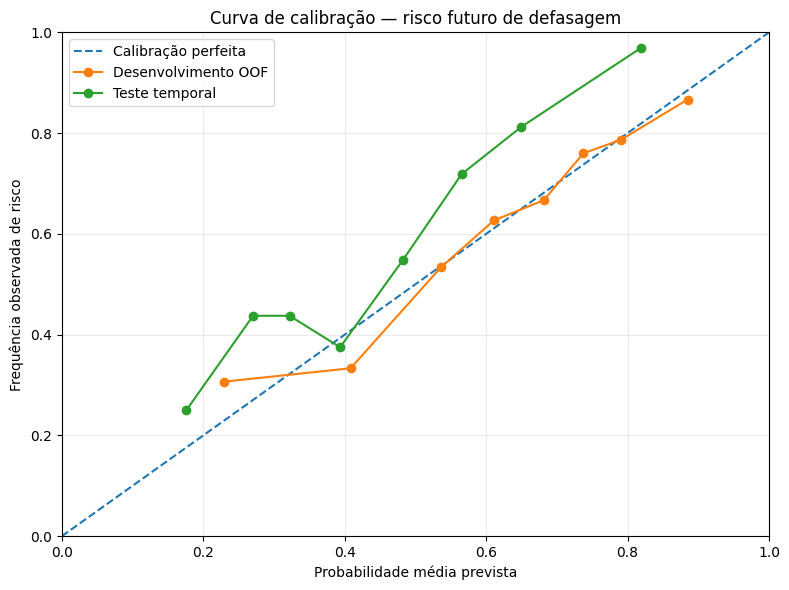

In [20]:
# ============================================================
# 9.2 DIAGNÓSTICO DE CALIBRAÇÃO
# ============================================================

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


# ------------------------------------------------------------
# Resumo numérico
# ------------------------------------------------------------

calibracao_resumo = pd.DataFrame({
    "Conjunto": [
        "Desenvolvimento OOF",
        "Teste temporal"
    ],
    "N": [
        len(y_train),
        len(y_test)
    ],
    "Prevalencia_real": [
        y_train.mean(),
        y_test.mean()
    ],
    "Probabilidade_media": [
        prob_logistica_oof.mean(),
        prob_logistica_test.mean()
    ],
    "Brier_Score": [
        brier_score_loss(
            y_train,
            prob_logistica_oof
        ),
        brier_score_loss(
            y_test,
            prob_logistica_test
        )
    ]
})


calibracao_resumo[
    [
        "Prevalencia_real",
        "Probabilidade_media",
        "Brier_Score"
    ]
] = calibracao_resumo[
    [
        "Prevalencia_real",
        "Probabilidade_media",
        "Brier_Score"
    ]
].round(4)


display(
    calibracao_resumo
)


# ------------------------------------------------------------
# Curvas de calibração
# ------------------------------------------------------------

frac_pos_train, mean_pred_train = calibration_curve(
    y_train,
    prob_logistica_oof,
    n_bins=8,
    strategy="quantile"
)

frac_pos_test, mean_pred_test = calibration_curve(
    y_test,
    prob_logistica_test,
    n_bins=8,
    strategy="quantile"
)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibração perfeita"
)


ax.plot(
    mean_pred_train,
    frac_pos_train,
    marker="o",
    label="Desenvolvimento OOF"
)


ax.plot(
    mean_pred_test,
    frac_pos_test,
    marker="o",
    label="Teste temporal"
)


ax.set_xlabel(
    "Probabilidade média prevista"
)

ax.set_ylabel(
    "Frequência observada de risco"
)

ax.set_title(
    "Curva de calibração — risco futuro de defasagem"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "modelo_curva_calibracao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 9.2.1 Resultado numérico da calibração

No conjunto de desenvolvimento, a probabilidade média prevista foi praticamente
idêntica à prevalência real:

- prevalência observada = **61,00%**;
- probabilidade média prevista = **60,98%**;
- Brier Score = **0,2011**.

Esse resultado indica bom alinhamento global das probabilidades dentro do período
utilizado para desenvolvimento.

No teste temporal independente, entretanto, foi observado:

- prevalência observada = **56,86%**;
- probabilidade média prevista = **45,97%**;
- Brier Score = **0,2060**.

Portanto, embora o Brier Score tenha apresentado apenas pequena deterioração, a
probabilidade média ficou aproximadamente **10,9 pontos percentuais abaixo da
frequência real de risco**.

Esse comportamento é compatível com uma tendência de subestimação das
probabilidades no período posterior.

A constatação também ajuda a interpretar o recall reduzido obtido com threshold
de 0,50: parte dos estudantes posteriormente defasados pode estar corretamente
posicionada acima de outros estudantes no ranking de risco, mas ainda abaixo do
ponto de corte utilizado para gerar o alerta.

Entretanto, a diferença entre média prevista e prevalência não é suficiente para
determinar sozinha a necessidade de recalibração.

É necessário observar se a subestimação ocorre de forma consistente ao longo das
diferentes faixas de probabilidade.

### 9.2.2 Interpretação da curva de calibração

A curva de calibração confirma comportamentos diferentes entre desenvolvimento e
teste temporal.

No conjunto de desenvolvimento, as probabilidades permanecem relativamente
próximas da linha de calibração perfeita.

No teste temporal, entretanto, a frequência observada de risco aparece acima da
probabilidade prevista em praticamente toda a distribuição.

O padrão é especialmente visível nas faixas intermediárias de probabilidade.

Isso indica uma tendência de **subestimação do risco no período posterior**.

É importante distinguir esse resultado da capacidade discriminativa do modelo.

Apesar da mudança de calibração, o teste apresentou:

- ROC-AUC = **0,7649**;
- PR-AUC = **0,8321**.

Portanto, o modelo continuou ordenando adequadamente estudantes de maior e menor
risco, mas o valor absoluto das probabilidades tornou-se mais conservador no novo
período.

### Decisão sobre recalibração

Não será aplicado um calibrador adicional neste momento.

O conjunto de desenvolvimento já apresenta calibração global satisfatória e uma
recalibração aprendida somente nesse período não possui evidência de que corrigiria
a mudança observada no período seguinte.

Também não seria metodologicamente adequado utilizar o conjunto de teste para
ajustar uma função de calibração e posteriormente reportar seu desempenho como
avaliação independente.

Assim, serão preservadas as probabilidades originais da Regressão Logística.

A mudança temporal de calibração será registrada como limitação do modelo e será
considerada na interpretação das probabilidades de risco para 2025.

## 9.3 Transportabilidade do threshold operacional

O threshold de 0,55 foi obtido utilizando exclusivamente as previsões out-of-fold
do conjunto de desenvolvimento.

A próxima análise verifica como esse ponto de corte se comporta no período
posterior.

O objetivo não é escolher novamente o threshold utilizando o teste.

Serão comparados apenas:

- threshold padrão = 0,50;
- threshold candidato do desenvolvimento = 0,55.

Essa análise permite avaliar se uma regra operacional definida em um período
permanece estável quando aplicada em outro período.

In [21]:
# ============================================================
# 9.3 THRESHOLD 0.50 × 0.55 NO TESTE TEMPORAL
# ANÁLISE DE TRANSPORTABILIDADE
# ============================================================

resultados_threshold_teste = []

for threshold in [
    0.50,
    threshold_escolhido
]:

    pred = (
        prob_logistica_test >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    resultados_threshold_teste.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            pred
        ),

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Alunos_sinalizados": int(
            pred.sum()
        ),

        "Pct_alunos_sinalizados": (
            pred.mean() * 100
        )
    })


threshold_teste = pd.DataFrame(
    resultados_threshold_teste
)


threshold_teste[
    [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Pct_alunos_sinalizados"
    ]
] = threshold_teste[
    [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Pct_alunos_sinalizados"
    ]
].round(4)


display(
    threshold_teste
)

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP,Alunos_sinalizados,Pct_alunos_sinalizados
0,0.50,0.6667,0.7830,0.5724,0.6614,87,23,62,83,106,41.5686
1,0.55,0.6745,0.8605,0.5103,0.6407,98,12,71,74,86,33.7255


### 9.3.1 Conclusão sobre o threshold operacional

O threshold de 0,55, definido exclusivamente no conjunto de desenvolvimento,
não preservou o comportamento esperado no período posterior.

No teste temporal:

| Threshold | Precision | Recall | Alunos sinalizados |
|---|---:|---:|---:|
| 0,50 | 78,30% | 57,24% | 106 |
| 0,55 | 86,05% | 51,03% | 86 |

O aumento do threshold melhorou a precision, porém reduziu ainda mais o recall.

Com o corte de 0,55, 71 dos 145 estudantes que posteriormente apresentaram
defasagem não seriam sinalizados.

Esse resultado demonstra que o ponto de corte definido em 2022 → 2023 não se
mostrou estável quando transportado para 2023 → 2024.

A instabilidade é consistente com a mudança de calibração observada anteriormente:
o modelo manteve boa capacidade de ordenação, mas passou a produzir probabilidades
mais conservadoras no período posterior.

### Decisão para o produto

Nenhum novo threshold será escolhido utilizando o conjunto de teste, pois isso
transformaria a avaliação independente em parte do processo de ajuste.

Por esse motivo, a principal saída do modelo será a **probabilidade estimada de
risco**, e não apenas uma classificação binária rígida.

O modelo será utilizado principalmente para:

1. ordenar estudantes por probabilidade de risco;
2. apoiar a priorização dos casos que merecem acompanhamento;
3. apresentar a probabilidade individual como sinal de alerta.

O threshold de 0,55 será registrado como o ponto de corte definido durante o
desenvolvimento, mas não será apresentado como uma regra operacional estável para
períodos futuros.

A avaliação temporal mostra que thresholds devem ser revisados quando novos
desfechos observados se tornarem disponíveis.

### Limitação importante

As probabilidades de 2025 devem ser interpretadas como **scores prospectivos de
risco**, especialmente úteis para ordenação e priorização.

Como não existem desfechos observados de 2025 na base do Datathon, não será
possível verificar neste momento se a calibração observada em 2023 → 2024 continuará
igual no período seguinte.

# 10. Interpretação das variáveis

Uma vantagem da Regressão Logística é permitir interpretação direta da direção das
associações aprendidas pelo modelo.

Como as variáveis numéricas são padronizadas antes do treinamento, os coeficientes
podem ser comparados em uma escala comum.

A interpretação será:

- coeficiente positivo → associado a aumento da probabilidade estimada de risco;
- coeficiente negativo → associado a redução da probabilidade estimada de risco;
- maior valor absoluto → maior contribuição para a decisão do modelo linear.

Também serão calculadas as `odds ratios`, obtidas pela exponenciação dos
coeficientes.

Essas relações devem ser interpretadas como **associações preditivas**.

O modelo não permite concluir que modificar isoladamente determinado indicador
causará redução ou aumento da defasagem futura.

In [22]:
# ============================================================
# 10.1 INTERPRETAÇÃO DOS COEFICIENTES
# REGRESSÃO LOGÍSTICA
# ============================================================

# O pipeline já está treinado em todo X_train
pipeline_logistica.fit(
    X_train,
    y_train
)


modelo_logistico_final_dev = (
    pipeline_logistica
    .named_steps["modelo"]
)


coeficientes = (
    modelo_logistico_final_dev
    .coef_[0]
)


interpretacao_coeficientes = pd.DataFrame({
    "Feature": features_modelo,
    "Coeficiente": coeficientes,
    "Odds_Ratio": np.exp(
        coeficientes
    ),
    "Importancia_Absoluta": np.abs(
        coeficientes
    )
})


interpretacao_coeficientes[
    "Direcao"
] = np.where(
    interpretacao_coeficientes[
        "Coeficiente"
    ] > 0,
    "Maior risco",
    "Menor risco"
)


interpretacao_coeficientes = (
    interpretacao_coeficientes
    .sort_values(
        "Importancia_Absoluta",
        ascending=False
    )
    .reset_index(drop=True)
)


interpretacao_coeficientes[
    [
        "Coeficiente",
        "Odds_Ratio",
        "Importancia_Absoluta"
    ]
] = interpretacao_coeficientes[
    [
        "Coeficiente",
        "Odds_Ratio",
        "Importancia_Absoluta"
    ]
].round(4)


display(
    interpretacao_coeficientes
)

,Feature,Coeficiente,Odds_Ratio,Importancia_Absoluta,Direcao
0,IPV,-0.7339,0.4800,0.7339,Menor risco
1,FASE_NUM,-0.6040,0.5466,0.6040,Menor risco
2,IPS,0.1526,1.1649,0.1526,Maior risco
3,IDA,-0.1275,0.8803,0.1275,Menor risco
4,IEG,-0.1222,0.8849,0.1222,Menor risco
5,TEMPO_PROGRAMA,0.0470,1.0481,0.0470,Maior risco
6,IAA_MODELO,0.0112,1.0113,0.0112,Maior risco


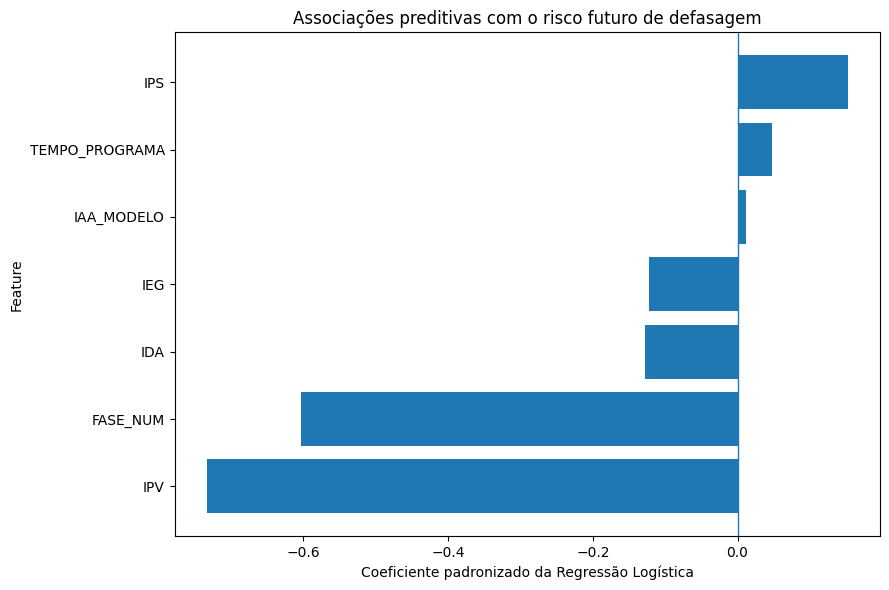

In [23]:
# ============================================================
# GRÁFICO — COEFICIENTES DO MODELO
# ============================================================

dados_plot = (
    interpretacao_coeficientes
    .sort_values(
        "Coeficiente"
    )
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.barh(
    dados_plot["Feature"],
    dados_plot["Coeficiente"]
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_title(
    "Associações preditivas com o risco futuro de defasagem"
)

ax.set_xlabel(
    "Coeficiente padronizado da Regressão Logística"
)

ax.set_ylabel(
    "Feature"
)


plt.tight_layout()


plt.savefig(
    OUTPUTS_DIR /
    "modelo_coeficientes_risco_defasagem.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 10.1.1 Interpretação dos coeficientes

A interpretação dos coeficientes confirma que algumas dimensões possuem associação
mais forte com o risco futuro de defasagem quando todas as demais features são
consideradas simultaneamente.

Como as variáveis foram padronizadas, as odds ratios representam aproximadamente
a mudança nas chances de risco associada ao aumento de um desvio-padrão da feature,
mantidas as demais variáveis constantes.

### IPV

O IPV apresentou o coeficiente de maior magnitude:

- coeficiente = **-0,7339**;
- odds ratio = **0,4800**.

O sinal negativo indica associação com menor risco futuro.

Em termos do modelo, um aumento de um desvio-padrão no IPV está associado a odds
estimadas de risco aproximadamente 52% menores, mantidas as demais variáveis
constantes.

Esse resultado é coerente com as análises exploratórias anteriores, nas quais o
IPV apresentou forte relação com desempenho acadêmico e engajamento.

### Fase atual

A `FASE_NUM` apresentou:

- coeficiente = **-0,6040**;
- odds ratio = **0,5466**.

Estudantes em fases mais avançadas apresentaram menor risco futuro estimado,
controladas as demais variáveis.

A fase atual é uma informação legítima disponível no momento da previsão e não
representa vazamento temporal.

Entretanto, sua importância deve ser interpretada considerando que o próprio
conceito de defasagem está relacionado à trajetória escolar do estudante.

Por esse motivo, a fase é tratada como um forte marcador preditivo da trajetória,
e não como uma causa independente da defasagem.

### IDA e IEG

IDA e IEG apresentaram coeficientes negativos:

- IDA: **-0,1275**, odds ratio = **0,8803**;
- IEG: **-0,1222**, odds ratio = **0,8849**.

Assim, melhores níveis de desempenho acadêmico e engajamento estão associados a
menor risco futuro estimado.

As magnitudes são menores do que as observadas para IPV e fase, mas a direção é
coerente com os padrões encontrados na EDA.

### IPS

O IPS apresentou:

- coeficiente = **0,1526**;
- odds ratio = **1,1649**.

No modelo multivariado, valores maiores de IPS aparecem associados a maior risco
futuro, quando as demais variáveis são mantidas constantes.

Esse resultado não deve ser interpretado como evidência de que melhores resultados
psicossociais aumentam a defasagem.

Na EDA, o IPS isoladamente não apresentou evidência robusta de antecipar piora
futura em IDA ou IEG.

O sinal positivo pode refletir a estrutura de correlação entre os preditores e o
efeito condicional produzido pela Regressão Logística.

Por isso, essa relação será tratada apenas como associação interna do modelo.

### Tempo no programa e IAA

O tempo no programa apresentou associação positiva pequena:

- coeficiente = **0,0470**.

O IAA apresentou coeficiente praticamente nulo:

- coeficiente = **0,0112**.

Assim, depois de controlar pelas demais características, essas variáveis
acrescentaram relativamente pouco ao componente linear da previsão.

### Síntese

Os sinais mais relevantes do modelo foram:

1. **IPV**, associado a menor risco futuro;
2. **fase atual**, também associada a menor risco;
3. IDA e IEG, com associações protetivas menores;
4. IPS, com associação condicional positiva que exige cautela interpretativa;
5. tempo no programa e IAA, com contribuições lineares reduzidas.

Esses coeficientes representam relações preditivas condicionais e não efeitos
causais.

In [24]:
# ============================================================
# 10.2 ESTABILIDADE DOS COEFICIENTES ENTRE FOLDS
# ============================================================

coeficientes_folds = []


for numero_fold, (idx_treino, idx_validacao) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    X_fold_train = X_train.iloc[idx_treino]
    y_fold_train = y_train.iloc[idx_treino]

    # Novo pipeline para cada fold
    modelo_fold = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "modelo",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )
        ]
    )

    modelo_fold.fit(
        X_fold_train,
        y_fold_train
    )

    coefs = (
        modelo_fold
        .named_steps["modelo"]
        .coef_[0]
    )

    for feature, coef in zip(
        features_modelo,
        coefs
    ):

        coeficientes_folds.append({
            "Fold": numero_fold,
            "Feature": feature,
            "Coeficiente": coef
        })


coeficientes_folds = pd.DataFrame(
    coeficientes_folds
)


# ------------------------------------------------------------
# Resumo de estabilidade
# ------------------------------------------------------------

estabilidade_coeficientes = (
    coeficientes_folds
    .groupby("Feature")
    .agg(
        Coef_Medio=(
            "Coeficiente",
            "mean"
        ),
        Coef_Desvio=(
            "Coeficiente",
            "std"
        ),
        Coef_Min=(
            "Coeficiente",
            "min"
        ),
        Coef_Max=(
            "Coeficiente",
            "max"
        ),
        Folds_Positivos=(
            "Coeficiente",
            lambda x: int(
                (x > 0).sum()
            )
        ),
        Folds_Negativos=(
            "Coeficiente",
            lambda x: int(
                (x < 0).sum()
            )
        )
    )
    .reset_index()
)


estabilidade_coeficientes[
    "Sinal_Consistente"
] = (
    (estabilidade_coeficientes["Folds_Positivos"] == 5)
    |
    (estabilidade_coeficientes["Folds_Negativos"] == 5)
)


estabilidade_coeficientes[
    [
        "Coef_Medio",
        "Coef_Desvio",
        "Coef_Min",
        "Coef_Max"
    ]
] = estabilidade_coeficientes[
    [
        "Coef_Medio",
        "Coef_Desvio",
        "Coef_Min",
        "Coef_Max"
    ]
].round(4)


estabilidade_coeficientes = (
    estabilidade_coeficientes
    .sort_values(
        "Coef_Medio",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    estabilidade_coeficientes
)

,Feature,Coef_Medio,Coef_Desvio,Coef_Min,Coef_Max,Folds_Positivos,Folds_Negativos,Sinal_Consistente
0,IPV,-0.7321,0.0933,-0.8298,-0.5862,0,5,True
1,FASE_NUM,-0.6036,0.0627,-0.6961,-0.5197,0,5,True
2,IPS,0.1528,0.0340,0.1129,0.1987,5,0,True
3,IDA,-0.1293,0.0273,-0.1614,-0.0980,0,5,True
4,IEG,-0.1256,0.0727,-0.2363,-0.0375,0,5,True
5,TEMPO_PROGRAMA,0.0446,0.0875,-0.0954,0.1226,4,1,False
6,IAA_MODELO,0.0105,0.0363,-0.0466,0.0543,4,1,False


## 10.2.1 Estabilidade das associações entre os folds

A estabilidade dos coeficientes foi avaliada nos cinco folds utilizados durante o
desenvolvimento.

Cinco das sete features mantiveram a mesma direção em todos os folds.

### Associações negativas consistentes

- **IPV:** negativo em 5 de 5 folds;
- **FASE_NUM:** negativo em 5 de 5 folds;
- **IDA:** negativo em 5 de 5 folds;
- **IEG:** negativo em 5 de 5 folds.

IPV e fase também apresentaram as maiores magnitudes médias, reforçando sua
relevância para o componente linear do modelo.

### Associação positiva consistente

O IPS apresentou coeficiente positivo nos cinco folds.

Portanto, o sinal observado no modelo final de desenvolvimento não decorre apenas
de uma divisão específica da amostra.

Ainda assim, essa relação deve ser interpretada com cautela.

O coeficiente representa o efeito condicional do IPS na presença simultânea das
demais variáveis e não demonstra que um aumento do indicador psicossocial provoque
maior defasagem.

### Variáveis de baixa estabilidade

`TEMPO_PROGRAMA` e `IAA_MODELO` mudaram de sinal em um dos cinco folds.

Além disso, seus coeficientes médios apresentaram magnitude pequena:

- TEMPO_PROGRAMA: aproximadamente **0,045**;
- IAA_MODELO: aproximadamente **0,011**.

Assim, não existem evidências de uma associação linear independente forte para
essas duas variáveis.

### Decisão

As sete features serão preservadas no pipeline final.

A instabilidade de duas variáveis de pequena magnitude, isoladamente, não constitui
evidência suficiente para modificar um modelo que já foi definido e avaliado
temporalmente.

Na interpretação gerencial, entretanto, o foco será concentrado nas associações
mais fortes e estáveis.

Com isso, encerra-se a etapa de interpretação do modelo.

# 11. Treinamento final e exportação do pipeline

A avaliação do modelo foi concluída utilizando um teste temporal independente.

A partir deste ponto, o objetivo deixa de ser estimar desempenho e passa a ser
construir a versão destinada à aplicação prospectiva em 2025.

Como os desfechos de 2023 e 2024 já são conhecidos, todo o histórico rotulado
elegível poderá ser utilizado no treinamento final.

Serão combinadas:

- transição 2022 → 2023;
- transição 2023 → 2024.

Serão mantidas apenas observações das Fases 0 a 7, população para a qual o modelo
foi definido.

Um estudante poderá aparecer em duas observações caso possua informações em anos
consecutivos.

Essas linhas representam momentos temporais distintos da trajetória e serão
utilizadas no modelo de produção somente depois de concluída a avaliação
independente.

Nenhuma nova métrica de desempenho calculada nessa base será tratada como evidência
de generalização.

In [25]:
# ============================================================
# 11.1 CONSTRUÇÃO DA BASE ROTULADA FINAL
# ============================================================

# ------------------------------------------------------------
# Transição 2022 → 2023
# ------------------------------------------------------------

final_22_23 = painel_22_23.loc[
    painel_22_23["FASE_NUM"].between(0, 7)
].copy()


# ------------------------------------------------------------
# Transição 2023 → 2024
# Agora podemos utilizar todos os alunos elegíveis,
# inclusive os que fizeram parte do antigo teste.
# ------------------------------------------------------------

final_23_24 = painel_23_24.loc[
    painel_23_24["FASE_NUM"].between(0, 7)
].copy()


# ------------------------------------------------------------
# Identificador apenas para auditoria
# NÃO será usado como feature
# ------------------------------------------------------------

final_22_23["ID_AMOSTRA"] = (
    final_22_23["RA"].astype(str)
    + "_2022"
)

final_23_24["ID_AMOSTRA"] = (
    final_23_24["RA"].astype(str)
    + "_2023"
)


# ------------------------------------------------------------
# Une os dois períodos
# ------------------------------------------------------------

base_final_rotulada = pd.concat(
    [
        final_22_23,
        final_23_24
    ],
    ignore_index=True
)


X_final = base_final_rotulada[
    features_modelo
].copy()

y_final = base_final_rotulada[
    "RISCO_FUTURO"
].astype(int)


# ------------------------------------------------------------
# Auditoria
# ------------------------------------------------------------

print("=" * 70)
print("BASE FINAL ROTULADA")
print("=" * 70)

print(
    "2022 → 2023:",
    len(final_22_23)
)

print(
    "2023 → 2024:",
    len(final_23_24)
)

print(
    "Total de observações:",
    len(base_final_rotulada)
)

print(
    "Estudantes únicos:",
    base_final_rotulada["RA"].nunique()
)

print(
    "IDs aluno-ano únicos:",
    base_final_rotulada["ID_AMOSTRA"].nunique()
)

print(
    "Duplicidades aluno-ano:",
    base_final_rotulada["ID_AMOSTRA"].duplicated().sum()
)

print(
    "Prevalência global de risco:",
    f"{y_final.mean() * 100:.2f}%"
)


print("\nRisco por período:")

display(
    base_final_rotulada
    .groupby(
        ["ANO_FEATURES", "ANO_ALVO"]
    )
    ["RISCO_FUTURO"]
    .agg(
        Alunos="size",
        Casos_Risco="sum",
        Taxa_Risco="mean"
    )
    .reset_index()
    .assign(
        Taxa_Risco=lambda x:
            (x["Taxa_Risco"] * 100).round(2)
    )
)


print("\nValores ausentes na base final:")

display(
    X_final
    .isna()
    .sum()
    .to_frame("Ausentes")
)

BASE FINAL ROTULADA
2022 → 2023: 600
2023 → 2024: 706
Total de observações: 1306
Estudantes únicos: 855
IDs aluno-ano únicos: 1306
Duplicidades aluno-ano: 0
Prevalência global de risco: 51.76%

Risco por período:


,ANO_FEATURES,ANO_ALVO,Alunos,Casos_Risco,Taxa_Risco
0,2022,2023,600,366,61.00
1,2023,2024,706,310,43.91



Valores ausentes na base final:


,Ausentes
FASE_NUM,0
TEMPO_PROGRAMA,0
IDA,13
IEG,13
IAA_MODELO,137
IPS,3
IPV,13


## 11.1 Auditoria da base final de treinamento

Após a conclusão da avaliação temporal independente, os dois períodos rotulados
foram reunidos para construir a versão de produção do modelo.

A base final contém:

- **600 observações** da transição 2022 → 2023;
- **706 observações** da transição 2023 → 2024;
- **1.306 observações aluno-ano** no total;
- **855 estudantes únicos**;
- nenhuma duplicidade de identificador aluno-ano.

A prevalência global de risco foi de **51,76%**.

Entretanto, existe diferença entre os períodos:

- 2022 → 2023: **61,00%** de risco;
- 2023 → 2024: **43,91%** de risco.

Essa diferença temporal já foi considerada durante a avaliação independente e
reforça a necessidade de monitoramento periódico do modelo após sua implantação.

### Valores ausentes

A base final contém alguns valores ausentes, principalmente no IAA de 2023.

Esses registros serão preservados.

O pipeline possui imputação pela mediana, portanto o tratamento dos valores
ausentes fará parte do próprio artefato serializado.

Nenhuma linha será descartada apenas pela ausência pontual de um indicador.

A partir desta base será treinada a versão destinada exclusivamente à inferência
prospectiva de risco em 2025.

As métricas calculadas anteriormente no teste temporal permanecem como referência
de desempenho; o ajuste com todos os dados rotulados não será utilizado para
produzir novas estimativas de generalização.

In [26]:
# ============================================================
# 11.2 TREINAMENTO FINAL E EXPORTAÇÃO DO ARTEFATO
# ============================================================

import joblib

from sklearn.base import clone


# ------------------------------------------------------------
# Diretório de modelos
# ------------------------------------------------------------

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Clona a arquitetura escolhida
# para não depender do estado de fits anteriores
# ------------------------------------------------------------

pipeline_producao = clone(
    pipeline_logistica
)


# ------------------------------------------------------------
# Fit com todo o histórico rotulado elegível
# ------------------------------------------------------------

pipeline_producao.fit(
    X_final,
    y_final
)


# ------------------------------------------------------------
# Bundle de produção
# ------------------------------------------------------------

bundle_modelo = {
    "pipeline": pipeline_producao,

    "features": features_modelo,

    "fases_elegiveis": list(
        range(0, 8)
    ),

    "ano_features_inferencia": 2024,
    "ano_alvo_inferencia": 2025,

    "definicao_alvo":
        "RISCO_FUTURO = 1 se DEFASAGEM_ANALISE do ano seguinte < 0",

    "populacao_modelo":
        "Estudantes das Fases 0 a 7",

    "threshold_desenvolvimento":
        float(threshold_escolhido),

    "saida_principal":
        "predict_proba da classe 1",

    "observacao_threshold":
        (
            "O threshold foi definido no desenvolvimento, "
            "mas não se mostrou estável temporalmente. "
            "A probabilidade deve ser priorizada no produto."
        ),

    "n_observacoes_treinamento":
        int(len(X_final)),

    "n_estudantes_unicos":
        int(
            base_final_rotulada[
                "RA"
            ].nunique()
        )
}


# ------------------------------------------------------------
# Salva
# ------------------------------------------------------------

caminho_modelo = (
    MODELS_DIR
    / "modelo_risco_defasagem_2025.joblib"
)


joblib.dump(
    bundle_modelo,
    caminho_modelo
)


print(
    "✅ Modelo salvo em:"
)

print(
    caminho_modelo
)

✅ Modelo salvo em:
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/models/modelo_risco_defasagem_2025.joblib


In [27]:
# ============================================================
# 11.3 VALIDAÇÃO DO ARTEFATO SERIALIZADO
# ============================================================

bundle_recarregado = joblib.load(
    caminho_modelo
)


pipeline_recarregado = (
    bundle_recarregado[
        "pipeline"
    ]
)


# ------------------------------------------------------------
# Compara previsões antes/depois da serialização
# usando apenas algumas linhas da base de 2024
# ------------------------------------------------------------

amostra_validacao = (
    X_2025
    .head(10)
    .copy()
)


prob_antes = (
    pipeline_producao
    .predict_proba(
        amostra_validacao
    )[:, 1]
)


prob_depois = (
    pipeline_recarregado
    .predict_proba(
        amostra_validacao
    )[:, 1]
)


diferenca_maxima = np.max(
    np.abs(
        prob_antes
        - prob_depois
    )
)


print(
    "Features salvas:",
    bundle_recarregado[
        "features"
    ]
)

print(
    "Fases elegíveis:",
    bundle_recarregado[
        "fases_elegiveis"
    ]
)

print(
    "Ano previsto:",
    bundle_recarregado[
        "ano_alvo_inferencia"
    ]
)

print(
    "Observações de treinamento:",
    bundle_recarregado[
        "n_observacoes_treinamento"
    ]
)

print(
    "Diferença máxima antes/depois do load:",
    diferenca_maxima
)

print(
    "Artefato íntegro:",
    bool(
        np.isclose(
            diferenca_maxima,
            0.0
        )
    )
)

Features salvas: ['FASE_NUM', 'TEMPO_PROGRAMA', 'IDA', 'IEG', 'IAA_MODELO', 'IPS', 'IPV']
Fases elegíveis: [0, 1, 2, 3, 4, 5, 6, 7]
Ano previsto: 2025
Observações de treinamento: 1306
Diferença máxima antes/depois do load: 0.0
Artefato íntegro: True


## 11.3.1 Validação do artefato de produção

O pipeline final foi treinado com **1.306 observações aluno-ano** e serializado no
arquivo:

`modelo_risco_defasagem_2025.joblib`

O artefato contém:

- pipeline completo de pré-processamento e Regressão Logística;
- lista das sete features esperadas;
- população elegível das Fases 0 a 7;
- definição do alvo;
- ano de inferência;
- threshold definido durante o desenvolvimento;
- observações metodológicas necessárias para utilização no produto.

Após a serialização, o arquivo foi recarregado e suas previsões foram comparadas
com aquelas produzidas pelo objeto original.

A diferença máxima encontrada foi:

**0,0**

Portanto, o artefato serializado reproduz exatamente as previsões do pipeline
treinado e está apto para utilização na etapa de inferência e posteriormente no
Streamlit.

# 12. Aplicação do modelo — previsão de risco em 2025

Após o treinamento final, o modelo será aplicado aos estudantes avaliados em 2024
para produzir uma estimativa prospectiva de risco para 2025.

A população elegível contém **1.054 estudantes das Fases 0 a 7**, todos com as
sete features necessárias disponíveis.

Para cada estudante serão produzidos:

- probabilidade estimada de risco em 2025;
- posição no ranking de risco;
- percentil de risco dentro da população avaliada.

A probabilidade será tratada como a principal saída do modelo.

O threshold encontrado durante o desenvolvimento não será utilizado como uma
fronteira universal entre "risco" e "não risco", pois sua estabilidade temporal
não foi confirmada no teste independente.

O ranking permite utilizar o modelo como ferramenta de priorização, identificando
quais estudantes apresentam os maiores scores prospectivos e podem merecer
acompanhamento mais próximo.

Como o Datathon não fornece o desfecho real de 2025, essas previsões não podem ser
tratadas como resultados confirmados nem utilizadas para calcular métricas de
desempenho.

In [28]:
# ============================================================
# 12.1 INFERÊNCIA — PROBABILIDADE DE RISCO EM 2025
# ============================================================

# ------------------------------------------------------------
# Pipeline salvo e validado
# ------------------------------------------------------------

pipeline_2025 = bundle_recarregado[
    "pipeline"
]


# ------------------------------------------------------------
# Probabilidades
# ------------------------------------------------------------

prob_risco_2025 = (
    pipeline_2025
    .predict_proba(
        X_2025
    )[:, 1]
)


# ------------------------------------------------------------
# Tabela individual de resultados
# ------------------------------------------------------------

previsoes_2025 = base_2025[
    [
        "RA",
        "FASE_NUM",
        "TEMPO_PROGRAMA",
        "IDA",
        "IEG",
        "IAA_MODELO",
        "IPS",
        "IPV"
    ]
].copy()


previsoes_2025[
    "PROB_RISCO_2025"
] = prob_risco_2025


# Ranking:
# 1 = maior risco estimado
previsoes_2025[
    "RANK_RISCO_2025"
] = (
    previsoes_2025[
        "PROB_RISCO_2025"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)


# Percentil:
# valores próximos de 100 = maior score relativo
previsoes_2025[
    "PERCENTIL_RISCO_2025"
] = (
    previsoes_2025[
        "PROB_RISCO_2025"
    ]
    .rank(
        method="average",
        pct=True
    )
    * 100
)


previsoes_2025[
    "PERCENTIL_RISCO_2025"
] = (
    previsoes_2025[
        "PERCENTIL_RISCO_2025"
    ]
    .round(2)
)


# ------------------------------------------------------------
# Auditoria geral
# ------------------------------------------------------------

print("=" * 70)
print("PREVISÃO PROSPECTIVA — RISCO 2025")
print("=" * 70)

print(
    "Estudantes avaliados:",
    len(previsoes_2025)
)

print(
    "Probabilidade média:",
    round(
        previsoes_2025[
            "PROB_RISCO_2025"
        ].mean(),
        4
    )
)

print(
    "Probabilidade mediana:",
    round(
        previsoes_2025[
            "PROB_RISCO_2025"
        ].median(),
        4
    )
)

print(
    "Probabilidade mínima:",
    round(
        previsoes_2025[
            "PROB_RISCO_2025"
        ].min(),
        4
    )
)

print(
    "Probabilidade máxima:",
    round(
        previsoes_2025[
            "PROB_RISCO_2025"
        ].max(),
        4
    )
)


print("\nPercentis da distribuição:")

display(
    previsoes_2025[
        "PROB_RISCO_2025"
    ]
    .quantile(
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .rename(
        "Probabilidade"
    )
    .to_frame()
    .round(4)
)


print("\n20 maiores scores de risco:")

display(
    previsoes_2025
    .sort_values(
        "PROB_RISCO_2025",
        ascending=False
    )
    .head(20)
    [
        [
            "RA",
            "FASE_NUM",
            "PROB_RISCO_2025",
            "RANK_RISCO_2025",
            "PERCENTIL_RISCO_2025"
        ]
    ]
    .round(
        {
            "PROB_RISCO_2025": 4
        }
    )
)

PREVISÃO PROSPECTIVA — RISCO 2025
Estudantes avaliados: 1054
Probabilidade média: 0.5893
Probabilidade mediana: 0.6391
Probabilidade mínima: 0.038
Probabilidade máxima: 0.9893

Percentis da distribuição:


,Probabilidade
0.10,0.2166
0.25,0.4045
0.50,0.6391
0.75,0.7848
0.90,0.8930
0.95,0.9309



20 maiores scores de risco:


,RA,FASE_NUM,PROB_RISCO_2025,RANK_RISCO_2025,PERCENTIL_RISCO_2025
273,RA-672,1,0.9893,1,100.00
542,RA-798,2,0.9890,2,99.91
547,RA-1071,2,0.9890,3,99.81
568,RA-484,3,0.9858,4,99.72
256,RA-995,1,0.9855,5,99.62
396,RA-497,2,0.9837,6,99.53
215,RA-750,1,0.9823,7,99.43
35,RA-863,0,0.9797,8,99.34
546,RA-1507,2,0.9785,9,99.24
379,RA-967,1,0.9780,10,99.15


## 12.1.1 Distribuição prospectiva do risco em 2025

O modelo foi aplicado aos **1.054 estudantes elegíveis** avaliados em 2024.

As probabilidades estimadas apresentaram ampla dispersão:

- mínimo = **3,80%**;
- mediana = **63,91%**;
- média = **58,93%**;
- percentil 75 = **78,48%**;
- percentil 90 = **89,30%**;
- percentil 95 = **93,09%**;
- máximo = **98,93%**.

Essa amplitude permite utilizar o modelo para ordenar estudantes de acordo com o
risco prospectivo estimado.

### Cuidado na interpretação

A média das probabilidades não deve ser interpretada como previsão de que 58,93%
dos estudantes necessariamente estarão defasados em 2025.

Durante a validação temporal foi identificada mudança de calibração entre os
períodos, embora a capacidade de ordenação tenha permanecido adequada.

Por isso, a principal utilização operacional será o **ranking relativo de risco**.

Estudantes com scores maiores devem ser interpretados como casos que o modelo
considera prioritários em relação aos demais estudantes avaliados, e não como
desfechos já confirmados.

Os maiores scores chegaram a aproximadamente 99%, demonstrando que existe um grupo
de estudantes claramente destacado no topo da distribuição.

Antes da definição das faixas de prioridade, será verificado se essa concentração
está excessivamente associada a determinadas fases do programa.

In [29]:
# ============================================================
# 12.2 AUDITORIA DAS PREVISÕES DE 2025 POR FASE
# ============================================================

resumo_risco_fase_2025 = (
    previsoes_2025
    .groupby("FASE_NUM")
    .agg(
        Alunos=(
            "RA",
            "size"
        ),

        Prob_Media=(
            "PROB_RISCO_2025",
            "mean"
        ),

        Prob_Mediana=(
            "PROB_RISCO_2025",
            "median"
        ),

        Prob_P75=(
            "PROB_RISCO_2025",
            lambda x: x.quantile(0.75)
        ),

        Prob_P90=(
            "PROB_RISCO_2025",
            lambda x: x.quantile(0.90)
        ),

        Prob_Max=(
            "PROB_RISCO_2025",
            "max"
        )
    )
    .reset_index()
)


resumo_risco_fase_2025[
    [
        "Prob_Media",
        "Prob_Mediana",
        "Prob_P75",
        "Prob_P90",
        "Prob_Max"
    ]
] = resumo_risco_fase_2025[
    [
        "Prob_Media",
        "Prob_Mediana",
        "Prob_P75",
        "Prob_P90",
        "Prob_Max"
    ]
].round(4)


display(
    resumo_risco_fase_2025
)

,FASE_NUM,Alunos,Prob_Media,Prob_Mediana,Prob_P75,Prob_P90,Prob_Max
0,0,196,0.7370,0.7383,0.8507,0.9176,0.9797
1,1,185,0.6553,0.6623,0.7850,0.9114,0.9893
2,2,185,0.6427,0.6715,0.7936,0.9106,0.9890
3,3,211,0.6616,0.7107,0.8306,0.9065,0.9858
4,4,115,0.4098,0.3622,0.5531,0.7031,0.9737
5,5,100,0.3460,0.3062,0.4896,0.6800,0.8233
6,6,25,0.2083,0.1689,0.2484,0.3765,0.4877
7,7,37,0.2699,0.1478,0.2953,0.7528,0.7723


In [30]:
# ============================================================
# COMPOSIÇÃO DO TOP 10% DE RISCO POR FASE
# ============================================================

corte_top10 = (
    previsoes_2025[
        "PROB_RISCO_2025"
    ]
    .quantile(0.90)
)


top10_risco_2025 = previsoes_2025.loc[
    previsoes_2025[
        "PROB_RISCO_2025"
    ] >= corte_top10
].copy()


composicao_top10_fase = (
    top10_risco_2025
    .groupby("FASE_NUM")
    .agg(
        Alunos=("RA", "size")
    )
    .reset_index()
)


composicao_top10_fase[
    "Pct_Top10"
] = (
    composicao_top10_fase[
        "Alunos"
    ]
    / len(top10_risco_2025)
    * 100
).round(2)


print(
    "Corte do top 10%:",
    round(
        corte_top10,
        4
    )
)

print(
    "Alunos no grupo:",
    len(top10_risco_2025)
)


display(
    composicao_top10_fase
)

Corte do top 10%: 0.893
Alunos no grupo: 106


,FASE_NUM,Alunos,Pct_Top10
0,0,30,28.30
1,1,26,24.53
2,2,24,22.64
3,3,24,22.64
4,4,2,1.89


## 12.2.1 Interpretação do risco por fase

A distribuição das previsões confirma forte associação entre a fase atual e o
score prospectivo de risco.

As probabilidades médias foram maiores nas fases iniciais:

- Fase 0: **73,70%**;
- Fase 1: **65,53%**;
- Fase 2: **64,27%**;
- Fase 3: **66,16%**.

A partir da Fase 4 ocorre redução importante:

- Fase 4: **40,98%**;
- Fase 5: **34,60%**;
- Fase 6: **20,83%**;
- Fase 7: **26,99%**.

O mesmo padrão aparece entre os 10% maiores scores globais.

O corte correspondente ao percentil 90 foi **0,8930**, formando um grupo de
106 estudantes.

Sua composição foi:

- Fase 0: 30 estudantes;
- Fase 1: 26;
- Fase 2: 24;
- Fase 3: 24;
- Fase 4: 2;
- Fases 5 a 7: nenhum estudante.

Esse resultado é consistente com o coeficiente negativo de `FASE_NUM` identificado
na Regressão Logística.

Entretanto, a interpretação operacional exige cautela.

Um ranking exclusivamente global tende a concentrar a priorização nas fases
iniciais e pode deixar de destacar estudantes de fases avançadas que possuem
risco elevado em relação aos seus próprios pares.

Por isso, o produto manterá duas perspectivas complementares:

1. **score global de risco**, produzido diretamente pelo modelo;
2. **posição relativa dentro da fase**, utilizada como informação complementar
   para priorização gerencial.

A segunda medida não substitui a probabilidade predita e não altera o modelo.
Ela apenas fornece contexto para comparação entre estudantes que se encontram
em momentos semelhantes da trajetória educacional.

In [31]:
# ============================================================
# 12.3 RANKING E PERCENTIL DE RISCO DENTRO DA FASE
# ============================================================

previsoes_2025[
    "RANK_RISCO_FASE_2025"
] = (
    previsoes_2025
    .groupby("FASE_NUM")[
        "PROB_RISCO_2025"
    ]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)


previsoes_2025[
    "PERCENTIL_RISCO_FASE_2025"
] = (
    previsoes_2025
    .groupby("FASE_NUM")[
        "PROB_RISCO_2025"
    ]
    .rank(
        method="average",
        pct=True
    )
    * 100
).round(2)


# ------------------------------------------------------------
# Auditoria: 5 maiores scores de cada fase
# ------------------------------------------------------------

top5_por_fase = (
    previsoes_2025
    .sort_values(
        [
            "FASE_NUM",
            "PROB_RISCO_2025"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "FASE_NUM",
        group_keys=False
    )
    .head(5)
    [
        [
            "RA",
            "FASE_NUM",
            "PROB_RISCO_2025",
            "RANK_RISCO_2025",
            "PERCENTIL_RISCO_2025",
            "RANK_RISCO_FASE_2025",
            "PERCENTIL_RISCO_FASE_2025"
        ]
    ]
)


display(
    top5_por_fase.round(
        {
            "PROB_RISCO_2025": 4,
            "PERCENTIL_RISCO_2025": 2,
            "PERCENTIL_RISCO_FASE_2025": 2
        }
    )
)

,RA,FASE_NUM,PROB_RISCO_2025,RANK_RISCO_2025,PERCENTIL_RISCO_2025,RANK_RISCO_FASE_2025,PERCENTIL_RISCO_FASE_2025
35,RA-863,0,0.9797,8,99.34,1,100.00
114,RA-947,0,0.9762,13,98.86,2,99.49
4,RA-1278,0,0.9751,15,98.67,3,98.98
45,RA-1302,0,0.9688,18,98.39,4,98.47
194,RA-1392,0,0.9654,21,98.10,5,97.96
273,RA-672,1,0.9893,1,100.00,1,100.00
256,RA-995,1,0.9855,5,99.62,2,99.46
215,RA-750,1,0.9823,7,99.43,3,98.92
379,RA-967,1,0.9780,10,99.15,4,98.38
281,RA-741,1,0.9766,12,98.96,5,97.84


## 12.3.1 Interpretação do ranking dentro da fase

A comparação dentro da própria fase acrescenta uma perspectiva importante ao
ranking global.

Como a fase atual possui forte associação com o risco previsto, estudantes das
fases mais avançadas tendem a apresentar scores globais menores.

Isso não significa que não existam casos prioritários nessas fases.

Por exemplo, o estudante com maior score da Fase 6 apresentou probabilidade
estimada de aproximadamente **48,77%**.

No ranking geral, esse estudante aparece apenas no percentil **32,54**.

Entretanto, dentro da Fase 6, ele ocupa:

- posição = **1º**;
- percentil relativo à fase = **100**.

Situação semelhante ocorre na Fase 7, em que o maior score é aproximadamente
**77,23%** e corresponde ao primeiro colocado dentro da própria fase.

Portanto, utilizar somente um corte global poderia ocultar estudantes que se
destacam negativamente em relação aos colegas em estágio educacional semelhante.

O ranking dentro da fase não modifica a previsão do modelo e não representa uma
nova probabilidade.

Ele funciona apenas como uma camada de contexto gerencial para apoiar a
priorização dos acompanhamentos.

## 12.4 Construção de faixas gerenciais de prioridade

Como o threshold absoluto não apresentou estabilidade temporal, as faixas
operacionais não serão definidas a partir de uma probabilidade fixa.

Será utilizada uma estratégia baseada em posição relativa.

Serão considerados simultaneamente:

- percentil global do score;
- percentil do score dentro da própria fase.

A proposta inicial é:

- **Prioridade muito alta:** top 10% global ou top 10% dentro da fase;
- **Prioridade alta:** top 25% global ou top 25% dentro da fase;
- **Prioridade moderada:** metade superior global ou dentro da fase;
- **Prioridade reduzida:** demais estudantes.

Essas categorias representam prioridade de acompanhamento e não classes
estatísticas de "defasado" ou "não defasado".

Antes de incorporá-las ao produto, será auditada a quantidade de estudantes
classificada em cada faixa e sua distribuição entre as fases.

In [32]:
# ============================================================
# 12.4 FAIXAS GERENCIAIS DE PRIORIDADE
# ============================================================

def definir_prioridade(row):

    pct_global = row[
        "PERCENTIL_RISCO_2025"
    ]

    pct_fase = row[
        "PERCENTIL_RISCO_FASE_2025"
    ]

    if (
        pct_global >= 90
        or pct_fase >= 90
    ):
        return "Muito alta"

    elif (
        pct_global >= 75
        or pct_fase >= 75
    ):
        return "Alta"

    elif (
        pct_global >= 50
        or pct_fase >= 50
    ):
        return "Moderada"

    else:
        return "Reduzida"


previsoes_2025[
    "PRIORIDADE_2025"
] = previsoes_2025.apply(
    definir_prioridade,
    axis=1
)


# ------------------------------------------------------------
# Resumo geral
# ------------------------------------------------------------

ordem_prioridade = [
    "Muito alta",
    "Alta",
    "Moderada",
    "Reduzida"
]


resumo_prioridade_2025 = (
    previsoes_2025
    .groupby(
        "PRIORIDADE_2025"
    )
    .agg(
        Alunos=(
            "RA",
            "size"
        ),
        Prob_Media=(
            "PROB_RISCO_2025",
            "mean"
        ),
        Prob_Min=(
            "PROB_RISCO_2025",
            "min"
        ),
        Prob_Max=(
            "PROB_RISCO_2025",
            "max"
        )
    )
    .reindex(
        ordem_prioridade
    )
    .reset_index()
)


resumo_prioridade_2025[
    "Pct_Alunos"
] = (
    resumo_prioridade_2025[
        "Alunos"
    ]
    / len(previsoes_2025)
    * 100
)


resumo_prioridade_2025[
    [
        "Prob_Media",
        "Prob_Min",
        "Prob_Max",
        "Pct_Alunos"
    ]
] = resumo_prioridade_2025[
    [
        "Prob_Media",
        "Prob_Min",
        "Prob_Max",
        "Pct_Alunos"
    ]
].round(4)


print(
    "Distribuição geral das prioridades:"
)

display(
    resumo_prioridade_2025
)


# ------------------------------------------------------------
# Distribuição por fase
# ------------------------------------------------------------

prioridade_por_fase = pd.crosstab(
    previsoes_2025[
        "FASE_NUM"
    ],
    previsoes_2025[
        "PRIORIDADE_2025"
    ]
)


prioridade_por_fase = (
    prioridade_por_fase
    .reindex(
        columns=ordem_prioridade,
        fill_value=0
    )
)


print(
    "\nQuantidade por fase:"
)

display(
    prioridade_por_fase
)


# ------------------------------------------------------------
# Percentual dentro de cada fase
# ------------------------------------------------------------

prioridade_pct_fase = (
    prioridade_por_fase
    .div(
        prioridade_por_fase.sum(
            axis=1
        ),
        axis=0
    )
    * 100
).round(2)


print(
    "\nPercentual dentro de cada fase:"
)

display(
    prioridade_pct_fase
)

Distribuição geral das prioridades:


,PRIORIDADE_2025,Alunos,Prob_Media,Prob_Min,Prob_Max,Pct_Alunos
0,Muito alta,134,0.8934,0.3929,0.9893,12.7135
1,Alta,191,0.7766,0.2484,0.8920,18.1214
2,Moderada,303,0.6309,0.1478,0.7840,28.7476
3,Reduzida,426,0.3800,0.0380,0.6370,40.4175



Quantidade por fase:


PRIORIDADE_2025,Muito alta,Alta,Moderada,Reduzida
FASE_NUM,,,,
0,30,50,71,45
1,26,21,51,87
2,24,25,58,78
3,24,53,54,80
4,12,17,29,57
5,11,15,25,49
6,3,4,6,12
7,4,6,9,18



Percentual dentro de cada fase:


PRIORIDADE_2025,Muito alta,Alta,Moderada,Reduzida
FASE_NUM,,,,
0,15.31,25.51,36.22,22.96
1,14.05,11.35,27.57,47.03
2,12.97,13.51,31.35,42.16
3,11.37,25.12,25.59,37.91
4,10.43,14.78,25.22,49.57
5,11.00,15.00,25.00,49.00
6,12.00,16.00,24.00,48.00
7,10.81,16.22,24.32,48.65


## 12.4.1 Validação das faixas gerenciais

A estratégia combinando percentil global e percentil dentro da fase produziu uma
distribuição operacionalmente equilibrada.

Foram classificados:

- **134 estudantes (12,71%)** como prioridade muito alta;
- **191 estudantes (18,12%)** como prioridade alta;
- **303 estudantes (28,75%)** como prioridade moderada;
- **426 estudantes (40,42%)** como prioridade reduzida.

Assim, as duas maiores faixas de prioridade concentram **325 estudantes**, ou
aproximadamente **30,83% da população elegível**.

Esse grupo representa a principal fila sugerida para priorização de acompanhamento.

A categoria moderada pode ser utilizada como camada de monitoramento, enquanto a
categoria reduzida representa menor prioridade relativa, e não ausência de risco.

### Equilíbrio entre fases

A distribuição por fase mostra que a estratégia relativa reduziu a concentração
que ocorreria com um ranking exclusivamente global.

A proporção classificada como prioridade muito alta ficou aproximadamente entre
10% e 15% em todas as fases.

Dessa forma, estudantes das fases mais avançadas continuam podendo aparecer entre
os casos prioritários quando seus scores são elevados em relação aos próprios
pares.

### Cuidado de interpretação

As categorias representam **prioridade de acompanhamento**, e não intervalos
fixos de probabilidade.

Por exemplo, um estudante pode apresentar probabilidade absoluta inferior à de
estudantes das fases iniciais e ainda assim ocupar posição muito elevada dentro
da própria fase.

Por esse motivo, o produto deverá apresentar conjuntamente:

- probabilidade estimada pelo modelo;
- ranking global;
- percentil global;
- ranking dentro da fase;
- percentil dentro da fase;
- faixa gerencial de prioridade.

Essa abordagem preserva a previsão original do modelo e acrescenta uma camada
operacional de contexto, sem alterar as probabilidades estimadas.

In [33]:
# ============================================================
# 12.5 EXPORTAÇÃO DAS PREVISÕES DE RISCO 2025
# ============================================================

arquivo_previsoes_2025 = (
    OUTPUTS_DIR
    / "previsoes_risco_defasagem_2025.csv"
)


colunas_exportacao = [
    "RA",
    "FASE_NUM",
    "TEMPO_PROGRAMA",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV",
    "PROB_RISCO_2025",
    "RANK_RISCO_2025",
    "PERCENTIL_RISCO_2025",
    "RANK_RISCO_FASE_2025",
    "PERCENTIL_RISCO_FASE_2025",
    "PRIORIDADE_2025"
]


previsoes_exportacao_2025 = (
    previsoes_2025[
        colunas_exportacao
    ]
    .sort_values(
        "RANK_RISCO_2025"
    )
    .reset_index(drop=True)
)


previsoes_exportacao_2025.to_csv(
    arquivo_previsoes_2025,
    index=False,
    encoding="utf-8-sig"
)


print(
    "✅ Arquivo salvo em:"
)

print(
    arquivo_previsoes_2025
)

print(
    "\nLinhas exportadas:",
    len(previsoes_exportacao_2025)
)

print(
    "RAs únicos:",
    previsoes_exportacao_2025[
        "RA"
    ].nunique()
)

print(
    "Duplicidades de RA:",
    previsoes_exportacao_2025[
        "RA"
    ].duplicated().sum()
)

print(
    "Probabilidades ausentes:",
    previsoes_exportacao_2025[
        "PROB_RISCO_2025"
    ].isna().sum()
)


display(
    previsoes_exportacao_2025.head(10)
)

✅ Arquivo salvo em:
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/outputs/previsoes_risco_defasagem_2025.csv

Linhas exportadas: 1054
RAs únicos: 1054
Duplicidades de RA: 0
Probabilidades ausentes: 0


,RA,FASE_NUM,TEMPO_PROGRAMA,IDA,IEG,IAA_MODELO,IPS,IPV,PROB_RISCO_2025,RANK_RISCO_2025,PERCENTIL_RISCO_2025,RANK_RISCO_FASE_2025,PERCENTIL_RISCO_FASE_2025,PRIORIDADE_2025
0,RA-672,1,3,0.00,3.952569,7.918,6.260,4.496667,0.989298,1,100.00,1,100.00,Muito alta
1,RA-798,2,2,4.75,3.506494,6.834,7.510,2.943333,0.989016,2,99.91,1,100.00,Muito alta
2,RA-1071,2,1,4.50,4.188312,8.002,7.510,2.996667,0.989016,3,99.81,2,99.46,Muito alta
3,RA-484,3,2,0.00,3.914138,8.334,2.510,3.122500,0.985846,4,99.72,1,100.00,Muito alta
4,RA-995,1,1,2.00,5.389610,10.002,5.635,4.250000,0.985489,5,99.62,2,99.46,Muito alta
5,RA-497,2,3,1.00,6.095238,7.502,5.630,3.506667,0.983736,6,99.53,3,98.92,Muito alta
6,RA-750,1,3,3.75,5.938735,6.249,4.380,3.176667,0.982295,7,99.43,3,98.92,Muito alta
7,RA-863,0,1,5.50,3.159091,8.502,2.510,4.333333,0.979661,8,99.34,1,100.00,Muito alta
8,RA-1507,2,0,5.00,4.448052,6.918,7.510,3.776667,0.978503,9,99.24,4,98.38,Muito alta
9,RA-967,1,1,4.75,3.571429,9.502,7.510,4.995000,0.978007,10,99.15,4,98.38,Muito alta


## 12.5.1 Validação da exportação das previsões

A base prospectiva foi exportada com sucesso para:

`previsoes_risco_defasagem_2025.csv`

Foram geradas:

- **1.054 linhas**;
- **1.054 estudantes únicos**;
- nenhuma duplicidade de RA;
- nenhuma probabilidade ausente.

O arquivo contém, para cada estudante elegível:

- features utilizadas pelo modelo;
- probabilidade estimada de risco;
- ranking global;
- percentil global;
- ranking dentro da fase;
- percentil dentro da fase;
- prioridade gerencial.

As linhas foram ordenadas pelo ranking global de risco, permitindo utilização
direta em análises gerenciais e no dashboard Streamlit.

In [34]:
# ============================================================
# 12.6 POPULAÇÃO NÃO ELEGÍVEL — FASES 8 E 9
# ============================================================

nao_elegiveis_2025 = df_2024.loc[
    ~df_2024["FASE_NUM"].between(0, 7)
].copy()


print("=" * 70)
print("ESTUDANTES NÃO ELEGÍVEIS AO MODELO")
print("=" * 70)

print(
    "Total:",
    len(nao_elegiveis_2025)
)

print(
    "RAs únicos:",
    nao_elegiveis_2025[
        "RA"
    ].nunique()
)


print("\nDistribuição por fase:")

display(
    nao_elegiveis_2025[
        "FASE_NUM"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
    .rename(
        "Alunos"
    )
    .to_frame()
)


# ------------------------------------------------------------
# Auditoria de disponibilidade das features
# ------------------------------------------------------------

colunas_auditoria = [
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV"
]


disponibilidade_nao_elegiveis = (
    nao_elegiveis_2025
    .groupby("FASE_NUM")[
        colunas_auditoria
    ]
    .agg(
        lambda x:
            x.notna().sum()
    )
)


print(
    "\nQuantidade de valores disponíveis por indicador:"
)

display(
    disponibilidade_nao_elegiveis
)


# ------------------------------------------------------------
# Tabela para produto
# ------------------------------------------------------------

saida_nao_elegiveis_2025 = pd.DataFrame({
    "RA":
        nao_elegiveis_2025["RA"],

    "FASE_NUM":
        nao_elegiveis_2025["FASE_NUM"],

    "PROB_RISCO_2025":
        np.nan,

    "STATUS_MODELO":
        "Não elegível",

    "MOTIVO_NAO_ELEGIBILIDADE":
        (
            "Fase fora do escopo validado do modelo "
            "e/ou ausência estrutural de indicadores"
        )
})


print(
    "\nAmostra:"
)

display(
    saida_nao_elegiveis_2025.head(10)
)

ESTUDANTES NÃO ELEGÍVEIS AO MODELO
Total: 102
RAs únicos: 102

Distribuição por fase:


,Alunos
FASE_NUM,
8,64
9,38



Quantidade de valores disponíveis por indicador:


,IDA,IEG,IAA_MODELO,IPS,IPV
FASE_NUM,,,,,
8,1,64,0,0,0
9,0,38,0,0,0



Amostra:


,RA,FASE_NUM,PROB_RISCO_2025,STATUS_MODELO,MOTIVO_NAO_ELEGIBILIDADE
1054,RA-1236,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1055,RA-1234,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1056,RA-1633,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1057,RA-1248,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1058,RA-1246,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1059,RA-1245,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1060,RA-1244,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1061,RA-1634,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1062,RA-1242,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...
1063,RA-1250,8,NaN,Não elegível,Fase fora do escopo validado do modelo e/ou au...


## 12.6.1 Interpretação da população não elegível

Foram identificados **102 estudantes** fora do escopo validado do modelo:

- **64 estudantes** na Fase 8;
- **38 estudantes** na Fase 9.

Todos possuem RA único.

A análise de disponibilidade das features mostrou ausência estrutural dos
indicadores necessários para a inferência.

Na Fase 8:

- IEG está disponível para 64 estudantes;
- IDA está disponível para apenas 1 estudante;
- IAA, IPS e IPV estão ausentes para todos.

Na Fase 9:

- IEG está disponível para os 38 estudantes;
- IDA, IAA, IPS e IPV estão ausentes para todos.

Esse padrão é diferente de valores ausentes pontuais observados na população
utilizada no treinamento.

Aplicar imputação nesses casos significaria preencher múltiplos indicadores
estruturalmente inexistentes e produzir uma probabilidade fora do domínio em que
o modelo foi validado.

Por esse motivo, esses estudantes não receberão score preditivo.

Eles permanecerão explicitamente identificados no produto com:

- status = **Não elegível**;
- probabilidade = ausente;
- motivo da não elegibilidade.

Essa decisão evita gerar previsões artificialmente precisas para uma população
sem suporte adequado de dados.

In [35]:
# ============================================================
# 12.7 BASE FINAL ÚNICA PARA O PRODUTO
# ============================================================

# ------------------------------------------------------------
# Elegíveis
# ------------------------------------------------------------

saida_elegiveis_2025 = previsoes_exportacao_2025.copy()

saida_elegiveis_2025[
    "STATUS_MODELO"
] = "Elegível"

saida_elegiveis_2025[
    "MOTIVO_NAO_ELEGIBILIDADE"
] = pd.NA


# ------------------------------------------------------------
# Não elegíveis
# Completa as colunas que só existem para os elegíveis
# ------------------------------------------------------------

for coluna in [
    "TEMPO_PROGRAMA",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV",
    "RANK_RISCO_2025",
    "PERCENTIL_RISCO_2025",
    "RANK_RISCO_FASE_2025",
    "PERCENTIL_RISCO_FASE_2025",
    "PRIORIDADE_2025"
]:
    if coluna not in saida_nao_elegiveis_2025.columns:
        saida_nao_elegiveis_2025[
            coluna
        ] = pd.NA


# ------------------------------------------------------------
# Ordena colunas
# ------------------------------------------------------------

colunas_produto = [
    "RA",
    "FASE_NUM",
    "TEMPO_PROGRAMA",
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV",
    "PROB_RISCO_2025",
    "RANK_RISCO_2025",
    "PERCENTIL_RISCO_2025",
    "RANK_RISCO_FASE_2025",
    "PERCENTIL_RISCO_FASE_2025",
    "PRIORIDADE_2025",
    "STATUS_MODELO",
    "MOTIVO_NAO_ELEGIBILIDADE"
]


base_produto_2025 = pd.concat(
    [
        saida_elegiveis_2025[
            colunas_produto
        ],
        saida_nao_elegiveis_2025[
            colunas_produto
        ]
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Auditoria
# ------------------------------------------------------------

print("=" * 70)
print("BASE FINAL DO PRODUTO — 2025")
print("=" * 70)

print(
    "Total de linhas:",
    len(base_produto_2025)
)

print(
    "RAs únicos:",
    base_produto_2025[
        "RA"
    ].nunique()
)

print(
    "Duplicidades:",
    base_produto_2025[
        "RA"
    ].duplicated().sum()
)


print("\nStatus do modelo:")

display(
    base_produto_2025[
        "STATUS_MODELO"
    ]
    .value_counts(
        dropna=False
    )
    .rename(
        "Alunos"
    )
    .to_frame()
)


print("\nProbabilidade disponível por status:")

display(
    base_produto_2025
    .groupby(
        "STATUS_MODELO"
    )[
        "PROB_RISCO_2025"
    ]
    .agg(
        Total="size",
        Com_Probabilidade=lambda x: x.notna().sum(),
        Sem_Probabilidade=lambda x: x.isna().sum()
    )
)


# ------------------------------------------------------------
# Exportação
# ------------------------------------------------------------

arquivo_produto_2025 = (
    OUTPUTS_DIR
    / "base_produto_risco_2025.csv"
)


base_produto_2025.to_csv(
    arquivo_produto_2025,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n✅ Base final salva em:"
)

print(
    arquivo_produto_2025
)

BASE FINAL DO PRODUTO — 2025
Total de linhas: 1156
RAs únicos: 1156
Duplicidades: 0

Status do modelo:


/tmp/ipykernel_2195/3042567989.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_produto_2025 = pd.concat(


,Alunos
STATUS_MODELO,
Elegível,1054
Não elegível,102



Probabilidade disponível por status:


,Total,Com_Probabilidade,Sem_Probabilidade
STATUS_MODELO,,,
Elegível,1054,1054,0
Não elegível,102,0,102



✅ Base final salva em:
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/outputs/base_produto_risco_2025.csv


## 12.7.1 Validação da base final do produto

A base final destinada ao produto reúne toda a população observada em 2024.

Foram consolidados:

- **1.156 estudantes**;
- **1.156 RAs únicos**;
- nenhuma duplicidade.

Quanto ao escopo do modelo:

- **1.054 estudantes** foram classificados como elegíveis e receberam
  probabilidade de risco;
- **102 estudantes** foram classificados como não elegíveis e permaneceram
  sem probabilidade.

A ausência de score nos casos não elegíveis é intencional.

Esses estudantes pertencem a fases fora do domínio validado do modelo e apresentam
ausência estrutural de indicadores necessários para a inferência.

Assim, a base final preserva toda a população sem produzir previsões artificiais
para grupos sem suporte adequado de dados.

O arquivo final foi exportado como:

`base_produto_risco_2025.csv`

Essa base será utilizada posteriormente na aplicação Streamlit.

# 13. Conclusão

## 13.1 Resposta à pergunta de negócio

O objetivo desta análise foi desenvolver um modelo capaz de estimar o risco de um
estudante apresentar defasagem no período seguinte utilizando apenas informações
disponíveis no período atual.

Foi construído um problema preditivo temporal:

- dados de 2022 → risco observado em 2023;
- dados de 2023 → risco observado em 2024;
- dados de 2024 → risco prospectivo para 2025.

O alvo foi definido como:

**RISCO_FUTURO = 1 quando a defasagem observada no ano seguinte é negativa.**

Variáveis diretamente derivadas da própria defasagem, como IAN, INDE e componentes
do cálculo de fase ideal, não foram utilizadas como preditores, reduzindo o risco
de leakage.

---

## 13.2 Modelo selecionado

Foram comparados:

- baseline sem capacidade discriminativa;
- Regressão Logística;
- Random Forest;
- XGBoost.

A Regressão Logística foi escolhida como modelo principal por combinar:

- desempenho discriminativo competitivo;
- maior PR-AUC entre os modelos supervisionados avaliados no desenvolvimento;
- recall elevado durante validação;
- simplicidade;
- interpretabilidade.

No teste temporal independente, o modelo apresentou:

- **ROC-AUC = 0,7649**;
- **PR-AUC = 0,8321**;
- **accuracy = 66,67%**;
- **precision = 78,30%**;
- **recall = 57,24%**;
- **F1 = 66,14%**, considerando threshold de 0,50.

As métricas de ranking permaneceram adequadas no período posterior, indicando
capacidade de discriminar estudantes com maior e menor risco.

---

## 13.3 Threshold e calibração

Durante o desenvolvimento, o threshold de **0,55** foi selecionado para preservar
recall mínimo de 80% e maximizar precision.

Entretanto, esse ponto de corte não manteve o mesmo comportamento no teste temporal.

No período posterior, foi observada mudança de calibração:

- prevalência real = **56,86%**;
- probabilidade média prevista = **45,97%**.

A curva de calibração mostrou tendência de subestimação das probabilidades.

Por esse motivo, o threshold não será tratado como uma fronteira universal de risco.

A principal saída do modelo será a **probabilidade estimada**, utilizada para
ordenar e priorizar estudantes.

---

## 13.4 Principais associações preditivas

Entre as features utilizadas, os coeficientes mais relevantes foram:

- **IPV**, associado a menor risco futuro;
- **fase atual**, associada a menor risco nas fases mais avançadas;
- IDA e IEG, também associados a menor risco;
- IPS, com associação condicional positiva que exige cautela;
- tempo no programa e IAA, com contribuição linear reduzida.

IPV, fase, IDA, IEG e IPS mantiveram o mesmo sinal nos cinco folds analisados.

Esses resultados representam associações preditivas e não relações causais.

---

## 13.5 Aplicação prospectiva para 2025

Após a avaliação, o modelo foi novamente treinado utilizando todo o histórico
rotulado elegível:

- 2022 → 2023;
- 2023 → 2024.

A versão de produção foi treinada com **1.306 observações aluno-ano**.

O pipeline foi serializado no arquivo:

`modelo_risco_defasagem_2025.joblib`

O modelo foi aplicado aos estudantes de 2024.

Foram geradas probabilidades para **1.054 estudantes das Fases 0 a 7**.

As probabilidades apresentaram:

- média = **58,93%**;
- mediana = **63,91%**;
- percentil 90 = **89,30%**;
- máximo = **98,93%**.

Esses valores devem ser interpretados como scores prospectivos de risco e não como
desfechos confirmados.

---

## 13.6 Priorização gerencial

Como a fase possui forte influência sobre o score, foram mantidas duas perspectivas:

1. ranking global de risco;
2. ranking de risco dentro da própria fase.

Também foram construídas faixas gerenciais de prioridade:

- **Muito alta:** 134 estudantes;
- **Alta:** 191;
- **Moderada:** 303;
- **Reduzida:** 426.

As categorias representam prioridade de acompanhamento, e não classes definitivas
de defasagem.

A combinação de ranking global e comparação dentro da fase permite identificar
tanto estudantes com risco absoluto elevado quanto casos que se destacam
negativamente em relação aos colegas da mesma etapa.

---

## 13.7 Limitações

O modelo possui limitações importantes.

### Mudança temporal

Foi identificada mudança de calibração entre os períodos analisados.

Portanto, probabilidades e thresholds devem ser monitorados e reavaliados quando
novos desfechos estiverem disponíveis.

### População elegível

O modelo foi validado apenas para estudantes das Fases 0 a 7.

Em 2024, **102 estudantes** das Fases 8 e 9 não receberam previsão porque os
indicadores utilizados pelo modelo estavam estruturalmente ausentes.

Produzir probabilidades para esses estudantes exigiria extrapolar o modelo para um
domínio sem suporte adequado de dados.

### Ausência do desfecho de 2025

O dataset não contém o resultado real de 2025.

Assim, as previsões geradas não podem ser utilizadas para calcular métricas de
acerto em 2025.

A avaliação de desempenho permanece baseada no teste temporal 2023 → 2024.

---

## 13.8 Conclusão final

Os resultados mostram que é possível construir um modelo com capacidade relevante
de ordenação do risco futuro de defasagem utilizando indicadores disponíveis no
ano anterior.

O maior valor operacional do modelo não está em determinar automaticamente quem
"ficará defasado", mas em funcionar como um sistema de apoio à decisão.

A ferramenta pode auxiliar a Passos Mágicos a:

- priorizar estudantes para acompanhamento;
- identificar casos que se destacam dentro da própria fase;
- direcionar recursos de intervenção;
- acompanhar mudanças na distribuição de risco ao longo do tempo.

O modelo deve ser utilizado como instrumento complementar ao acompanhamento
pedagógico e psicossocial, e não como substituto da avaliação realizada pelos
profissionais da organização.

# 14. Pergunta 10 — Efetividade do programa

## Transição da análise preditiva para a avaliação do programa

Após responder à Pergunta 9 com a construção e validação do modelo preditivo de
risco de defasagem, retomamos as questões analíticas do Datathon.

A Pergunta 10 busca avaliar a efetividade do programa ao longo das classificações
de desempenho representadas pelas Pedras:

- Quartzo;
- Ágata;
- Ametista;
- Topázio.

O objetivo não será apenas comparar médias entre grupos, mas investigar como essas
classificações se relacionam com a evolução dos estudantes ao longo dos anos
disponíveis.

Como os dados são observacionais, os resultados serão interpretados como evidências
de evolução e associação dentro da população acompanhada pela Passos Mágicos, e
não como estimativas causais do impacto do programa.

## 14.1 Auditoria das classificações por Pedra

Antes de avaliar a efetividade do programa, é necessário identificar como as
classificações Quartzo, Ágata, Ametista e Topázio estão representadas nas bases.

Como algumas planilhas carregam informações históricas de anos anteriores, a
existência de uma coluna não significa necessariamente que ela represente a
classificação corrente daquele ano.

Nesta etapa serão verificados:

- nomes das colunas relacionadas a Pedra;
- quantidade de valores disponíveis;
- percentual de preenchimento;
- categorias observadas;
- distribuição das classificações em cada base.

Somente após essa auditoria será definida a estratégia analítica da Pergunta 10.

In [36]:
# ============================================================
# 14.1 AUDITORIA DAS COLUNAS DE PEDRA
# ============================================================

import unicodedata
import pandas as pd


bases_pedra = {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}


def normalizar_texto(texto):
    texto = str(texto).lower()

    texto = "".join(
        c for c in unicodedata.normalize(
            "NFKD",
            texto
        )
        if not unicodedata.combining(c)
    )

    return texto


# ------------------------------------------------------------
# Identifica automaticamente colunas relacionadas a "Pedra"
# ------------------------------------------------------------

colunas_pedra_por_ano = {}


for ano, df in bases_pedra.items():

    colunas = [
        coluna
        for coluna in df.columns
        if "pedra" in normalizar_texto(coluna)
    ]

    colunas_pedra_por_ano[ano] = colunas


print("=" * 80)
print("COLUNAS RELACIONADAS A PEDRA")
print("=" * 80)

for ano, colunas in colunas_pedra_por_ano.items():

    print(
        f"\n{ano}:"
    )

    if colunas:
        for coluna in colunas:
            print(
                " -",
                repr(coluna)
            )
    else:
        print(
            " Nenhuma coluna encontrada"
        )


# ------------------------------------------------------------
# Resumo de disponibilidade
# ------------------------------------------------------------

auditoria_pedras = []


for ano, df in bases_pedra.items():

    for coluna in colunas_pedra_por_ano[ano]:

        serie = df[coluna]

        auditoria_pedras.append({
            "Ano_base": ano,
            "Coluna": coluna,
            "Linhas": len(df),
            "Preenchidos": int(
                serie.notna().sum()
            ),
            "Ausentes": int(
                serie.isna().sum()
            ),
            "Pct_Preenchido": round(
                serie.notna().mean() * 100,
                2
            ),
            "Valores_Unicos": int(
                serie.dropna().nunique()
            )
        })


auditoria_pedras = pd.DataFrame(
    auditoria_pedras
)


print(
    "\n" + "=" * 80
)

print(
    "DISPONIBILIDADE DAS COLUNAS"
)

print(
    "=" * 80
)


display(
    auditoria_pedras
)


# ------------------------------------------------------------
# Distribuição dos valores observados
# ------------------------------------------------------------

print(
    "\n" + "=" * 80
)

print(
    "DISTRIBUIÇÃO DAS CLASSIFICAÇÕES"
)

print(
    "=" * 80
)


for ano, df in bases_pedra.items():

    for coluna in colunas_pedra_por_ano[ano]:

        print(
            f"\n--- Base {ano} | {coluna} ---"
        )

        distribuicao = (
            df[coluna]
            .value_counts(
                dropna=False
            )
            .rename(
                "Alunos"
            )
            .to_frame()
        )

        distribuicao[
            "Pct"
        ] = (
            distribuicao[
                "Alunos"
            ]
            / len(df)
            * 100
        ).round(2)

        display(
            distribuicao
        )

COLUNAS RELACIONADAS A PEDRA

2022:
 - 'Pedra 20'
 - 'Pedra 21'
 - 'Pedra 22'

2023:
 - 'Pedra 2023'
 - 'Pedra 20'
 - 'Pedra 21'
 - 'Pedra 22'
 - 'Pedra 23'

2024:
 - 'Pedra 2024'
 - 'Pedra 20'
 - 'Pedra 21'
 - 'Pedra 22'
 - 'Pedra 23'

DISPONIBILIDADE DAS COLUNAS


,Ano_base,Coluna,Linhas,Preenchidos,Ausentes,Pct_Preenchido,Valores_Unicos
0,2022,Pedra 20,860,323,537,37.56,4
1,2022,Pedra 21,860,462,398,53.72,4
2,2022,Pedra 22,860,860,0,100.00,4
3,2023,Pedra 2023,1014,931,83,91.81,4
4,2023,Pedra 20,1014,240,774,23.67,4
5,2023,Pedra 21,1014,335,679,33.04,4
6,2023,Pedra 22,1014,600,414,59.17,4
7,2023,Pedra 23,1014,0,1014,0.00,0
8,2024,Pedra 2024,1156,1092,64,94.46,5
9,2024,Pedra 20,1156,191,965,16.52,4



DISTRIBUIÇÃO DAS CLASSIFICAÇÕES

--- Base 2022 | Pedra 20 ---


,Alunos,Pct
Pedra 20,,
NaN,537,62.44
Ametista,182,21.16
Topázio,61,7.09
Ágata,56,6.51
Quartzo,24,2.79



--- Base 2022 | Pedra 21 ---


...

,Alunos,Pct
Pedra 21,,
NaN,892,77.16
Ametista,130,11.25
Topázio,67,5.80
Ágata,52,4.50
Quartzo,15,1.30



--- Base 2024 | Pedra 22 ---


,Alunos,Pct
Pedra 22,,
NaN,684,59.17
Ametista,218,18.86
Ágata,117,10.12
Topázio,106,9.17
Quartzo,31,2.68



--- Base 2024 | Pedra 23 ---


,Alunos,Pct
Pedra 23,,
NaN,466,40.31
Ametista,308,26.64
Topázio,187,16.18
Agata,153,13.24
Quartzo,42,3.63


## 14.1.1 Definição das classificações anuais válidas

A auditoria mostrou que as bases possuem simultaneamente classificações correntes
e informações históricas de Pedra.

Para evitar duplicação ou interpretação incorreta, serão utilizadas como
classificação corrente:

- **2022:** `Pedra 22`;
- **2023:** `Pedra 2023`;
- **2024:** `Pedra 2024`.

A coluna `Pedra 23` existente na base de 2023 está completamente vazia e,
portanto, não será utilizada.

As colunas históricas `Pedra 20`, `Pedra 21`, `Pedra 22` e `Pedra 23` presentes
nas bases posteriores serão preservadas apenas como apoio de auditoria e trajetória.

As quatro classificações possuem ordem de desempenho:

**Quartzo → Ágata → Ametista → Topázio**

Essa ordenação permitirá avaliar longitudinalmente se os estudantes avançaram,
mantiveram ou recuaram em sua classificação.

### Cuidado metodológico

A comparação transversal entre as Pedras não é suficiente para demonstrar
efetividade do programa, pois a própria classificação está relacionada ao
desempenho representado pelo INDE.

Por isso, a análise principal da Pergunta 10 será longitudinal, acompanhando os
mesmos estudantes entre anos consecutivos.

Serão avaliados:

- avanço de Pedra;
- manutenção;
- recuo;
- evolução entre 2022 e 2024;
- comportamento dos indicadores nos diferentes tipos de trajetória.

Os resultados serão tratados como evidência observacional de evolução dos alunos
acompanhados, e não como estimativa causal do efeito do programa.

In [37]:
# ============================================================
# 14.2 AUDITORIA DE PEDRA 2024 × FASE
# ============================================================

pedra2024_fase = pd.crosstab(
    df_2024["FASE_NUM"],
    df_2024["Pedra 2024"].fillna("AUSENTE"),
    margins=True
)

display(
    pedra2024_fase
)


# ------------------------------------------------------------
# Detalhe dos registros fora das quatro Pedras
# ------------------------------------------------------------

pedras_validas = [
    "Quartzo",
    "Agata",
    "Ágata",
    "Ametista",
    "Topázio"
]


pedra2024_excecoes = df_2024.loc[
    ~df_2024["Pedra 2024"].isin(
        pedras_validas
    ),
    [
        "RA",
        "FASE_NUM",
        "Fase",
        "INDE 2024",
        "Pedra 2024",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPP",
        "IPV"
    ]
].copy()


print(
    "Registros fora das quatro classificações:",
    len(pedra2024_excecoes)
)


print(
    "\nDistribuição por fase:"
)

display(
    pedra2024_excecoes[
        "FASE_NUM"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
    .rename("Alunos")
    .to_frame()
)


print(
    "\nPedra 2024:"
)

display(
    pedra2024_excecoes[
        "Pedra 2024"
    ]
    .fillna("AUSENTE")
    .value_counts()
    .rename("Alunos")
    .to_frame()
)

Pedra 2024,AUSENTE,Agata,Ametista,INCLUIR,Quartzo,Topázio,All
FASE_NUM,,,,,,,
0,0,35,87,0,13,61,196
1,0,26,79,0,15,65,185
2,0,49,62,0,20,54,185
3,0,61,71,0,34,45,211
4,0,31,43,0,13,28,115
5,0,20,32,0,10,38,100
6,0,3,10,0,0,12,25
7,0,0,7,0,7,23,37
8,64,0,0,0,0,0,64


Registros fora das quatro classificações: 102

Distribuição por fase:


,Alunos
FASE_NUM,
8,64
9,38



Pedra 2024:


,Alunos
Pedra 2024,
AUSENTE,64
INCLUIR,38


## 14.2.1 Tratamento das exceções de Pedra em 2024

A auditoria confirmou que os registros fora das quatro classificações tradicionais
estão completamente associados às Fases 8 e 9.

Foram encontrados:

- **64 estudantes da Fase 8** com `Pedra 2024` ausente;
- **38 estudantes da Fase 9** com `Pedra 2024 = INCLUIR`.

Nenhum estudante das Fases 0 a 7 apresentou essas situações.

Assim, `INCLUIR` não será interpretado como uma quinta categoria ordinal de
desempenho.

Para a análise de trajetória serão consideradas exclusivamente as classificações:

**Quartzo → Ágata → Ametista → Topázio**

Os estudantes sem uma dessas quatro classificações permanecerão fora da análise
ordinal de Pedra, sem que seus valores sejam imputados ou artificialmente
reclassificados.

In [38]:
# ============================================================
# 14.3 CONSTRUÇÃO DOS PAINÉIS LONGITUDINAIS DE PEDRA
# ============================================================

import numpy as np
import pandas as pd
import unicodedata


# ------------------------------------------------------------
# Padronização das categorias
# ------------------------------------------------------------

def padronizar_pedra(valor):

    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip()

    texto_normalizado = "".join(
        c for c in unicodedata.normalize("NFKD", texto.lower())
        if not unicodedata.combining(c)
    )

    mapa = {
        "quartzo": "Quartzo",
        "agata": "Ágata",
        "ametista": "Ametista",
        "topazio": "Topázio"
    }

    return mapa.get(
        texto_normalizado,
        pd.NA
    )


ordem_pedra = {
    "Quartzo": 1,
    "Ágata": 2,
    "Ametista": 3,
    "Topázio": 4
}


# ------------------------------------------------------------
# Classificação corrente de cada ano
# ------------------------------------------------------------

pedra_2022 = df_2022[
    ["RA", "Pedra 22"]
].copy()

pedra_2022["PEDRA_2022"] = (
    pedra_2022["Pedra 22"]
    .apply(padronizar_pedra)
)

pedra_2022["PEDRA_ORDEM_2022"] = (
    pedra_2022["PEDRA_2022"]
    .map(ordem_pedra)
)


pedra_2023 = df_2023[
    ["RA", "Pedra 2023"]
].copy()

pedra_2023["PEDRA_2023"] = (
    pedra_2023["Pedra 2023"]
    .apply(padronizar_pedra)
)

pedra_2023["PEDRA_ORDEM_2023"] = (
    pedra_2023["PEDRA_2023"]
    .map(ordem_pedra)
)


pedra_2024 = df_2024[
    ["RA", "FASE_NUM", "Pedra 2024"]
].copy()

pedra_2024["PEDRA_2024"] = (
    pedra_2024["Pedra 2024"]
    .apply(padronizar_pedra)
)

pedra_2024["PEDRA_ORDEM_2024"] = (
    pedra_2024["PEDRA_2024"]
    .map(ordem_pedra)
)


# ------------------------------------------------------------
# Auditoria anual após padronização
# ------------------------------------------------------------

auditoria_pedra_anual = pd.DataFrame({
    "Ano": [2022, 2023, 2024],

    "Alunos_base": [
        len(pedra_2022),
        len(pedra_2023),
        len(pedra_2024)
    ],

    "Pedra_valida": [
        pedra_2022["PEDRA_2022"].notna().sum(),
        pedra_2023["PEDRA_2023"].notna().sum(),
        pedra_2024["PEDRA_2024"].notna().sum()
    ]
})


auditoria_pedra_anual[
    "Pct_Pedra_Valida"
] = (
    auditoria_pedra_anual[
        "Pedra_valida"
    ]
    / auditoria_pedra_anual[
        "Alunos_base"
    ]
    * 100
).round(2)


print("=" * 75)
print("CLASSIFICAÇÕES ANUAIS VÁLIDAS")
print("=" * 75)

display(
    auditoria_pedra_anual
)


# ------------------------------------------------------------
# Painel 2022 → 2023
# somente alunos presentes nos dois anos e com Pedra válida
# ------------------------------------------------------------

traj_22_23 = (
    pedra_2022[
        [
            "RA",
            "PEDRA_2022",
            "PEDRA_ORDEM_2022"
        ]
    ]
    .merge(
        pedra_2023[
            [
                "RA",
                "PEDRA_2023",
                "PEDRA_ORDEM_2023"
            ]
        ],
        on="RA",
        how="inner"
    )
    .dropna(
        subset=[
            "PEDRA_ORDEM_2022",
            "PEDRA_ORDEM_2023"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Painel 2023 → 2024
# ------------------------------------------------------------

traj_23_24 = (
    pedra_2023[
        [
            "RA",
            "PEDRA_2023",
            "PEDRA_ORDEM_2023"
        ]
    ]
    .merge(
        pedra_2024[
            [
                "RA",
                "PEDRA_2024",
                "PEDRA_ORDEM_2024"
            ]
        ],
        on="RA",
        how="inner"
    )
    .dropna(
        subset=[
            "PEDRA_ORDEM_2023",
            "PEDRA_ORDEM_2024"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Painel completo 2022 → 2023 → 2024
# ------------------------------------------------------------

traj_22_24 = (
    pedra_2022[
        [
            "RA",
            "PEDRA_2022",
            "PEDRA_ORDEM_2022"
        ]
    ]
    .merge(
        pedra_2023[
            [
                "RA",
                "PEDRA_2023",
                "PEDRA_ORDEM_2023"
            ]
        ],
        on="RA",
        how="inner"
    )
    .merge(
        pedra_2024[
            [
                "RA",
                "PEDRA_2024",
                "PEDRA_ORDEM_2024"
            ]
        ],
        on="RA",
        how="inner"
    )
    .dropna(
        subset=[
            "PEDRA_ORDEM_2022",
            "PEDRA_ORDEM_2023",
            "PEDRA_ORDEM_2024"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Auditoria dos painéis
# ------------------------------------------------------------

auditoria_trajetorias = pd.DataFrame({
    "Painel": [
        "2022 → 2023",
        "2023 → 2024",
        "2022 → 2023 → 2024"
    ],

    "Alunos_comparaveis": [
        len(traj_22_23),
        len(traj_23_24),
        len(traj_22_24)
    ],

    "RAs_unicos": [
        traj_22_23["RA"].nunique(),
        traj_23_24["RA"].nunique(),
        traj_22_24["RA"].nunique()
    ]
})


print(
    "\n" + "=" * 75
)

print(
    "PAINÉIS LONGITUDINAIS"
)

print(
    "=" * 75
)

display(
    auditoria_trajetorias
)


# ------------------------------------------------------------
# Distribuição anual no painel completo
# ------------------------------------------------------------

print(
    "\nDistribuição das Pedras no painel completo:"
)


for ano in [2022, 2023, 2024]:

    print(
        f"\n--- {ano} ---"
    )

    display(
        traj_22_24[
            f"PEDRA_{ano}"
        ]
        .value_counts()
        .reindex(
            [
                "Quartzo",
                "Ágata",
                "Ametista",
                "Topázio"
            ],
            fill_value=0
        )
        .rename("Alunos")
        .to_frame()
    )

CLASSIFICAÇÕES ANUAIS VÁLIDAS


,Ano,Alunos_base,Pedra_valida,Pct_Pedra_Valida
0,2022,860,860,100.00
1,2023,1014,931,91.81
2,2024,1156,1054,91.18



PAINÉIS LONGITUDINAIS


,Painel,Alunos_comparaveis,RAs_unicos
0,2022 → 2023,570,570
1,2023 → 2024,678,678
2,2022 → 2023 → 2024,434,434



Distribuição das Pedras no painel completo:

--- 2022 ---


,Alunos
PEDRA_2022,
Quartzo,26
Ágata,107
Ametista,204
Topázio,97



--- 2023 ---


,Alunos
PEDRA_2023,
Quartzo,32
Ágata,112
Ametista,183
Topázio,107



--- 2024 ---


,Alunos
PEDRA_2024,
Quartzo,51
Ágata,103
Ametista,134
Topázio,146


## 14.3.1 População longitudinal disponível

A construção dos painéis mostrou que existem:

- **570 estudantes** comparáveis entre 2022 e 2023;
- **678 estudantes** comparáveis entre 2023 e 2024;
- **434 estudantes** com classificação válida nos três anos.

O painel completo será particularmente importante para avaliar o saldo da trajetória
entre 2022 e 2024 sem confundir mudanças na composição anual da população.

Entre esses 434 estudantes, a distribuição das Pedras apresentou mudanças
relevantes.

O número de estudantes em Topázio aumentou de 97 em 2022 para 146 em 2024.

Ao mesmo tempo, Ametista diminuiu de 204 para 134, enquanto Quartzo aumentou de
26 para 51.

Portanto, a distribuição agregada sugere movimentação entre as classificações,
mas não permite concluir isoladamente que houve melhora generalizada.

Para avaliar a evolução efetiva dos mesmos estudantes, serão calculadas as
transições individuais entre as Pedras.

In [39]:
# ============================================================
# 14.4 AVANÇO, MANUTENÇÃO E RECUO ENTRE PEDRAS
# ============================================================

def classificar_movimento(delta):

    if delta > 0:
        return "Avanço"

    elif delta < 0:
        return "Recuo"

    return "Manutenção"


# ------------------------------------------------------------
# 2022 → 2023
# ------------------------------------------------------------

traj_22_23["DELTA_PEDRA"] = (
    traj_22_23["PEDRA_ORDEM_2023"]
    - traj_22_23["PEDRA_ORDEM_2022"]
)

traj_22_23["MOVIMENTO"] = (
    traj_22_23["DELTA_PEDRA"]
    .apply(classificar_movimento)
)


# ------------------------------------------------------------
# 2023 → 2024
# ------------------------------------------------------------

traj_23_24["DELTA_PEDRA"] = (
    traj_23_24["PEDRA_ORDEM_2024"]
    - traj_23_24["PEDRA_ORDEM_2023"]
)

traj_23_24["MOVIMENTO"] = (
    traj_23_24["DELTA_PEDRA"]
    .apply(classificar_movimento)
)


# ------------------------------------------------------------
# Painel completo — saldo 2022 → 2024
# ------------------------------------------------------------

traj_22_24["DELTA_PEDRA_22_23"] = (
    traj_22_24["PEDRA_ORDEM_2023"]
    - traj_22_24["PEDRA_ORDEM_2022"]
)

traj_22_24["DELTA_PEDRA_23_24"] = (
    traj_22_24["PEDRA_ORDEM_2024"]
    - traj_22_24["PEDRA_ORDEM_2023"]
)

traj_22_24["DELTA_PEDRA_22_24"] = (
    traj_22_24["PEDRA_ORDEM_2024"]
    - traj_22_24["PEDRA_ORDEM_2022"]
)

traj_22_24["MOVIMENTO_22_24"] = (
    traj_22_24["DELTA_PEDRA_22_24"]
    .apply(classificar_movimento)
)


# ------------------------------------------------------------
# Função de resumo
# ------------------------------------------------------------

def resumir_movimentos(serie, nome_periodo):

    resumo = (
        serie
        .value_counts()
        .reindex(
            [
                "Avanço",
                "Manutenção",
                "Recuo"
            ],
            fill_value=0
        )
        .rename("Alunos")
        .to_frame()
        .reset_index()
        .rename(
            columns={
                "index": "Movimento"
            }
        )
    )

    resumo["Pct"] = (
        resumo["Alunos"]
        / resumo["Alunos"].sum()
        * 100
    ).round(2)

    resumo.insert(
        0,
        "Periodo",
        nome_periodo
    )

    return resumo


resumo_22_23 = resumir_movimentos(
    traj_22_23["MOVIMENTO"],
    "2022 → 2023"
)

resumo_23_24 = resumir_movimentos(
    traj_23_24["MOVIMENTO"],
    "2023 → 2024"
)

resumo_22_24 = resumir_movimentos(
    traj_22_24["MOVIMENTO_22_24"],
    "2022 → 2024"
)


resumo_movimentos = pd.concat(
    [
        resumo_22_23,
        resumo_23_24,
        resumo_22_24
    ],
    ignore_index=True
)


print("=" * 75)
print("AVANÇO, MANUTENÇÃO E RECUO")
print("=" * 75)

display(
    resumo_movimentos
)


# ------------------------------------------------------------
# Intensidade da mudança no painel completo
# ------------------------------------------------------------

print("\nSaldo ordinal 2022 → 2024:")

display(
    traj_22_24[
        "DELTA_PEDRA_22_24"
    ]
    .value_counts()
    .sort_index()
    .rename("Alunos")
    .to_frame()
)


# ------------------------------------------------------------
# Matrizes de transição
# ------------------------------------------------------------

ordem_categorias = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]


print("\nMatriz de transição 2022 → 2023:")

matriz_22_23 = pd.crosstab(
    traj_22_23["PEDRA_2022"],
    traj_22_23["PEDRA_2023"]
).reindex(
    index=ordem_categorias,
    columns=ordem_categorias,
    fill_value=0
)

display(
    matriz_22_23
)


print("\nMatriz de transição 2023 → 2024:")

matriz_23_24 = pd.crosstab(
    traj_23_24["PEDRA_2023"],
    traj_23_24["PEDRA_2024"]
).reindex(
    index=ordem_categorias,
    columns=ordem_categorias,
    fill_value=0
)

display(
    matriz_23_24
)


print("\nMatriz de transição 2022 → 2024:")

matriz_22_24 = pd.crosstab(
    traj_22_24["PEDRA_2022"],
    traj_22_24["PEDRA_2024"]
).reindex(
    index=ordem_categorias,
    columns=ordem_categorias,
    fill_value=0
)

display(
    matriz_22_24
)

AVANÇO, MANUTENÇÃO E RECUO


,Periodo,MOVIMENTO,Alunos,Pct,MOVIMENTO_22_24
0,2022 → 2023,Avanço,139,24.39,NaN
1,2022 → 2023,Manutenção,292,51.23,NaN
2,2022 → 2023,Recuo,139,24.39,NaN
3,2023 → 2024,Avanço,164,24.19,NaN
4,2023 → 2024,Manutenção,339,50.00,NaN
5,2023 → 2024,Recuo,175,25.81,NaN
6,2022 → 2024,NaN,129,29.72,Avanço
7,2022 → 2024,NaN,192,44.24,Manutenção
8,2022 → 2024,NaN,113,26.04,Recuo



Saldo ordinal 2022 → 2024:


,Alunos
DELTA_PEDRA_22_24,
-3.0,2
-2.0,22
-1.0,89
0.0,192
1.0,116
2.0,13



Matriz de transição 2022 → 2023:


PEDRA_2023,Quartzo,Ágata,Ametista,Topázio
PEDRA_2022,,,,
Quartzo,17,26,5,0
Ágata,26,77,48,6
Ametista,8,58,135,54
Topázio,1,6,40,63



Matriz de transição 2023 → 2024:


PEDRA_2024,Quartzo,Ágata,Ametista,Topázio
PEDRA_2023,,,,
Quartzo,20,17,5,0
Ágata,31,68,41,12
Ametista,22,59,130,89
Topázio,1,8,54,121



Matriz de transição 2022 → 2024:


PEDRA_2024,Quartzo,Ágata,Ametista,Topázio
PEDRA_2022,,,,
Quartzo,8,11,7,0
Ágata,25,47,29,6
Ametista,16,39,73,76
Topázio,2,6,25,64


## 14.4.1 Interpretação das trajetórias de Pedra

A análise longitudinal não revela uma trajetória uniforme de melhora.

Entre 2022 e 2023:

- **24,39%** dos estudantes avançaram;
- **51,23%** permaneceram na mesma Pedra;
- **24,39%** recuaram.

Entre 2023 e 2024:

- **24,19%** avançaram;
- **50,00%** permaneceram;
- **25,81%** recuaram.

No painel completo de 434 estudantes acompanhados entre 2022 e 2024:

- **29,72%** terminaram em uma Pedra superior;
- **44,24%** permaneceram na mesma classificação;
- **26,04%** terminaram em uma Pedra inferior.

Assim, existe um saldo positivo de aproximadamente **3,7 pontos percentuais**
entre a proporção de estudantes que avançaram e a proporção que recuou.

Entretanto, a intensidade dos movimentos exige cautela.

Entre 2022 e 2024 foram observados:

- 2 recuos de três níveis;
- 22 recuos de dois níveis;
- 89 recuos de um nível;
- 192 manutenções;
- 116 avanços de um nível;
- 13 avanços de dois níveis.

Quando a magnitude dos movimentos é considerada, o saldo ordinal médio fica
praticamente neutro.

Portanto, os dados não sustentam a conclusão de uma melhora generalizada de toda
a população apenas pela movimentação entre Pedras.

Além disso, existe um efeito estrutural de fronteira:

- estudantes que começam em Quartzo não podem recuar;
- estudantes que começam em Topázio não podem avançar.

Por esse motivo, a avaliação seguinte analisará as trajetórias condicionadas à
Pedra inicial.

In [40]:
# ============================================================
# 14.5 TRAJETÓRIA 2022 → 2024 POR PEDRA INICIAL
# ============================================================

ordem_categorias = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]


# ------------------------------------------------------------
# Matriz em percentuais por Pedra inicial
# ------------------------------------------------------------

matriz_22_24_pct = pd.crosstab(
    traj_22_24["PEDRA_2022"],
    traj_22_24["PEDRA_2024"],
    normalize="index"
).reindex(
    index=ordem_categorias,
    columns=ordem_categorias,
    fill_value=0
) * 100


print("=" * 75)
print("DESTINO EM 2024 POR PEDRA DE 2022 (%)")
print("=" * 75)

display(
    matriz_22_24_pct.round(2)
)


# ------------------------------------------------------------
# Resumo de movimento por Pedra inicial
# ------------------------------------------------------------

movimento_por_pedra_inicial = (
    traj_22_24
    .assign(
        Movimento=traj_22_24[
            "DELTA_PEDRA_22_24"
        ].apply(classificar_movimento)
    )
    .groupby(
        "PEDRA_2022"
    )["Movimento"]
    .value_counts()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=ordem_categorias,
        fill_value=0
    )
    .reindex(
        columns=[
            "Avanço",
            "Manutenção",
            "Recuo"
        ],
        fill_value=0
    )
)


movimento_por_pedra_pct = (
    movimento_por_pedra_inicial
    .div(
        movimento_por_pedra_inicial.sum(axis=1),
        axis=0
    )
    * 100
).round(2)


print(
    "\nMovimento por Pedra inicial — quantidade:"
)

display(
    movimento_por_pedra_inicial
)


print(
    "\nMovimento por Pedra inicial — percentual:"
)

display(
    movimento_por_pedra_pct
)


# ------------------------------------------------------------
# Delta ordinal médio por Pedra inicial
# ------------------------------------------------------------

delta_por_pedra_inicial = (
    traj_22_24
    .groupby("PEDRA_2022")
    .agg(
        Alunos=("RA", "size"),

        Delta_Medio=(
            "DELTA_PEDRA_22_24",
            "mean"
        ),

        Delta_Mediano=(
            "DELTA_PEDRA_22_24",
            "median"
        ),

        Delta_Min=(
            "DELTA_PEDRA_22_24",
            "min"
        ),

        Delta_Max=(
            "DELTA_PEDRA_22_24",
            "max"
        )
    )
    .reindex(
        ordem_categorias
    )
    .reset_index()
)


delta_por_pedra_inicial[
    [
        "Delta_Medio",
        "Delta_Mediano",
        "Delta_Min",
        "Delta_Max"
    ]
] = delta_por_pedra_inicial[
    [
        "Delta_Medio",
        "Delta_Mediano",
        "Delta_Min",
        "Delta_Max"
    ]
].round(3)


print(
    "\nSaldo ordinal por Pedra inicial:"
)

display(
    delta_por_pedra_inicial
)

DESTINO EM 2024 POR PEDRA DE 2022 (%)


PEDRA_2024,Quartzo,Ágata,Ametista,Topázio
PEDRA_2022,,,,
Quartzo,30.77,42.31,26.92,0.00
Ágata,23.36,43.93,27.10,5.61
Ametista,7.84,19.12,35.78,37.25
Topázio,2.06,6.19,25.77,65.98



Movimento por Pedra inicial — quantidade:


Movimento,Avanço,Manutenção,Recuo
PEDRA_2022,,,
Quartzo,18,8,0
Ágata,35,47,25
Ametista,76,73,55
Topázio,0,64,33



Movimento por Pedra inicial — percentual:


Movimento,Avanço,Manutenção,Recuo
PEDRA_2022,,,
Quartzo,69.23,30.77,0.00
Ágata,32.71,43.93,23.36
Ametista,37.25,35.78,26.96
Topázio,0.00,65.98,34.02



Saldo ordinal por Pedra inicial:


,PEDRA_2022,Alunos,Delta_Medio,Delta_Mediano,Delta_Min,Delta_Max
0,Quartzo,26,0.962,1.0,0.0,2.0
1,Ágata,107,0.150,0.0,-1.0,2.0
2,Ametista,204,0.025,0.0,-2.0,1.0
3,Topázio,97,-0.443,0.0,-3.0,0.0


## 14.5.1 Interpretação por Pedra inicial

A trajetória entre 2022 e 2024 apresenta comportamentos distintos conforme o
ponto de partida do estudante.

### Quartzo

Entre os 26 estudantes classificados como Quartzo em 2022:

- **69,23% avançaram** para uma classificação superior;
- **30,77% permaneceram em Quartzo**;
- o delta ordinal médio foi de **+0,962**.

Esse grupo apresentou a maior progressão observada.

Entretanto, existe um efeito estrutural de fronteira: Quartzo é a classificação
mínima e, portanto, esses estudantes não possuem possibilidade de recuo na escala.

### Ágata

Entre os 107 estudantes inicialmente em Ágata:

- **32,71% avançaram**;
- **43,93% permaneceram**;
- **23,36% recuaram**.

O delta ordinal médio foi **+0,150**, indicando um pequeno saldo positivo.

### Ametista

Entre os 204 estudantes inicialmente em Ametista:

- **37,25% avançaram para Topázio**;
- **35,78% permaneceram em Ametista**;
- **26,96% recuaram**.

Apesar da proporção de avanços superar a de recuos, o delta ordinal médio foi de
apenas **+0,025**, indicando estabilidade agregada.

### Topázio

Entre os 97 estudantes inicialmente classificados como Topázio:

- **65,98% permaneceram no nível máximo**;
- **34,02% recuaram**.

O delta médio foi negativo, **-0,443**.

Entretanto, Topázio representa o limite superior da escala, de modo que nenhum
estudante desse grupo possui possibilidade de avanço.

Para essa classificação, a medida mais apropriada é, portanto, a capacidade de
**retenção no nível máximo**, e não a taxa de progressão.

### Síntese

Os resultados sugerem maior mobilidade positiva entre estudantes que iniciaram
nos níveis inferiores, principalmente Quartzo.

Ao mesmo tempo, a evolução não foi uniforme:

- parte relevante dos alunos permaneceu estável;
- ocorreram recuos em Ágata, Ametista e Topázio;
- aproximadamente um terço dos estudantes inicialmente em Topázio não preservou
  a classificação até 2024.

Assim, os dados oferecem evidência observacional de progressão para uma parcela dos
estudantes, especialmente aqueles inicialmente em níveis inferiores, mas não
sustentam a interpretação de melhora generalizada de toda a população.

Os efeitos de fronteira de Quartzo e Topázio também impedem uma comparação direta
das taxas brutas de avanço e recuo entre todas as classificações.

In [41]:
# ============================================================
# 14.6 MOBILIDADE SEM OS EXTREMOS DA ESCALA
# ÁGATA + AMETISTA EM 2022
# ============================================================

traj_intermediarios = traj_22_24.loc[
    traj_22_24["PEDRA_2022"].isin(
        [
            "Ágata",
            "Ametista"
        ]
    )
].copy()


traj_intermediarios[
    "MOVIMENTO_22_24"
] = (
    traj_intermediarios[
        "DELTA_PEDRA_22_24"
    ]
    .apply(classificar_movimento)
)


resumo_intermediarios = (
    traj_intermediarios[
        "MOVIMENTO_22_24"
    ]
    .value_counts()
    .reindex(
        [
            "Avanço",
            "Manutenção",
            "Recuo"
        ],
        fill_value=0
    )
    .rename("Alunos")
    .to_frame()
)


resumo_intermediarios[
    "Pct"
] = (
    resumo_intermediarios[
        "Alunos"
    ]
    / len(traj_intermediarios)
    * 100
).round(2)


print("=" * 75)
print("ÁGATA + AMETISTA EM 2022")
print("=" * 75)

print(
    "Alunos analisados:",
    len(traj_intermediarios)
)

display(
    resumo_intermediarios
)


print(
    "\nDelta ordinal médio:",
    round(
        traj_intermediarios[
            "DELTA_PEDRA_22_24"
        ].mean(),
        4
    )
)

print(
    "Delta ordinal mediano:",
    round(
        traj_intermediarios[
            "DELTA_PEDRA_22_24"
        ].median(),
        4
    )
)


# ------------------------------------------------------------
# Teste pareado exploratório
# ------------------------------------------------------------

from scipy.stats import wilcoxon


resultado_wilcoxon = wilcoxon(
    traj_intermediarios[
        "PEDRA_ORDEM_2024"
    ],
    traj_intermediarios[
        "PEDRA_ORDEM_2022"
    ],
    alternative="two-sided",
    zero_method="wilcox"
)


print(
    "\nWilcoxon pareado:"
)

print(
    "Estatística:",
    round(
        resultado_wilcoxon.statistic,
        4
    )
)

print(
    "p-valor:",
    resultado_wilcoxon.pvalue
)

ÁGATA + AMETISTA EM 2022
Alunos analisados: 311


,Alunos,Pct
MOVIMENTO_22_24,,
Avanço,111,35.69
Manutenção,120,38.59
Recuo,80,25.72



Delta ordinal médio: 0.0675
Delta ordinal mediano: 0.0

Wilcoxon pareado:
Estatística: 8328.0
p-valor: 0.22748715930316143


## 14.6.1 Mobilidade entre estudantes fora dos extremos

Para reduzir o efeito de fronteira existente em Quartzo e Topázio, foi analisado
separadamente o grupo que iniciou 2022 em Ágata ou Ametista.

Esses estudantes possuíam possibilidade tanto de avançar quanto de recuar na escala.

Foram analisados **311 estudantes**.

Entre 2022 e 2024:

- **35,69% avançaram**;
- **38,59% permaneceram na mesma Pedra**;
- **25,72% recuaram**.

A proporção de avanços foi aproximadamente 10 pontos percentuais superior à de
recuos.

Entretanto, a magnitude média da mudança foi pequena:

- delta ordinal médio = **+0,0675**;
- delta mediano = **0**.

O teste pareado de Wilcoxon apresentou:

- estatística = **8328,0**;
- p-valor = **0,2275**.

Considerando um nível de significância de 5%, não existe evidência estatística
suficiente para rejeitar a hipótese de ausência de mudança sistemática na
distribuição ordinal das Pedras entre 2022 e 2024 para esse grupo.

Portanto, embora exista uma diferença descritiva favorável aos avanços, ela não é
forte o suficiente para sustentar a afirmação de uma melhora generalizada e
estatisticamente consistente.

## 14.7 Resposta à Pergunta 10 — Efetividade do programa

A trajetória das classificações Quartzo, Ágata, Ametista e Topázio apresenta
evidências de evolução para parte dos estudantes, mas não sustenta uma conclusão
de melhora generalizada de toda a população.

No painel completo de **434 estudantes acompanhados entre 2022 e 2024**:

- **29,72% terminaram em uma Pedra superior**;
- **44,24% permaneceram na mesma classificação**;
- **26,04% terminaram em uma Pedra inferior**.

O saldo percentual é ligeiramente favorável ao avanço, porém a magnitude ordinal
média da mudança é praticamente neutra.

A análise por classificação inicial revelou comportamentos distintos.

### Estudantes inicialmente em Quartzo

Entre os estudantes que iniciaram em Quartzo, **69,23% avançaram** para uma Pedra
superior até 2024.

Esse é o grupo com maior mobilidade positiva observada, embora deva ser considerado
o efeito de fronteira, pois Quartzo é o menor nível da escala.

### Estudantes inicialmente em Ágata

Em Ágata:

- 32,71% avançaram;
- 43,93% permaneceram;
- 23,36% recuaram.

O saldo foi discretamente positivo.

### Estudantes inicialmente em Ametista

Em Ametista:

- 37,25% avançaram para Topázio;
- 35,78% permaneceram;
- 26,96% recuaram.

Apesar da maior proporção de avanços, o saldo ordinal médio foi praticamente
neutro.

### Estudantes inicialmente em Topázio

Entre os estudantes inicialmente em Topázio, **65,98% permaneceram no nível
máximo**, enquanto 34,02% recuaram.

Como não existe uma classificação superior a Topázio, a retenção é uma medida
mais adequada para esse grupo do que a taxa de avanço.

### Teste da evolução sem os extremos

Quando a análise foi restrita aos **311 estudantes inicialmente em Ágata ou
Ametista**, que possuíam possibilidade tanto de subir quanto de descer:

- 35,69% avançaram;
- 38,59% permaneceram;
- 25,72% recuaram.

Entretanto, o teste pareado de Wilcoxon apresentou **p = 0,2275**, não indicando
evidência estatística suficiente de uma mudança ordinal sistemática entre 2022 e
2024.

### Conclusão

Os dados apresentam sinais positivos relevantes, principalmente na progressão dos
estudantes inicialmente classificados nos níveis inferiores e na permanência de
uma parcela expressiva dos alunos em Topázio.

Por outro lado, também ocorreram recuos importantes e não foi identificada uma
melhora estatisticamente consistente para toda a população analisada.

Assim, a evidência disponível é mais compatível com uma conclusão de
**efetividade heterogênea**: alguns grupos apresentam trajetórias favoráveis,
enquanto outros permanecem estáveis ou recuam.

Além disso, como os dados são observacionais e não existe grupo de controle,
essas evoluções não podem ser atribuídas causalmente apenas à atuação da Passos
Mágicos.

# 15. Pergunta 11 — Insights adicionais

## 15.1 Radar preventivo: risco atual versus risco futuro

As análises anteriores avaliaram principalmente o estado atual e a trajetória
histórica dos estudantes.

Entretanto, uma aplicação gerencial relevante consiste em identificar situações
em que o estado atual aparentemente favorável não coincide com o risco prospectivo
estimado pelo modelo.

Em particular, um estudante pode não apresentar defasagem em 2024 e ainda assim
possuir sinais combinados associados a maior risco de defasagem em 2025.

Esse grupo será denominado **risco oculto**.

A proposta cruza duas perspectivas:

- situação observada de defasagem em 2024;
- prioridade prospectiva estimada para 2025.

Serão definidos quatro perfis:

1. **Crítico persistente:** defasagem atual e prioridade futura elevada;
2. **Risco oculto:** sem defasagem atual, mas prioridade futura elevada;
3. **Atenção atual:** defasagem atual, porém menor prioridade prospectiva;
4. **Estável / menor prioridade:** sem defasagem atual e menor prioridade futura.

O objetivo não é substituir a avaliação pedagógica, mas identificar estudantes que
podem não aparecer em mecanismos puramente reativos de acompanhamento.

In [42]:
# ============================================================
# 15.1 RADAR PREVENTIVO
# DEFASAGEM ATUAL × PRIORIDADE FUTURA
# ============================================================

# ------------------------------------------------------------
# Junta situação observada em 2024 com saída prospectiva
# ------------------------------------------------------------

radar_2025 = (
    base_produto_2025
    .merge(
        df_2024[
            [
                "RA",
                "DEFASAGEM_ANALISE"
            ]
        ],
        on="RA",
        how="left",
        validate="one_to_one"
    )
    .copy()
)


# ------------------------------------------------------------
# Mantém somente população elegível ao modelo
# ------------------------------------------------------------

radar_elegiveis = radar_2025.loc[
    radar_2025["STATUS_MODELO"] == "Elegível"
].copy()


# ------------------------------------------------------------
# Estado atual
# ------------------------------------------------------------

radar_elegiveis[
    "STATUS_DEFASAGEM_2024"
] = np.where(
    radar_elegiveis[
        "DEFASAGEM_ANALISE"
    ] < 0,
    "Com defasagem",
    "Sem defasagem"
)


# ------------------------------------------------------------
# Prioridade futura elevada
# ------------------------------------------------------------

radar_elegiveis[
    "PRIORIDADE_ELEVADA_2025"
] = radar_elegiveis[
    "PRIORIDADE_2025"
].isin(
    [
        "Muito alta",
        "Alta"
    ]
)


# ------------------------------------------------------------
# Perfis do radar
# ------------------------------------------------------------

def classificar_perfil_radar(row):

    defasado = (
        row["DEFASAGEM_ANALISE"] < 0
    )

    prioridade_elevada = (
        row["PRIORIDADE_ELEVADA_2025"]
    )

    if defasado and prioridade_elevada:
        return "Crítico persistente"

    if (not defasado) and prioridade_elevada:
        return "Risco oculto"

    if defasado and (not prioridade_elevada):
        return "Atenção atual"

    return "Estável / menor prioridade"


radar_elegiveis[
    "PERFIL_RADAR"
] = radar_elegiveis.apply(
    classificar_perfil_radar,
    axis=1
)


# ------------------------------------------------------------
# Resumo geral
# ------------------------------------------------------------

ordem_perfis = [
    "Crítico persistente",
    "Risco oculto",
    "Atenção atual",
    "Estável / menor prioridade"
]


resumo_radar = (
    radar_elegiveis
    .groupby(
        "PERFIL_RADAR"
    )
    .agg(
        Alunos=(
            "RA",
            "size"
        ),
        Prob_Media_2025=(
            "PROB_RISCO_2025",
            "mean"
        ),
        Prob_Mediana_2025=(
            "PROB_RISCO_2025",
            "median"
        )
    )
    .reindex(
        ordem_perfis
    )
    .reset_index()
)


resumo_radar[
    "Pct_Populacao"
] = (
    resumo_radar["Alunos"]
    / len(radar_elegiveis)
    * 100
)


resumo_radar[
    [
        "Prob_Media_2025",
        "Prob_Mediana_2025",
        "Pct_Populacao"
    ]
] = resumo_radar[
    [
        "Prob_Media_2025",
        "Prob_Mediana_2025",
        "Pct_Populacao"
    ]
].round(4)


print("=" * 75)
print("RADAR PREVENTIVO — 2024 → 2025")
print("=" * 75)

print(
    "Alunos elegíveis:",
    len(radar_elegiveis)
)


display(
    resumo_radar
)


# ------------------------------------------------------------
# Cruzamento direto
# ------------------------------------------------------------

print(
    "\nSituação atual × prioridade futura:"
)


tabela_radar = pd.crosstab(
    radar_elegiveis[
        "STATUS_DEFASAGEM_2024"
    ],
    radar_elegiveis[
        "PRIORIDADE_ELEVADA_2025"
    ],
    margins=True
)


tabela_radar = tabela_radar.rename(
    columns={
        False: "Prioridade não elevada",
        True: "Prioridade elevada"
    }
)


display(
    tabela_radar
)


# ------------------------------------------------------------
# Percentual dentro da situação atual
# ------------------------------------------------------------

tabela_radar_pct = pd.crosstab(
    radar_elegiveis[
        "STATUS_DEFASAGEM_2024"
    ],
    radar_elegiveis[
        "PRIORIDADE_ELEVADA_2025"
    ],
    normalize="index"
) * 100


tabela_radar_pct = tabela_radar_pct.rename(
    columns={
        False: "Prioridade não elevada",
        True: "Prioridade elevada"
    }
)


print(
    "\nPercentual dentro da situação atual:"
)

display(
    tabela_radar_pct.round(2)
)

RADAR PREVENTIVO — 2024 → 2025
Alunos elegíveis: 1054


,PERFIL_RADAR,Alunos,Prob_Media_2025,Prob_Mediana_2025,Pct_Populacao
0,Crítico persistente,207,0.8316,0.8584,19.6395
1,Risco oculto,118,0.8128,0.8402,11.1954
2,Atenção atual,329,0.5387,0.5764,31.2144
3,Estável / menor prioridade,400,0.4395,0.4587,37.9507



Situação atual × prioridade futura:


PRIORIDADE_ELEVADA_2025,Prioridade não elevada,Prioridade elevada,All
STATUS_DEFASAGEM_2024,,,
Com defasagem,329,207,536
Sem defasagem,400,118,518
All,729,325,1054



Percentual dentro da situação atual:


PRIORIDADE_ELEVADA_2025,Prioridade não elevada,Prioridade elevada
STATUS_DEFASAGEM_2024,,
Com defasagem,61.38,38.62
Sem defasagem,77.22,22.78


## 15.1.1 Resultado do Radar Preventivo

O cruzamento entre situação atual e prioridade prospectiva revelou um grupo
particularmente relevante para uma estratégia preventiva.

Entre os **1.054 estudantes elegíveis**:

- **207 (19,64%)** já apresentam defasagem e também prioridade futura elevada:
  `Crítico persistente`;
- **118 (11,20%)** não apresentam defasagem em 2024, mas possuem prioridade futura
  elevada:
  `Risco oculto`;
- **329 (31,21%)** apresentam defasagem atual, porém não pertencem às maiores faixas
  prospectivas:
  `Atenção atual`;
- **400 (37,95%)** não apresentam defasagem atual e possuem menor prioridade
  prospectiva:
  `Estável / menor prioridade`.

### O principal achado

Existem **518 estudantes sem defasagem em 2024**.

Desses, **118 — aproximadamente 22,78% — aparecem entre as prioridades alta ou
muito alta para 2025**.

A probabilidade média estimada desse grupo foi de **81,28%**, com mediana de
**84,02%**.

Esse resultado evidencia a diferença entre uma estratégia apenas reativa e uma
estratégia preventiva.

Uma análise baseada exclusivamente na defasagem atual não destacaria esses
estudantes, pois todos apresentam situação regular segundo esse critério em 2024.

O modelo acrescenta uma segunda camada de informação ao identificar combinações
de indicadores historicamente associadas a maior risco no período seguinte.

### Cuidado de interpretação

Esses 118 estudantes não devem ser apresentados como alunos que necessariamente
ficarão defasados em 2025.

O desfecho de 2025 ainda não está disponível.

Portanto, `Risco oculto` representa uma categoria de priorização preventiva,
baseada no score do modelo, e não um diagnóstico futuro confirmado.

In [43]:
# ============================================================
# 15.2 RISCO OCULTO POR FASE
# ============================================================

# ------------------------------------------------------------
# População atualmente sem defasagem
# ------------------------------------------------------------

sem_defasagem_2024 = radar_elegiveis.loc[
    radar_elegiveis[
        "STATUS_DEFASAGEM_2024"
    ] == "Sem defasagem"
].copy()


# ------------------------------------------------------------
# Identifica risco oculto
# ------------------------------------------------------------

sem_defasagem_2024[
    "RISCO_OCULTO"
] = (
    sem_defasagem_2024[
        "PERFIL_RADAR"
    ] == "Risco oculto"
)


# ------------------------------------------------------------
# Resumo por fase
# ------------------------------------------------------------

risco_oculto_por_fase = (
    sem_defasagem_2024
    .groupby("FASE_NUM")
    .agg(
        Sem_Defasagem=(
            "RA",
            "size"
        ),

        Risco_Oculto=(
            "RISCO_OCULTO",
            "sum"
        ),

        Prob_Media=(
            "PROB_RISCO_2025",
            "mean"
        )
    )
    .reset_index()
)


risco_oculto_por_fase[
    "Pct_Risco_Oculto"
] = (
    risco_oculto_por_fase[
        "Risco_Oculto"
    ]
    / risco_oculto_por_fase[
        "Sem_Defasagem"
    ]
    * 100
)


# ------------------------------------------------------------
# Probabilidade média especificamente dos ocultos
# ------------------------------------------------------------

prob_oculto_fase = (
    sem_defasagem_2024.loc[
        sem_defasagem_2024[
            "RISCO_OCULTO"
        ]
    ]
    .groupby("FASE_NUM")[
        "PROB_RISCO_2025"
    ]
    .mean()
)


risco_oculto_por_fase[
    "Prob_Media_Risco_Oculto"
] = (
    risco_oculto_por_fase[
        "FASE_NUM"
    ]
    .map(
        prob_oculto_fase
    )
)


risco_oculto_por_fase[
    [
        "Pct_Risco_Oculto",
        "Prob_Media",
        "Prob_Media_Risco_Oculto"
    ]
] = risco_oculto_por_fase[
    [
        "Pct_Risco_Oculto",
        "Prob_Media",
        "Prob_Media_Risco_Oculto"
    ]
].round(2)


print("=" * 75)
print("RISCO OCULTO ENTRE ALUNOS SEM DEFASAGEM — POR FASE")
print("=" * 75)


display(
    risco_oculto_por_fase
)


# ------------------------------------------------------------
# Composição dos 118 alunos
# ------------------------------------------------------------

composicao_risco_oculto = (
    sem_defasagem_2024.loc[
        sem_defasagem_2024[
            "RISCO_OCULTO"
        ]
    ]
    ["FASE_NUM"]
    .value_counts()
    .sort_index()
    .rename("Alunos")
    .to_frame()
)


composicao_risco_oculto[
    "Pct_dos_118"
] = (
    composicao_risco_oculto[
        "Alunos"
    ]
    / composicao_risco_oculto[
        "Alunos"
    ].sum()
    * 100
).round(2)


print(
    "\nComposição dos 118 casos de risco oculto:"
)

display(
    composicao_risco_oculto
)

RISCO OCULTO ENTRE ALUNOS SEM DEFASAGEM — POR FASE


,FASE_NUM,Sem_Defasagem,Risco_Oculto,Prob_Media,Pct_Risco_Oculto,Prob_Media_Risco_Oculto
0,0,49,17,0.70,34.69,0.88
1,1,54,6,0.59,11.11,0.84
2,2,116,22,0.58,18.97,0.88
3,3,156,47,0.63,30.13,0.86
4,4,50,9,0.36,18.00,0.69
5,5,44,4,0.23,9.09,0.62
6,6,13,3,0.20,23.08,0.38
7,7,36,10,0.27,27.78,0.63



Composição dos 118 casos de risco oculto:


,Alunos,Pct_dos_118
FASE_NUM,,
0,17,14.41
1,6,5.08
2,22,18.64
3,47,39.83
4,9,7.63
5,4,3.39
6,3,2.54
7,10,8.47


## 15.2.1 Distribuição do risco oculto entre as fases

Os casos de risco oculto foram encontrados em todas as Fases de 0 a 7.

Entre os estudantes atualmente sem defasagem, as maiores proporções foram
observadas em:

- Fase 0: **34,69%**;
- Fase 3: **30,13%**;
- Fase 7: **27,78%**;
- Fase 6: **23,08%**;
- Fase 2: **18,97%**.

A Fase 3 concentra o maior número absoluto de casos:

**47 dos 118 estudantes de risco oculto (39,83%)**.

Entretanto, a presença desses estudantes em todas as fases indica que o fenômeno
não pode ser explicado apenas pela maior probabilidade média observada nas fases
iniciais.

As proporções das Fases 6 e 7 devem ser interpretadas com cautela devido ao menor
número de estudantes sem defasagem nesses grupos.

Ainda assim, o resultado reforça a utilidade de uma abordagem preventiva que
combine score global e contexto relativo à fase.

## 15.3 DNA do risco oculto — comparação ajustada pela fase

Para compreender quais sinais caracterizam os estudantes classificados como risco
oculto, será realizada uma comparação com os estudantes sem defasagem e de menor
prioridade prospectiva.

Uma comparação bruta poderia ser influenciada pela distribuição diferente das
fases.

Por isso, cada indicador será padronizado dentro da própria fase entre os
estudantes sem defasagem.

A transformação será interpretada em desvios-padrão em relação aos colegas da
mesma fase.

Dessa forma, valores negativos indicam que o estudante está abaixo da média de
seus pares e valores positivos indicam posição acima da média.

Serão avaliados:

- IDA;
- IEG;
- IAA;
- IPS;
- IPV;
- tempo no programa.

Como essas variáveis participam do modelo preditivo, esta análise deve ser
interpretada como explicação do perfil produzido pelo modelo, e não como uma
validação independente do risco futuro.

In [44]:
# ============================================================
# 15.3 DNA DO RISCO OCULTO
# COMPARAÇÃO AJUSTADA PELA FASE
# ============================================================

features_dna = [
    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPV",
    "TEMPO_PROGRAMA"
]


dna_base = sem_defasagem_2024.copy()


dna_base[
    "GRUPO_DNA"
] = np.where(
    dna_base["RISCO_OCULTO"],
    "Risco oculto",
    "Estável / menor prioridade"
)


# ------------------------------------------------------------
# Padronização dentro da própria fase
# ------------------------------------------------------------

for feature in features_dna:

    media_fase = (
        dna_base
        .groupby("FASE_NUM")[feature]
        .transform("mean")
    )

    desvio_fase = (
        dna_base
        .groupby("FASE_NUM")[feature]
        .transform("std")
        .replace(0, np.nan)
    )

    dna_base[
        f"Z_{feature}"
    ] = (
        dna_base[feature]
        - media_fase
    ) / desvio_fase


# ------------------------------------------------------------
# Comparação entre os dois grupos
# ------------------------------------------------------------

resultados_dna = []


for feature in features_dna:

    z_feature = f"Z_{feature}"

    grupo_oculto = dna_base.loc[
        dna_base["GRUPO_DNA"] == "Risco oculto",
        feature
    ]

    grupo_estavel = dna_base.loc[
        dna_base["GRUPO_DNA"] == "Estável / menor prioridade",
        feature
    ]

    z_oculto = dna_base.loc[
        dna_base["GRUPO_DNA"] == "Risco oculto",
        z_feature
    ]

    z_estavel = dna_base.loc[
        dna_base["GRUPO_DNA"] == "Estável / menor prioridade",
        z_feature
    ]

    diferenca_z = (
        z_oculto.mean()
        - z_estavel.mean()
    )

    resultados_dna.append({
        "Indicador": feature,

        "Media_Risco_Oculto":
            grupo_oculto.mean(),

        "Media_Estavel":
            grupo_estavel.mean(),

        "Z_Medio_Risco_Oculto":
            z_oculto.mean(),

        "Z_Medio_Estavel":
            z_estavel.mean(),

        "Diferenca_Z_Ajustada":
            diferenca_z,

        "Magnitude":
            abs(diferenca_z),

        "Direcao_Risco_Oculto":
            (
                "Acima dos pares"
                if diferenca_z > 0
                else "Abaixo dos pares"
            )
    })


dna_risco_oculto = pd.DataFrame(
    resultados_dna
)


dna_risco_oculto = (
    dna_risco_oculto
    .sort_values(
        "Magnitude",
        ascending=False
    )
    .reset_index(drop=True)
)


dna_risco_oculto[
    [
        "Media_Risco_Oculto",
        "Media_Estavel",
        "Z_Medio_Risco_Oculto",
        "Z_Medio_Estavel",
        "Diferenca_Z_Ajustada",
        "Magnitude"
    ]
] = dna_risco_oculto[
    [
        "Media_Risco_Oculto",
        "Media_Estavel",
        "Z_Medio_Risco_Oculto",
        "Z_Medio_Estavel",
        "Diferenca_Z_Ajustada",
        "Magnitude"
    ]
].round(3)


print("=" * 80)
print("DNA DO RISCO OCULTO — AJUSTADO PELA FASE")
print("=" * 80)

display(
    dna_risco_oculto
)

DNA DO RISCO OCULTO — AJUSTADO PELA FASE


,Indicador,Media_Risco_Oculto,Media_Estavel,Z_Medio_Risco_Oculto,Z_Medio_Estavel,Diferenca_Z_Ajustada,Magnitude,Direcao_Risco_Oculto
0,IPV,6.326,7.910,-1.185,0.350,-1.535,1.535,Abaixo dos pares
1,IEG,6.219,8.819,-1.056,0.312,-1.367,1.367,Abaixo dos pares
2,IDA,4.328,7.115,-0.978,0.288,-1.266,1.266,Abaixo dos pares
3,IAA_MODELO,8.396,8.625,-0.117,0.034,-0.151,0.151,Abaixo dos pares
4,TEMPO_PROGRAMA,1.492,1.688,-0.113,0.031,-0.144,0.144,Abaixo dos pares
5,IPS,7.024,6.892,0.005,-0.002,0.007,0.007,Acima dos pares


## 15.3.1 DNA do risco oculto

A comparação ajustada pela fase revelou um padrão bastante concentrado entre os
estudantes classificados como risco oculto.

Mesmo considerando apenas estudantes sem defasagem e comparando cada aluno com
colegas da mesma fase, as maiores diferenças ocorreram em:

- **IPV:** -1,535 desvios-padrão;
- **IEG:** -1,367 desvios-padrão;
- **IDA:** -1,266 desvios-padrão.

Isso significa que o grupo de risco oculto apresenta, em média, níveis
substancialmente inferiores de Valor do Ponto de Virada, Engajamento e Desempenho
Acadêmico em relação aos estudantes sem defasagem e de menor prioridade da mesma
fase.

As demais diferenças foram pequenas:

- IAA: -0,151;
- tempo no programa: -0,144;
- IPS: +0,007.

O IPS, em particular, apresentou perfil praticamente idêntico entre os dois grupos.

### Interpretação gerencial

O perfil de risco oculto não parece representar uma deterioração uniforme em todas
as dimensões avaliadas.

O sinal está concentrado principalmente em três eixos:

**desempenho acadêmico + engajamento + desenvolvimento associado ao ponto de
virada.**

Isso sugere que estudantes ainda sem defasagem podem apresentar sinais de
fragilidade nessas dimensões antes que a própria defasagem seja observada.

### Limitação

IDA, IEG e IPV fazem parte das features utilizadas pelo modelo preditivo.

Portanto, essa análise explica a formação do score e não deve ser tratada como
validação independente da previsão.

Para complementar o resultado, serão analisadas na sequência informações que não
foram utilizadas como features do modelo final.

## 15.4 Triangulação com os instrumentos atuais de gestão

O próximo passo verifica se o risco oculto também seria facilmente identificado
pelos instrumentos consolidados utilizados atualmente.

Serão analisados:

- IPP;
- INDE 2024;
- Pedra 2024.

Nenhuma dessas variáveis foi utilizada como feature do modelo preditivo final.

A pergunta central é:

**os estudantes classificados como risco oculto já aparecem claramente como casos
frágeis nos indicadores consolidados atuais ou existem estudantes aparentemente
bem posicionados que ainda assim recebem elevada prioridade prospectiva?**

Um caso particularmente relevante seria encontrar estudantes classificados como
Ametista ou Topázio, sem defasagem atual, mas com prioridade prospectiva elevada.

Esses casos representariam um potencial ponto cego de uma estratégia baseada
apenas na situação atual.

INDE e Pedra, entretanto, são derivados de indicadores relacionados às dimensões
analisadas anteriormente.

Assim, esta etapa constitui uma triangulação gerencial e não uma validação
independente do modelo.

In [47]:
# ============================================================
# 15.4 TRIANGULAÇÃO DO RISCO OCULTO
# IPP + INDE + PEDRA 2024
# VERSÃO CORRIGIDA — CONVERSÃO NUMÉRICA EXPLÍCITA
# ============================================================

# ------------------------------------------------------------
# Acrescenta variáveis que NÃO fizeram parte das features
# do modelo final
# ------------------------------------------------------------

triangulacao = (
    sem_defasagem_2024
    .merge(
        df_2024[
            [
                "RA",
                "IPP",
                "INDE 2024",
                "Pedra 2024"
            ]
        ],
        on="RA",
        how="left",
        validate="one_to_one"
    )
    .copy()
)


# ------------------------------------------------------------
# Conversão numérica explícita
# Evita erro de dtype object/string
# ------------------------------------------------------------

triangulacao[
    "IPP_NUM"
] = pd.to_numeric(
    triangulacao["IPP"],
    errors="coerce"
)


triangulacao[
    "INDE_2024_NUM"
] = pd.to_numeric(
    triangulacao["INDE 2024"],
    errors="coerce"
)


print("=" * 80)
print("AUDITORIA DE CONVERSÃO NUMÉRICA")
print("=" * 80)

print(
    "IPP original dtype:",
    triangulacao["IPP"].dtype
)

print(
    "IPP_NUM dtype:",
    triangulacao["IPP_NUM"].dtype
)

print(
    "IPP_NUM ausentes:",
    triangulacao["IPP_NUM"].isna().sum()
)


print()

print(
    "INDE 2024 original dtype:",
    triangulacao["INDE 2024"].dtype
)

print(
    "INDE_2024_NUM dtype:",
    triangulacao["INDE_2024_NUM"].dtype
)

print(
    "INDE_2024_NUM ausentes:",
    triangulacao["INDE_2024_NUM"].isna().sum()
)


# ------------------------------------------------------------
# Padroniza Pedra
# ------------------------------------------------------------

triangulacao[
    "PEDRA_2024"
] = (
    triangulacao[
        "Pedra 2024"
    ]
    .apply(
        padronizar_pedra
    )
)


# ------------------------------------------------------------
# Define grupo
# ------------------------------------------------------------

triangulacao[
    "GRUPO"
] = np.where(
    triangulacao[
        "PERFIL_RADAR"
    ] == "Risco oculto",
    "Risco oculto",
    "Estável / menor prioridade"
)


# ------------------------------------------------------------
# IPP e INDE ajustados pela fase
# ------------------------------------------------------------

features_triangulacao = [
    "IPP_NUM",
    "INDE_2024_NUM"
]


for feature in features_triangulacao:

    media_fase = (
        triangulacao
        .groupby(
            "FASE_NUM"
        )[feature]
        .transform(
            "mean"
        )
    )

    desvio_fase = (
        triangulacao
        .groupby(
            "FASE_NUM"
        )[feature]
        .transform(
            "std"
        )
        .replace(
            0,
            np.nan
        )
    )

    triangulacao[
        f"Z_{feature}"
    ] = (
        triangulacao[feature]
        - media_fase
    ) / desvio_fase


# ------------------------------------------------------------
# Resumo IPP / INDE
# ------------------------------------------------------------

resultados_triangulacao = []


mapa_nome_indicador = {
    "IPP_NUM": "IPP",
    "INDE_2024_NUM": "INDE 2024"
}


for feature in features_triangulacao:

    oculto = triangulacao.loc[
        triangulacao[
            "GRUPO"
        ] == "Risco oculto"
    ]

    estavel = triangulacao.loc[
        triangulacao[
            "GRUPO"
        ] == "Estável / menor prioridade"
    ]

    z_col = f"Z_{feature}"

    diferenca_z = (
        oculto[z_col].mean()
        - estavel[z_col].mean()
    )

    resultados_triangulacao.append({
        "Indicador":
            mapa_nome_indicador[feature],

        "N_Risco_Oculto":
            oculto[feature].notna().sum(),

        "Media_Risco_Oculto":
            oculto[feature].mean(),

        "Media_Estavel":
            estavel[feature].mean(),

        "Diferenca_Z_Ajustada":
            diferenca_z
    })


resumo_triangulacao = pd.DataFrame(
    resultados_triangulacao
)


resumo_triangulacao[
    [
        "Media_Risco_Oculto",
        "Media_Estavel",
        "Diferenca_Z_Ajustada"
    ]
] = resumo_triangulacao[
    [
        "Media_Risco_Oculto",
        "Media_Estavel",
        "Diferenca_Z_Ajustada"
    ]
].round(3)


print(
    "\n" + "=" * 80
)

print(
    "IPP E INDE — AJUSTADOS PELA FASE"
)

print(
    "=" * 80
)

display(
    resumo_triangulacao
)


# ------------------------------------------------------------
# Pedra atual × grupo prospectivo
# ------------------------------------------------------------

ordem_pedras = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]


print(
    "\n" + "=" * 80
)

print(
    "PEDRA 2024 × PERFIL PROSPECTIVO"
)

print(
    "=" * 80
)


pedra_grupo = pd.crosstab(
    triangulacao[
        "PEDRA_2024"
    ],
    triangulacao[
        "GRUPO"
    ]
).reindex(
    index=ordem_pedras,
    fill_value=0
)


display(
    pedra_grupo
)


# ------------------------------------------------------------
# Percentual dentro de cada Pedra
# ------------------------------------------------------------

pedra_grupo_pct = pd.crosstab(
    triangulacao[
        "PEDRA_2024"
    ],
    triangulacao[
        "GRUPO"
    ],
    normalize="index"
).reindex(
    index=ordem_pedras,
    fill_value=0
) * 100


print(
    "\nPercentual dentro de cada Pedra:"
)

display(
    pedra_grupo_pct.round(2)
)


# ------------------------------------------------------------
# Potencial ponto cego
# Ametista ou Topázio + sem defasagem + risco oculto
# ------------------------------------------------------------

ponto_cego = triangulacao.loc[
    (
        triangulacao[
            "GRUPO"
        ] == "Risco oculto"
    )
    &
    (
        triangulacao[
            "PEDRA_2024"
        ].isin(
            [
                "Ametista",
                "Topázio"
            ]
        )
    )
].copy()


total_risco_oculto = (
    triangulacao[
        "GRUPO"
    ] == "Risco oculto"
).sum()


print(
    "\n" + "=" * 80
)

print(
    "POTENCIAL PONTO CEGO"
)

print(
    "=" * 80
)

print(
    "Risco oculto total:",
    total_risco_oculto
)

print(
    "Risco oculto em Ametista/Topázio:",
    len(ponto_cego)
)

print(
    "Percentual dos casos ocultos:",
    round(
        len(ponto_cego)
        / total_risco_oculto
        * 100,
        2
    ),
    "%"
)


display(
    ponto_cego[
        [
            "RA",
            "FASE_NUM",
            "PEDRA_2024",
            "INDE_2024_NUM",
            "IPP_NUM",
            "PROB_RISCO_2025",
            "PERCENTIL_RISCO_2025",
            "PERCENTIL_RISCO_FASE_2025",
            "PRIORIDADE_2025"
        ]
    ]
    .sort_values(
        "PROB_RISCO_2025",
        ascending=False
    )
    .head(15)
    .rename(
        columns={
            "INDE_2024_NUM": "INDE_2024",
            "IPP_NUM": "IPP"
        }
    )
    .round(4)
)

AUDITORIA DE CONVERSÃO NUMÉRICA
IPP original dtype: float64
IPP_NUM dtype: float64
IPP_NUM ausentes: 0

INDE 2024 original dtype: object
INDE_2024_NUM dtype: float64
INDE_2024_NUM ausentes: 0

IPP E INDE — AJUSTADOS PELA FASE


,Indicador,N_Risco_Oculto,Media_Risco_Oculto,Media_Estavel,Diferenca_Z_Ajustada
0,IPP,118,6.907,7.914,-1.104
1,INDE 2024,118,6.607,8.112,-1.540



PEDRA 2024 × PERFIL PROSPECTIVO


GRUPO,Estável / menor prioridade,Risco oculto
PEDRA_2024,,
Quartzo,5,26
Ágata,15,55
Ametista,135,36
Topázio,245,1



Percentual dentro de cada Pedra:


GRUPO,Estável / menor prioridade,Risco oculto
PEDRA_2024,,
Quartzo,16.13,83.87
Ágata,21.43,78.57
Ametista,78.95,21.05
Topázio,99.59,0.41



POTENCIAL PONTO CEGO
Risco oculto total: 118
Risco oculto em Ametista/Topázio: 37
Percentual dos casos ocultos: 31.36 %


,RA,FASE_NUM,PEDRA_2024,INDE_2024,IPP,PROB_RISCO_2025,PERCENTIL_RISCO_2025,PERCENTIL_RISCO_FASE_2025,PRIORIDADE_2025
24,RA-1275,0,Ametista,7.6114,5.6250,0.9110,92.03,88.27,Muito alta
30,RA-1346,0,Ametista,7.3701,6.2500,0.9004,90.61,86.22,Muito alta
34,RA-1359,0,Ametista,7.2102,5.6250,0.8763,88.52,82.14,Alta
40,RA-1483,2,Ametista,7.3114,5.7812,0.8660,86.72,84.86,Alta
43,RA-1321,0,Ametista,7.9530,6.5625,0.8655,86.43,78.06,Alta
45,RA-1435,1,Ametista,7.7196,7.1875,0.8619,86.15,83.78,Alta
49,RA-1298,0,Ametista,7.5773,7.1875,0.8557,85.20,76.02,Alta
51,RA-1326,0,Ametista,7.6398,7.8125,0.8504,84.63,75.00,Alta
52,RA-820,2,Ametista,7.4266,8.3333,0.8488,84.54,82.16,Alta
56,RA-1329,0,Ametista,7.9894,6.5625,0.8426,83.68,72.96,Alta


## 15.4.1 O ponto cego da fotografia atual

A triangulação com IPP, INDE e Pedra reforçou a existência de diferenças relevantes
entre os estudantes classificados como risco oculto e aqueles sem defasagem de
menor prioridade prospectiva.

### IPP

O IPP médio foi:

- risco oculto: **6,907**;
- estável / menor prioridade: **7,914**.

Após ajuste pela fase, a diferença foi de aproximadamente:

**-1,104 desvios-padrão.**

### INDE 2024

A diferença foi ainda mais pronunciada no INDE:

- risco oculto: **6,607**;
- estável / menor prioridade: **8,112**.

A diferença ajustada pela fase foi:

**-1,540 desvios-padrão.**

Embora IPP e INDE não tenham sido utilizados como features do modelo final, esses
resultados devem ser interpretados como triangulação gerencial e não como
validação totalmente independente, pois o INDE é construído a partir de dimensões
relacionadas aos indicadores educacionais analisados.

### Pedra atual

Entre estudantes sem defasagem em 2024, a proporção classificada como risco oculto
variou fortemente de acordo com a Pedra:

- Quartzo: **83,87%**;
- Ágata: **78,57%**;
- Ametista: **21,05%**;
- Topázio: **0,41%**.

Como esperado, a maior concentração ocorre nas Pedras inferiores.

Entretanto, foi encontrado um grupo especialmente relevante para uma estratégia
preventiva.

Dos **118 estudantes classificados como risco oculto**, **37 (31,36%)** estavam
em Ametista ou Topázio.

São:

- 36 estudantes Ametista;
- 1 estudante Topázio.

Esses estudantes não apresentam defasagem atual e também não pertencem às duas
classificações inferiores da Pedra, mas ainda assim aparecem com prioridade
prospectiva elevada.

Esse grupo representa um **potencial ponto cego da fotografia atual**.

Uma estratégia baseada somente na defasagem observada ou na classificação da
Pedra poderia não colocá-los entre os casos mais prioritários.

O modelo adiciona, portanto, uma camada preventiva ao acompanhamento ao combinar
simultaneamente diferentes sinais disponíveis antes da manifestação de uma nova
defasagem.

## 15.5 Resposta à Pergunta 11 — Insights adicionais

A integração entre análise histórica e modelagem preditiva revelou um insight
adicional relevante: existe uma diferença importante entre **problema já
observado** e **risco ainda não materializado**.

Em 2024, entre os **1.054 estudantes elegíveis ao modelo**:

- 536 apresentavam defasagem;
- 518 não apresentavam defasagem.

Entretanto, entre os 518 estudantes sem defasagem, **118 (22,78%)** foram
classificados nas prioridades alta ou muito alta para 2025.

Esse grupo foi denominado **risco oculto**.

### DNA do risco oculto

Comparados com estudantes também sem defasagem e da mesma fase, esses alunos
apresentaram principalmente:

- IPV substancialmente inferior;
- IEG substancialmente inferior;
- IDA substancialmente inferior.

IAA, IPS e tempo no programa apresentaram diferenças muito menores.

Portanto, o sinal preventivo se concentra principalmente em:

**desempenho acadêmico + engajamento + desenvolvimento associado ao ponto de
virada.**

### Triangulação

Mesmo em indicadores que não foram utilizados diretamente como features do modelo
final, o grupo apresentou:

- IPP inferior;
- INDE inferior.

Além disso, **31,36% dos casos de risco oculto estavam classificados como
Ametista ou Topázio**.

Esse resultado evidencia um possível ponto cego de uma estratégia baseada apenas
na fotografia atual.

### Insight gerencial

A análise sugere a adoção de dois tipos complementares de acompanhamento:

**Monitoramento reativo**
- estudantes que já apresentam defasagem;
- resposta a um problema observado.

**Monitoramento preventivo**
- estudantes ainda sem defasagem;
- combinação de sinais associada a maior risco futuro;
- intervenção antes que o problema seja observado.

Assim, o principal insight adicional do Datathon é que a análise preditiva pode
transformar o acompanhamento de uma lógica exclusivamente reativa para uma lógica
também preventiva.

O modelo não substitui a avaliação dos profissionais da Passos Mágicos e não
confirma que esses estudantes apresentarão defasagem em 2025.

Seu papel é funcionar como um radar de priorização para apoiar decisões de
acompanhamento.

In [48]:
# ============================================================
# 15.6 DATASET ENRIQUECIDO PARA O STREAMLIT
# ============================================================

# ------------------------------------------------------------
# Parte elegível com Radar Preventivo
# ------------------------------------------------------------

streamlit_elegiveis = (
    radar_elegiveis
    .merge(
        df_2024[
            [
                "RA",
                "IPP",
                "INDE 2024",
                "Pedra 2024"
            ]
        ],
        on="RA",
        how="left",
        validate="one_to_one"
    )
    .copy()
)


# Conversão explícita
streamlit_elegiveis[
    "IPP"
] = pd.to_numeric(
    streamlit_elegiveis["IPP"],
    errors="coerce"
)

streamlit_elegiveis[
    "INDE_2024"
] = pd.to_numeric(
    streamlit_elegiveis["INDE 2024"],
    errors="coerce"
)


streamlit_elegiveis[
    "PEDRA_2024"
] = (
    streamlit_elegiveis[
        "Pedra 2024"
    ]
    .apply(padronizar_pedra)
)


# ------------------------------------------------------------
# Flags gerenciais
# ------------------------------------------------------------

streamlit_elegiveis[
    "RISCO_OCULTO"
] = (
    streamlit_elegiveis[
        "PERFIL_RADAR"
    ] == "Risco oculto"
)


streamlit_elegiveis[
    "PONTO_CEGO"
] = (
    streamlit_elegiveis[
        "RISCO_OCULTO"
    ]
    &
    streamlit_elegiveis[
        "PEDRA_2024"
    ].isin(
        [
            "Ametista",
            "Topázio"
        ]
    )
)


# ------------------------------------------------------------
# Seleção das colunas úteis ao produto
# ------------------------------------------------------------

colunas_streamlit = [
    "RA",
    "FASE_NUM",
    "TEMPO_PROGRAMA",

    "DEFASAGEM_ANALISE",
    "STATUS_DEFASAGEM_2024",

    "IDA",
    "IEG",
    "IAA_MODELO",
    "IPS",
    "IPP",
    "IPV",

    "INDE_2024",
    "PEDRA_2024",

    "PROB_RISCO_2025",

    "RANK_RISCO_2025",
    "PERCENTIL_RISCO_2025",

    "RANK_RISCO_FASE_2025",
    "PERCENTIL_RISCO_FASE_2025",

    "PRIORIDADE_2025",

    "PERFIL_RADAR",
    "RISCO_OCULTO",
    "PONTO_CEGO",

    "STATUS_MODELO"
]


base_streamlit_2025 = (
    streamlit_elegiveis[
        colunas_streamlit
    ]
    .sort_values(
        "RANK_RISCO_2025"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Exportação
# ------------------------------------------------------------

arquivo_streamlit = (
    OUTPUTS_DIR
    / "base_streamlit_risco_2025.csv"
)


base_streamlit_2025.to_csv(
    arquivo_streamlit,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# Auditoria
# ------------------------------------------------------------

print("=" * 80)
print("BASE FINAL PARA O STREAMLIT")
print("=" * 80)

print(
    "Linhas:",
    len(base_streamlit_2025)
)

print(
    "RAs únicos:",
    base_streamlit_2025[
        "RA"
    ].nunique()
)

print(
    "Duplicidades:",
    base_streamlit_2025[
        "RA"
    ].duplicated().sum()
)

print(
    "Risco oculto:",
    base_streamlit_2025[
        "RISCO_OCULTO"
    ].sum()
)

print(
    "Potenciais pontos cegos:",
    base_streamlit_2025[
        "PONTO_CEGO"
    ].sum()
)

print(
    "\n✅ Arquivo salvo:"
)

print(
    arquivo_streamlit
)


display(
    base_streamlit_2025.head(10)
)

BASE FINAL PARA O STREAMLIT
Linhas: 1054
RAs únicos: 1054
Duplicidades: 0
Risco oculto: 118
Potenciais pontos cegos: 37

✅ Arquivo salvo:
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/outputs/base_streamlit_risco_2025.csv


,RA,FASE_NUM,TEMPO_PROGRAMA,DEFASAGEM_ANALISE,STATUS_DEFASAGEM_2024,IDA,IEG,IAA_MODELO,IPS,IPP,...,PROB_RISCO_2025,RANK_RISCO_2025,PERCENTIL_RISCO_2025,RANK_RISCO_FASE_2025,PERCENTIL_RISCO_FASE_2025,PRIORIDADE_2025,PERFIL_RADAR,RISCO_OCULTO,PONTO_CEGO,STATUS_MODELO
0,RA-672,1,3,-1,Com defasagem,0.00,3.952569,7.918,6.260,6.041667,...,0.989298,1,100.00,1,100.00,Muito alta,Crítico persistente,False,False,Elegível
1,RA-798,2,2,-1,Com defasagem,4.75,3.506494,6.834,7.510,5.000000,...,0.989016,2,99.91,1,100.00,Muito alta,Crítico persistente,False,False,Elegível
2,RA-1071,2,1,-1,Com defasagem,4.50,4.188312,8.002,7.510,4.166667,...,0.989016,3,99.81,2,99.46,Muito alta,Crítico persistente,False,False,Elegível
3,RA-484,3,2,0,Sem defasagem,0.00,3.914138,8.334,2.510,3.437500,...,0.985846,4,99.72,1,100.00,Muito alta,Risco oculto,True,False,Elegível
4,RA-995,1,1,-2,Com defasagem,2.00,5.389610,10.002,5.635,7.187500,...,0.985489,5,99.62,2,99.46,Muito alta,Crítico persistente,False,False,Elegível
5,RA-497,2,3,-2,Com defasagem,1.00,6.095238,7.502,5.630,5.625000,...,0.983736,6,99.53,3,98.92,Muito alta,Crítico persistente,False,False,Elegível
6,RA-750,1,3,-2,Com defasagem,3.75,5.938735,6.249,4.380,4.062500,...,0.982295,7,99.43,3,98.92,Muito alta,Crítico persistente,False,False,Elegível
7,RA-863,0,1,-1,Com defasagem,5.50,3.159091,8.502,2.510,4.687500,...,0.979661,8,99.34,1,100.00,Muito alta,Crítico persistente,False,False,Elegível
8,RA-1507,2,0,-1,Com defasagem,5.00,4.448052,6.918,7.510,4.583333,...,0.978503,9,99.24,4,98.38,Muito alta,Crítico persistente,False,False,Elegível
9,RA-967,1,1,-1,Com defasagem,4.75,3.571429,9.502,7.510,5.781250,...,0.978007,10,99.15,4,98.38,Muito alta,Crítico persistente,False,False,Elegível


In [49]:
import sys
import sklearn
import pandas
import numpy
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2
joblib: 1.5.3


In [51]:
# ============================================================
# PACOTE COMPLETO PARA O AGENTE DO STREAMLIT
# VERSÃO CORRIGIDA E MAIS ROBUSTA
# ============================================================

from pathlib import Path
import shutil
import json
import sys

import pandas as pd
import numpy as np
import sklearn
import joblib

from google.colab import files


# ============================================================
# 1. CAMINHOS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos"
)

MODELS_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"

PACOTE_DIR = PROJECT_DIR / "streamlit_agente_pacote"
ZIP_BASE = PROJECT_DIR / "streamlit_agente_pacote"
ZIP_PATH = PROJECT_DIR / "streamlit_agente_pacote.zip"


# Remove versões anteriores
if PACOTE_DIR.exists():
    shutil.rmtree(PACOTE_DIR)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()


# Cria estrutura
(PACOTE_DIR / "models").mkdir(parents=True, exist_ok=True)
(PACOTE_DIR / "data").mkdir(parents=True, exist_ok=True)
(PACOTE_DIR / "config").mkdir(parents=True, exist_ok=True)
(PACOTE_DIR / "docs").mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. COPIA MODELO E BASES DO PRODUTO
# ============================================================

arquivos = {
    MODELS_DIR / "modelo_risco_defasagem_2025.joblib":
        PACOTE_DIR / "models" / "modelo_risco_defasagem_2025.joblib",

    OUTPUTS_DIR / "base_streamlit_risco_2025.csv":
        PACOTE_DIR / "data" / "base_streamlit_risco_2025.csv",

    OUTPUTS_DIR / "base_produto_risco_2025.csv":
        PACOTE_DIR / "data" / "base_produto_risco_2025.csv",
}


for origem, destino in arquivos.items():

    if not origem.exists():
        raise FileNotFoundError(
            f"Arquivo obrigatório não encontrado:\n{origem}"
        )

    shutil.copy2(
        origem,
        destino
    )


# ============================================================
# 3. EXPORTA TRAJETÓRIA DE PEDRAS
# ============================================================

trajetoria_streamlit = traj_22_24[
    [
        "RA",
        "PEDRA_2022",
        "PEDRA_2023",
        "PEDRA_2024",
        "PEDRA_ORDEM_2022",
        "PEDRA_ORDEM_2023",
        "PEDRA_ORDEM_2024",
        "DELTA_PEDRA_22_23",
        "DELTA_PEDRA_23_24",
        "DELTA_PEDRA_22_24",
        "MOVIMENTO_22_24"
    ]
].copy()


trajetoria_streamlit.to_csv(
    PACOTE_DIR / "data" / "trajetoria_pedras_2022_2024.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 4. MÉTRICAS DO MODELO
# ============================================================

metricas_modelo = {

    "modelo": "Regressão Logística",

    "target":
        "RISCO_FUTURO = 1 se DEFASAGEM_ANALISE do ano seguinte < 0",

    "protocolo": {
        "desenvolvimento": "2022 -> 2023",
        "teste_temporal": "2023 -> 2024",
        "inferencia": "2024 -> 2025"
    },

    "teste_temporal_threshold_050": {
        "accuracy": 0.6667,
        "precision": 0.7830,
        "recall": 0.5724,
        "f1": 0.6614,
        "roc_auc": 0.7649,
        "pr_auc": 0.8321
    },

    "threshold_desenvolvimento": 0.55,

    "teste_threshold_055": {
        "accuracy": 0.6745,
        "precision": 0.8605,
        "recall": 0.5103,
        "f1": 0.6407
    },

    "calibracao": {

        "desenvolvimento_oof": {
            "prevalencia": 0.6100,
            "probabilidade_media": 0.6098,
            "brier_score": 0.2011
        },

        "teste_temporal": {
            "prevalencia": 0.5686,
            "probabilidade_media": 0.4597,
            "brier_score": 0.2060
        }
    },

    "treinamento_final": {
        "observacoes_aluno_ano": 1306,
        "estudantes_unicos": 855
    },

    "coeficientes_desenvolvimento": {
        "IPV": -0.7339,
        "FASE_NUM": -0.6040,
        "IPS": 0.1526,
        "IDA": -0.1275,
        "IEG": -0.1222,
        "TEMPO_PROGRAMA": 0.0470,
        "IAA_MODELO": 0.0112
    }
}


with open(
    PACOTE_DIR / "config" / "metricas_modelo.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        metricas_modelo,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 5. REGRAS DE NEGÓCIO
# ============================================================

regras_produto = {

    "features_modelo": [
        "FASE_NUM",
        "TEMPO_PROGRAMA",
        "IDA",
        "IEG",
        "IAA_MODELO",
        "IPS",
        "IPV"
    ],

    "fases_elegiveis": list(range(8)),

    "fases_nao_elegiveis": [8, 9],

    "prioridade": {

        "Muito alta":
            "percentil global >= 90 OU percentil da fase >= 90",

        "Alta":
            "percentil global >= 75 OU percentil da fase >= 75",

        "Moderada":
            "percentil global >= 50 OU percentil da fase >= 50",

        "Reduzida":
            "demais estudantes"
    },

    "radar_preventivo": {

        "Crítico persistente":
            "DEFASAGEM_ANALISE < 0 e prioridade Alta/Muito alta",

        "Risco oculto":
            "DEFASAGEM_ANALISE >= 0 e prioridade Alta/Muito alta",

        "Atenção atual":
            "DEFASAGEM_ANALISE < 0 e prioridade Moderada/Reduzida",

        "Estável / menor prioridade":
            "DEFASAGEM_ANALISE >= 0 e prioridade Moderada/Reduzida"
    },

    "ponto_cego":
        "Risco oculto e PEDRA_2024 em Ametista ou Topázio",

    "validacoes_esperadas": {
        "populacao_total": 1156,
        "elegiveis": 1054,
        "nao_elegiveis": 102,
        "risco_oculto": 118,
        "ponto_cego": 37,
        "critico_persistente": 207,
        "atencao_atual": 329,
        "estavel_menor_prioridade": 400
    },

    "restricoes": [
        "Não retreinar o modelo no Streamlit",
        "IPP não entra no modelo",
        "INDE não entra no modelo",
        "Pedra não entra no modelo",
        "DEFASAGEM_ANALISE não entra no modelo",
        "RA não entra no modelo",
        "Fases 8 e 9 não recebem previsão",
        "Threshold 0.55 não é regra universal",
        "Probabilidade é a saída principal",
        "Prioridade é gerencial e não diagnóstico",
        "Não existem desfechos reais de 2025",
        "Não realizar afirmações causais"
    ]
}


with open(
    PACOTE_DIR / "config" / "regras_produto.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        regras_produto,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 6. EFETIVIDADE
# ============================================================

efetividade = {

    "painel_completo_2022_2024": 434,

    "saldo_2022_2024": {
        "avanco_pct": 29.72,
        "manutencao_pct": 44.24,
        "recuo_pct": 26.04
    },

    "agata_ametista": {
        "n": 311,
        "avanco_pct": 35.69,
        "manutencao_pct": 38.59,
        "recuo_pct": 25.72,
        "delta_medio": 0.0675,
        "delta_mediano": 0.0,
        "wilcoxon_estatistica": 8328.0,
        "wilcoxon_p_valor": 0.22748715930316143
    },

    "conclusao":
        (
            "Efetividade heterogênea: existem sinais positivos em alguns "
            "grupos, mas não evidência estatística suficiente de melhora "
            "ordinal sistemática de toda a população."
        )
}


with open(
    PACOTE_DIR / "config" / "efetividade.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        efetividade,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 7. RADAR PREVENTIVO
# ============================================================

radar_preventivo = {

    "risco_oculto": 118,
    "ponto_cego": 37,
    "ponto_cego_pct": 31.36,

    "dna_diferencas_z": {
        "IPV": -1.535,
        "IEG": -1.367,
        "IDA": -1.266,
        "IAA_MODELO": -0.151,
        "TEMPO_PROGRAMA": -0.144,
        "IPS": 0.007
    },

    "triangulacao": {

        "IPP": {
            "media_risco_oculto": 6.907,
            "media_estavel": 7.914,
            "diferenca_z": -1.104
        },

        "INDE_2024": {
            "media_risco_oculto": 6.607,
            "media_estavel": 8.112,
            "diferenca_z": -1.540
        }
    },

    "pedra_sem_defasagem_pct_risco_oculto": {
        "Quartzo": 83.87,
        "Ágata": 78.57,
        "Ametista": 21.05,
        "Topázio": 0.41
    },

    "storytelling":
        (
            "O risco oculto se concentra principalmente em desempenho "
            "acadêmico, engajamento e desenvolvimento associado ao ponto "
            "de virada."
        )
}


with open(
    PACOTE_DIR / "config" / "radar_preventivo.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        radar_preventivo,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 8. AMBIENTE DO MODELO
# ============================================================

linhas_ambiente = [
    "AMBIENTE UTILIZADO NO GOOGLE COLAB",
    "=" * 50,
    "",
    f"Python: {sys.version}",
    "",
    f"scikit-learn: {sklearn.__version__}",
    f"pandas: {pd.__version__}",
    f"numpy: {np.__version__}",
    f"joblib: {joblib.__version__}",
    "",
    "IMPORTANTE:",
    (
        "O modelo .joblib deve ser carregado com versões "
        "compatíveis, principalmente do scikit-learn."
    )
]


(PACOTE_DIR / "docs" / "ambiente_modelo.txt").write_text(
    "\n".join(linhas_ambiente),
    encoding="utf-8"
)


# ============================================================
# 9. README PARA O AGENTE
# ============================================================

linhas_readme = [
    "# Pacote Streamlit — Passos Mágicos / FIAP",
    "",
    "Este pacote contém os artefatos validados necessários",
    "para implementar o dashboard Streamlit.",
    "",
    "## Regra principal",
    "",
    "**Não retreinar o modelo.**",
    "",
    "O arquivo do modelo é:",
    "",
    "`models/modelo_risco_defasagem_2025.joblib`",
    "",
    "Ele contém um dictionary/bundle.",
    "",
    "Carregamento:",
    "",
    "    bundle = joblib.load(caminho)",
    "    pipeline = bundle['pipeline']",
    "",
    "Não executar `predict_proba` diretamente sobre o bundle.",
    "",
    "## Base principal",
    "",
    "`data/base_streamlit_risco_2025.csv`",
    "",
    "Valores esperados:",
    "",
    "- 1054 linhas",
    "- 1054 RAs únicos",
    "- 118 casos de risco oculto",
    "- 37 potenciais pontos cegos",
    "",
    "## Base completa",
    "",
    "`data/base_produto_risco_2025.csv`",
    "",
    "Valores esperados:",
    "",
    "- 1156 estudantes",
    "- 1054 elegíveis",
    "- 102 não elegíveis",
    "",
    "## Trajetória",
    "",
    "`data/trajetoria_pedras_2022_2024.csv`",
    "",
    "- 434 estudantes com Pedra válida em 2022, 2023 e 2024",
    "",
    "## Antes de programar",
    "",
    "Leia obrigatoriamente:",
    "",
    "- config/regras_produto.json",
    "- config/metricas_modelo.json",
    "- config/efetividade.json",
    "- config/radar_preventivo.json",
    "- docs/ambiente_modelo.txt",
    "",
    "## Restrições",
    "",
    "- Probabilidade é a saída principal.",
    "- Threshold 0.55 não é regra universal.",
    "- Fases 8 e 9 não recebem previsão.",
    "- IPP, INDE e Pedra não entram no predict_proba.",
    "- Não existem métricas reais de 2025.",
    "- Não realizar afirmações causais.",
]


(PACOTE_DIR / "README_PARA_AGENTE.md").write_text(
    "\n".join(linhas_readme),
    encoding="utf-8"
)


# ============================================================
# 10. INSPECIONA O BUNDLE E SALVA METADADOS
# ============================================================

bundle_check = joblib.load(
    PACOTE_DIR
    / "models"
    / "modelo_risco_defasagem_2025.joblib"
)


if not isinstance(bundle_check, dict):
    raise TypeError(
        "O .joblib deveria conter um dictionary/bundle."
    )


metadados_bundle = {
    "tipo_objeto": str(type(bundle_check)),
    "chaves": list(bundle_check.keys()),
    "features": bundle_check.get("features"),
    "fases_elegiveis": bundle_check.get("fases_elegiveis"),
    "ano_alvo_inferencia": bundle_check.get("ano_alvo_inferencia"),
    "threshold_desenvolvimento":
        bundle_check.get("threshold_desenvolvimento"),
    "n_observacoes_treinamento":
        bundle_check.get("n_observacoes_treinamento"),
    "n_estudantes_unicos":
        bundle_check.get("n_estudantes_unicos")
}


with open(
    PACOTE_DIR / "config" / "metadados_bundle.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        metadados_bundle,
        arquivo,
        ensure_ascii=False,
        indent=4,
        default=str
    )


# ============================================================
# 11. VALIDA OS CSVs
# ============================================================

base_streamlit_check = pd.read_csv(
    PACOTE_DIR
    / "data"
    / "base_streamlit_risco_2025.csv"
)


base_produto_check = pd.read_csv(
    PACOTE_DIR
    / "data"
    / "base_produto_risco_2025.csv"
)


def contar_true(serie):
    return (
        serie
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("true")
        .sum()
    )


validacoes = {
    "base_streamlit_linhas":
        len(base_streamlit_check),

    "base_streamlit_ras_unicos":
        base_streamlit_check["RA"].nunique(),

    "base_streamlit_duplicidades":
        base_streamlit_check["RA"].duplicated().sum(),

    "risco_oculto":
        int(
            contar_true(
                base_streamlit_check["RISCO_OCULTO"]
            )
        ),

    "ponto_cego":
        int(
            contar_true(
                base_streamlit_check["PONTO_CEGO"]
            )
        ),

    "base_produto_linhas":
        len(base_produto_check),

    "base_produto_ras_unicos":
        base_produto_check["RA"].nunique(),

    "base_produto_duplicidades":
        base_produto_check["RA"].duplicated().sum(),

    "trajetoria_linhas":
        len(trajetoria_streamlit),

    "trajetoria_ras_unicos":
        trajetoria_streamlit["RA"].nunique()
}


# Status elegibilidade
status_counts = (
    base_produto_check[
        "STATUS_MODELO"
    ]
    .value_counts()
    .to_dict()
)


validacoes[
    "status_modelo"
] = status_counts


with open(
    PACOTE_DIR / "config" / "validacoes.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        validacoes,
        arquivo,
        ensure_ascii=False,
        indent=4,
        default=int
    )


# ============================================================
# 12. MANIFESTO
# ============================================================

manifesto = []


for caminho in sorted(
    PACOTE_DIR.rglob("*")
):

    if caminho.is_file():

        manifesto.append({
            "arquivo":
                str(
                    caminho.relative_to(
                        PACOTE_DIR
                    )
                ),

            "tamanho_kb":
                round(
                    caminho.stat().st_size
                    / 1024,
                    2
                )
        })


manifesto_df = pd.DataFrame(
    manifesto
)


manifesto_df.to_csv(
    PACOTE_DIR / "MANIFESTO.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 13. MOSTRA VALIDAÇÕES
# ============================================================

print("=" * 80)
print("VALIDAÇÕES DO PACOTE")
print("=" * 80)

for chave, valor in validacoes.items():
    print(
        f"{chave}: {valor}"
    )


print(
    "\nArquivos incluídos:"
)

display(
    manifesto_df
)


# ============================================================
# 14. CRIA O ZIP
# ============================================================

shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=PACOTE_DIR
)


print(
    "\n" + "=" * 80
)

print(
    "✅ ZIP CRIADO"
)

print(
    "=" * 80
)

print(
    ZIP_PATH
)


tamanho_zip_mb = (
    ZIP_PATH.stat().st_size
    / 1024
    / 1024
)


print(
    f"Tamanho: {tamanho_zip_mb:.2f} MB"
)


# ============================================================
# 15. DOWNLOAD
# ============================================================

files.download(
    str(ZIP_PATH)
)

VALIDAÇÕES DO PACOTE
base_streamlit_linhas: 1054
base_streamlit_ras_unicos: 1054
base_streamlit_duplicidades: 0
risco_oculto: 118
ponto_cego: 37
base_produto_linhas: 1156
base_produto_ras_unicos: 1156
base_produto_duplicidades: 0
trajetoria_linhas: 434
trajetoria_ras_unicos: 434
status_modelo: {'Elegível': 1054, 'Não elegível': 102}

Arquivos incluídos:


,arquivo,tamanho_kb
0,README_PARA_AGENTE.md,1.28
1,config/efetividade.json,0.62
2,config/metadados_bundle.json,0.82
3,config/metricas_modelo.json,1.28
4,config/radar_preventivo.json,0.86
5,config/regras_produto.json,1.87
6,config/validacoes.json,0.41
7,data/base_produto_risco_2025.csv,123.81
8,data/base_streamlit_risco_2025.csv,194.35
9,data/trajetoria_pedras_2022_2024.csv,27.56



✅ ZIP CRIADO
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/streamlit_agente_pacote.zip
Tamanho: 0.09 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>